<div align="center">

**SZKOŁA GŁÓWNA HANDLOWA W WARSZAWIE**
**WARSAW SCHOOL OF ECONOMICS**

---

**Study type:** Master

**Field of study:** Advanced Analytics
**Specialization:** Big Data

<br/>

**Thai Quoc Dat**
**Student ID:** 140098

<br/><br/>

# Optimising Retail Inventory Under Stochastic Demand
# Using Machine Learning Forecasts
# within Classical Inventory Models

<br/><br/>

**Master Thesis Proposal**

under the academic supervision of
**Mateusz Zawisza, PhD**

<br/><br/>

**SGH Warsaw School of Economics, 2025**

</div>


## Environment Setup and Library Imports

This section initializes the analytical environment and imports all required
libraries for data manipulation, visualization, statistical modeling, and
machine learning. The selected libraries support both classical econometric
models and modern machine learning approaches used later in the analysis.


In [285]:
import math
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pandas import read_csv
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
# allow plots to appear directly in the notebook
%matplotlib inline

In [286]:
pd.set_option("display.max_rows", 1000)    #Set the maximum display to 1000 rows
pd.set_option("display.max_columns", 1000) #Set the maximum display to 1000 rows

# M5 Dataset Overview

The empirical analysis in this study is based on the M5 forecasting dataset, a large-scale retail dataset released as part of the M5 Forecasting Competition. The dataset provides high-frequency sales data at the item–store level, together with supporting calendar and price information. Its hierarchical structure and long historical coverage make it well suited for analysing demand forecasting and inventory decision-making under stochastic demand.

The M5 dataset consists of the following main files:

### Calendar Data (`calendar.csv`)

This file contains detailed information about the dates on which products are sold. It maps the artificial day identifiers (e.g., `d_1`, `d_2`, …) to actual calendar dates and includes temporal attributes such as weekdays, months, years, and special events. The calendar data enable the modelling of seasonality, weekday effects, and event-driven demand fluctuations.

### Sales Training Data (`sales_train_validation.csv`)

This file provides historical daily unit sales data for each product and store combination over the training period, covering days `d_1` to `d_1913`. Each row corresponds to a unique item–store pair, while columns represent daily sales quantities. This dataset serves as the primary input for model training and validation.

### Sales Evaluation Data (`sales_train_evaluation.csv`)

The evaluation file extends the sales data to include additional days, covering the period from `d_1` to `d_1941`. The last 28 days (`d_1914` to `d_1941`) represent the forecast evaluation horizon used in the M5 competition. In this study, this file is used to obtain realised demand values for out-of-sample evaluation and comparison with model-generated forecasts.

### Price Data (`sell_prices.csv`)

This file contains information about the selling prices of products across stores and weeks. Prices may vary over time and between stores. The price data are used to compute revenue-based weights, assess economic importance across items, and support inventory prioritisation decisions.

### Sample Submission (`sample_submission.csv`)

The sample submission file defines the required output format for forecasts in the M5 competition. Although it is not used for model estimation, it specifies the forecast horizon and structure of prediction outputs, providing a reference for generating and validating forecast results.


In [287]:
calendar=pd.read_csv('data/calendar.csv')

In [288]:
sales=pd.read_csv('data/sales_train_validation.csv')

In [289]:
sample_submission=pd.read_csv('data/sample_submission.csv')

In [290]:
price=pd.read_csv('data/sell_prices.csv')

In [291]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [292]:
sales

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,d_251,d_252,d_253,d_254,d_255,d_256,d_257,d_258,d_259,d_260,d_261,d_262,d_263,d_264,d_265,d_266,d_267,d_268,d_269,d_270,d_271,d_272,d_273,d_274,d_275,d_276,d_277,d_278,d_279,d_280,d_281,d_282,d_283,d_284,d_285,d_286,d_287,d_288,d_289,d_290,d_291,d_292,d_293,d_294,d_295,d_296,d_297,d_298,d_299,d_300,d_301,d_302,d_303,d_304,d_305,d_306,d_307,d_308,d_309,d_310,d_311,d_312,d_313,d_314,d_315,d_316,d_317,d_318,d_319,d_320,d_321,d_322,d_323,d_324,d_325,d_326,d_327,d_328,d_329,d_330,d_331,d_332,d_333,d_334,d_335,d_336,d_337,d_338,d_339,d_340,d_341,d_342,d_343,d_344,d_345,d_346,d_347,d_348,d_349,d_350,d_351,d_352,d_353,d_354,d_355,d_356,d_357,d_358,d_359,d_360,d_361,d_362,d_363,d_364,d_365,d_366,d_367,d_368,d_369,d_370,d_371,d_372,d_373,d_374,d_375,d_376,d_377,d_378,d_379,d_380,d_381,d_382,d_383,d_384,d_385,d_386,d_387,d_388,d_389,d_390,d_391,d_392,d_393,d_394,d_395,d_396,d_397,d_398,d_399,d_400,d_401,d_402,d_403,d_404,d_405,d_406,d_407,d_408,d_409,d_410,d_411,d_412,d_413,d_414,d_415,d_416,d_417,d_418,d_419,d_420,d_421,d_422,d_423,d_424,d_425,d_426,d_427,d_428,d_429,d_430,d_431,d_432,d_433,d_434,d_435,d_436,d_437,d_438,d_439,d_440,d_441,d_442,d_443,d_444,d_445,d_446,d_447,d_448,d_449,d_450,d_451,d_452,d_453,d_454,d_455,d_456,d_457,d_458,d_459,d_460,d_461,d_462,d_463,d_464,d_465,d_466,d_467,d_468,d_469,d_470,d_471,d_472,d_473,d_474,d_475,d_476,d_477,d_478,d_479,d_480,d_481,d_482,d_483,d_484,d_485,d_486,d_487,d_488,d_489,d_490,d_491,d_492,d_493,d_494,...,d_1414,d_1415,d_1416,d_1417,d_1418,d_1419,d_1420,d_1421,d_1422,d_1423,d_1424,d_1425,d_1426,d_1427,d_1428,d_1429,d_1430,d_1431,d_1432,d_1433,d_1434,d_1435,d_1436,d_1437,d_1438,d_1439,d_1440,d_1441,d_1442,d_1443,d_1444,d_1445,d_1446,d_1447,d_1448,d_1449,d_1450,d_1451,d_1452,d_1453,d_1454,d_1455,d_1456,d_1457,d_1458,d_1459,d_1460,d_1461,d_1462,d_1463,d_1464,d_1465,d_1466,d_1467,d_1468,d_1469,d_1470,d_1471,d_1472,d_1473,d_1474,d_1475,d_1476,d_1477,d_1478,d_1479,d_1480,d_1481,d_1482,d_1483,d_1484,d_1485,d_1486,d_1487,d_1488,d_1489,d_1490,d_1491,d_1492,d_1493,d_1494,d_1495,d_1496,d_1497,d_1498,d_1499,d_1500,d_1501,d_1502,d_1503,d_1504,d_1505,d_1506,d_1507,d_1508,d_1509,d_1510,d_1511,d_1512,d_1513,d_1514,d_1515,d_1516,d_1517,d_1518,d_1519,d_1520,d_1521,d_1522,d_1523,d_1524,d_1525,d_1526,d_1527,d_1528,d_1529,d_1530,d_1531,d_1532,d_1533,d_1534,d_1535,d_1536,d_1537,d_1538,d_1539,d_1540,d_1541,d_1542,d_1543,d_1544,d_1545,d_1546,d_1547,d_1548,d_1549,d_1550,d_1551,d_1552,d_1553,d_1554,d_1555,d_1556,d_1557,d_1558,d_1559,d_1560,d_1561,d_1562,d_1563,d_1564,d_1565,d_1566,d_1567,d_1568,d_1569,d_1

In [293]:
price.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


### Visualization: Relation between sales and time (by month, by weekday).

In [295]:
a=sales.sum(axis=0)
aa=pd.DataFrame(a)
aa=aa[6:]
aa.columns = ['total sales']
aa=aa.reset_index()
b=calendar[:1913]
c=pd.concat([b,aa],axis=1)
c=c.drop(['index'],axis=1)
c['date'] =  pd.to_datetime(c['date'], format='%Y-%m-%d')
c['total sales']=c['total sales'].astype('int')

In [296]:
d=c.groupby(["month"])['total sales'].mean().reset_index()

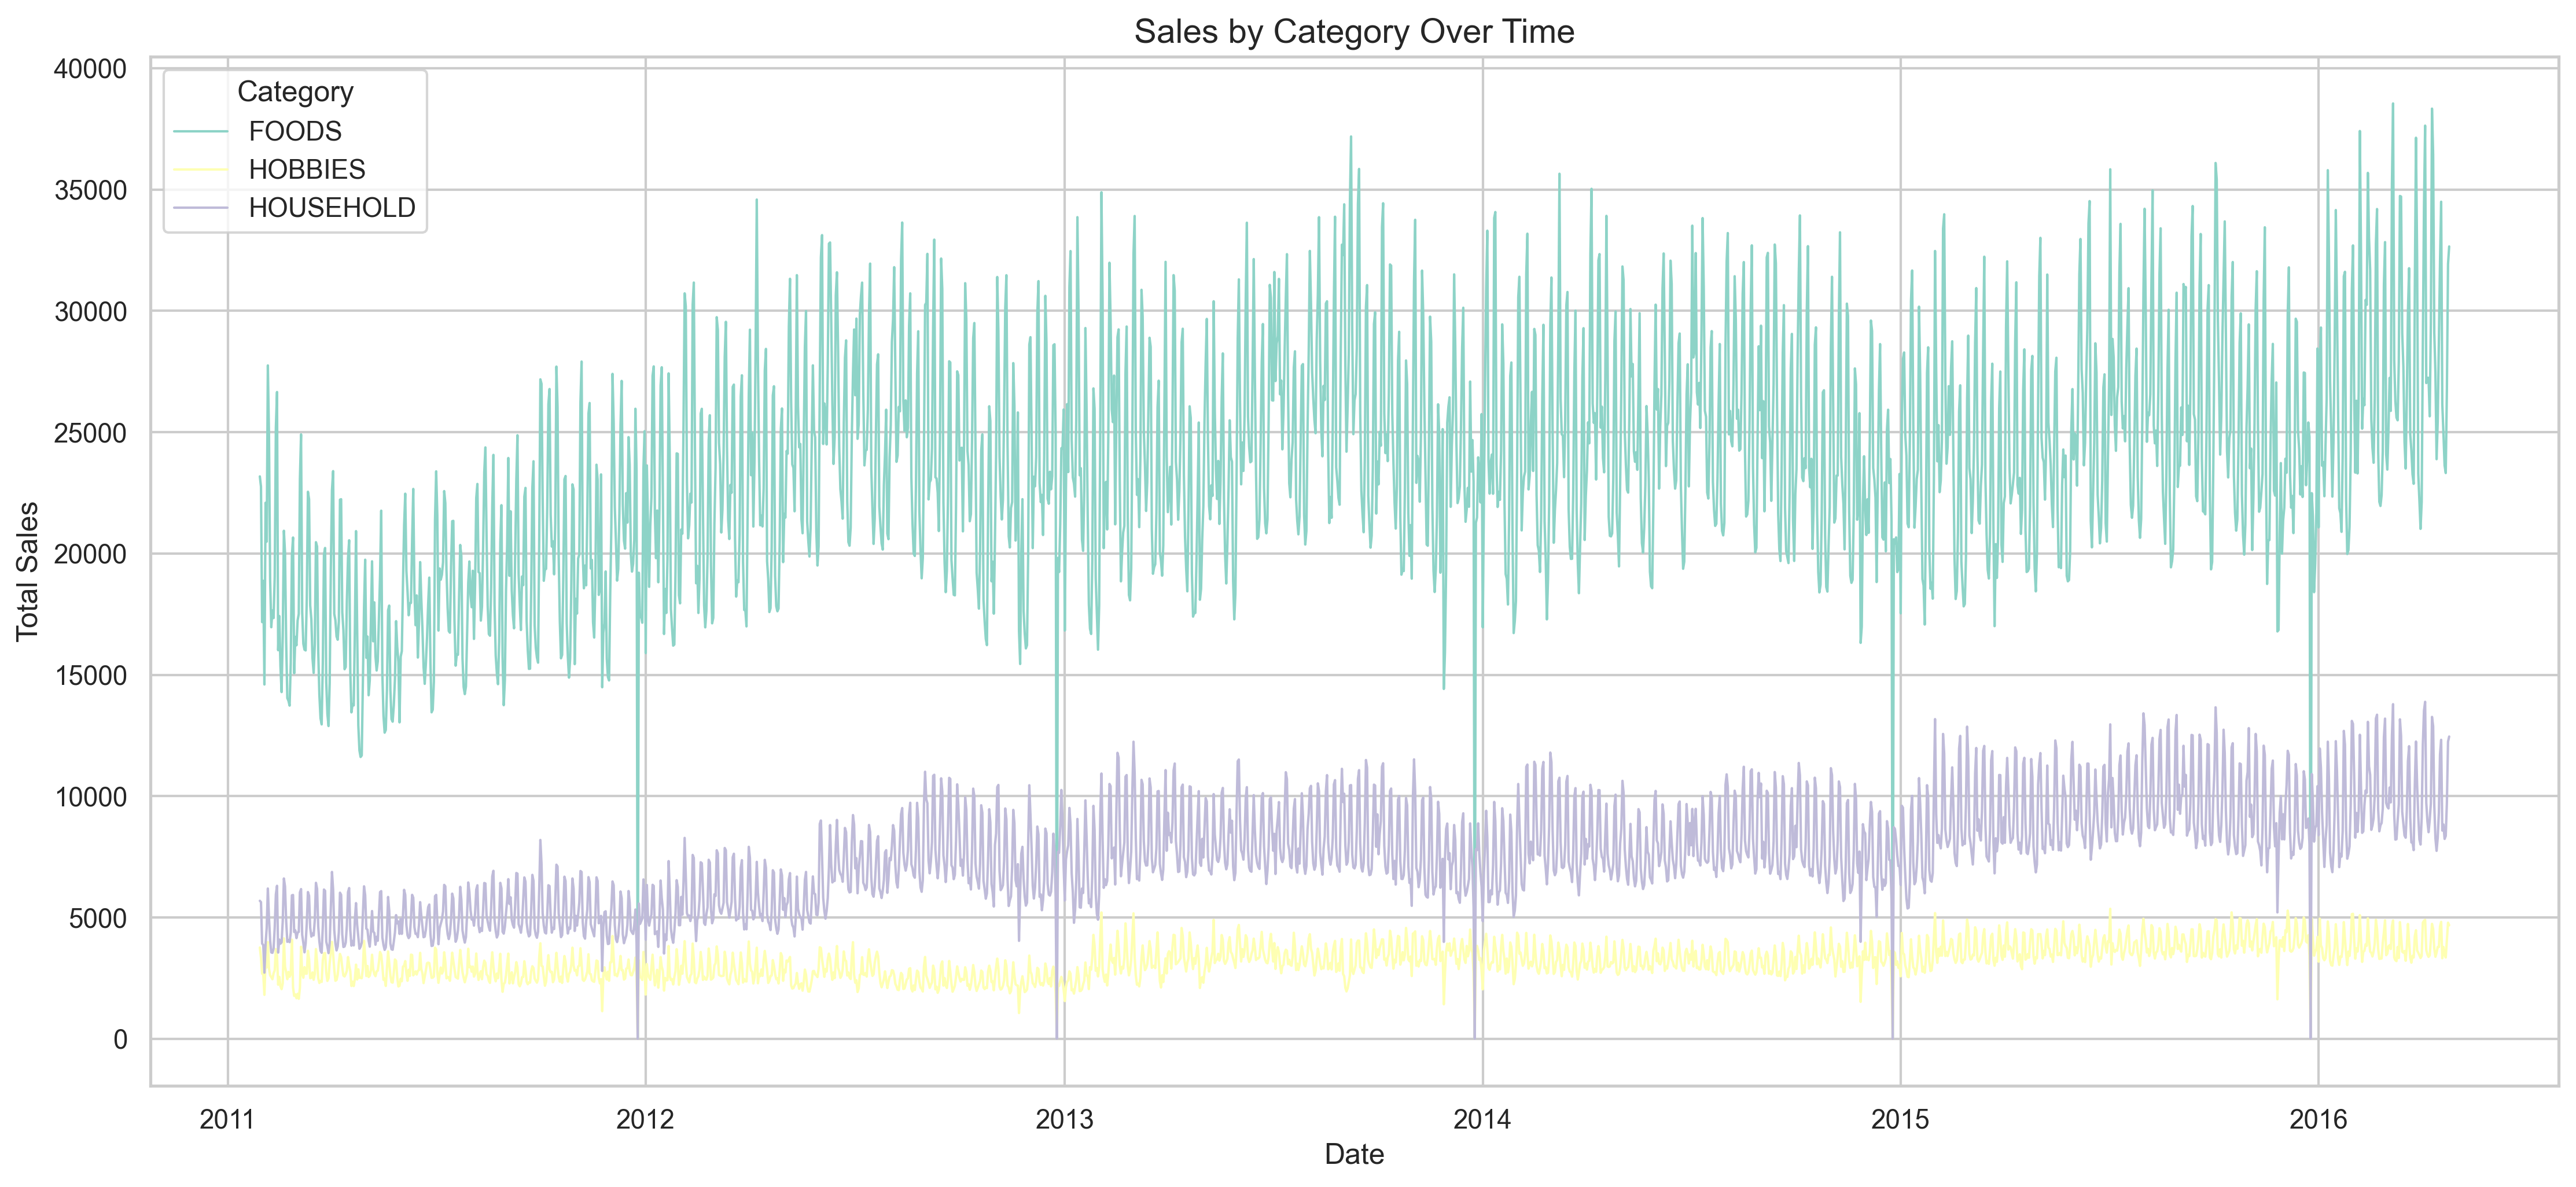

In [299]:
# =======================================================
# Step 1: Aggregate daily sales by Category
# =======================================================

# Get the list of columns that represent days (d_1, d_2, etc.)
day_columns = [col for col in sales.columns if col.startswith('d_')]

# Group the sales dataframe by category and sum the daily sales
cat_sales = sales.groupby('cat_id')[day_columns].sum()

# =======================================================
# Step 2: Transpose and prepare for merging
# =======================================================

# Transpose so that days (d_1, d_2) become rows, and categories become columns
cat_sales_t = cat_sales.T
cat_sales_t = cat_sales_t.reset_index()
cat_sales_t = cat_sales_t.rename(columns={'index': 'd'})

# =======================================================
# Step 3: Merge with Calendar to get actual dates
# =======================================================

# Extract just the 'd' and 'date' columns from the calendar dataframe
cal_dates = calendar[['d', 'date']].copy()
cal_dates['date'] = pd.to_datetime(cal_dates['date'])

# Merge the category sales with the actual dates
plot_data = pd.merge(cat_sales_t, cal_dates, on='d', how='inner')

# =======================================================
# Step 4: Melt data into "long" format for Seaborn
# =======================================================

plot_data_long = pd.melt(
    plot_data,
    id_vars=['d', 'date'],
    value_vars=['FOODS', 'HOBBIES', 'HOUSEHOLD'],
    var_name='Category',
    value_name='Total Sales'
)

# =======================================================
# Step 5: Plotting the chart
# =======================================================

# Set a clean white grid style matching the image
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(15, 7))

# Draw the line plot
sns.lineplot(
    data=plot_data_long,
    x='date',
    y='Total Sales',
    hue='Category',
    linewidth=1, # Thin lines to match the dense daily data look
    ax=ax
)

# Set titles and labels
ax.set_title('Sales by Category Over Time', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Sales', fontsize=12)

# Place the legend in the upper left corner
ax.legend(title='Category', loc='upper left')

plt.tight_layout()
plt.show()

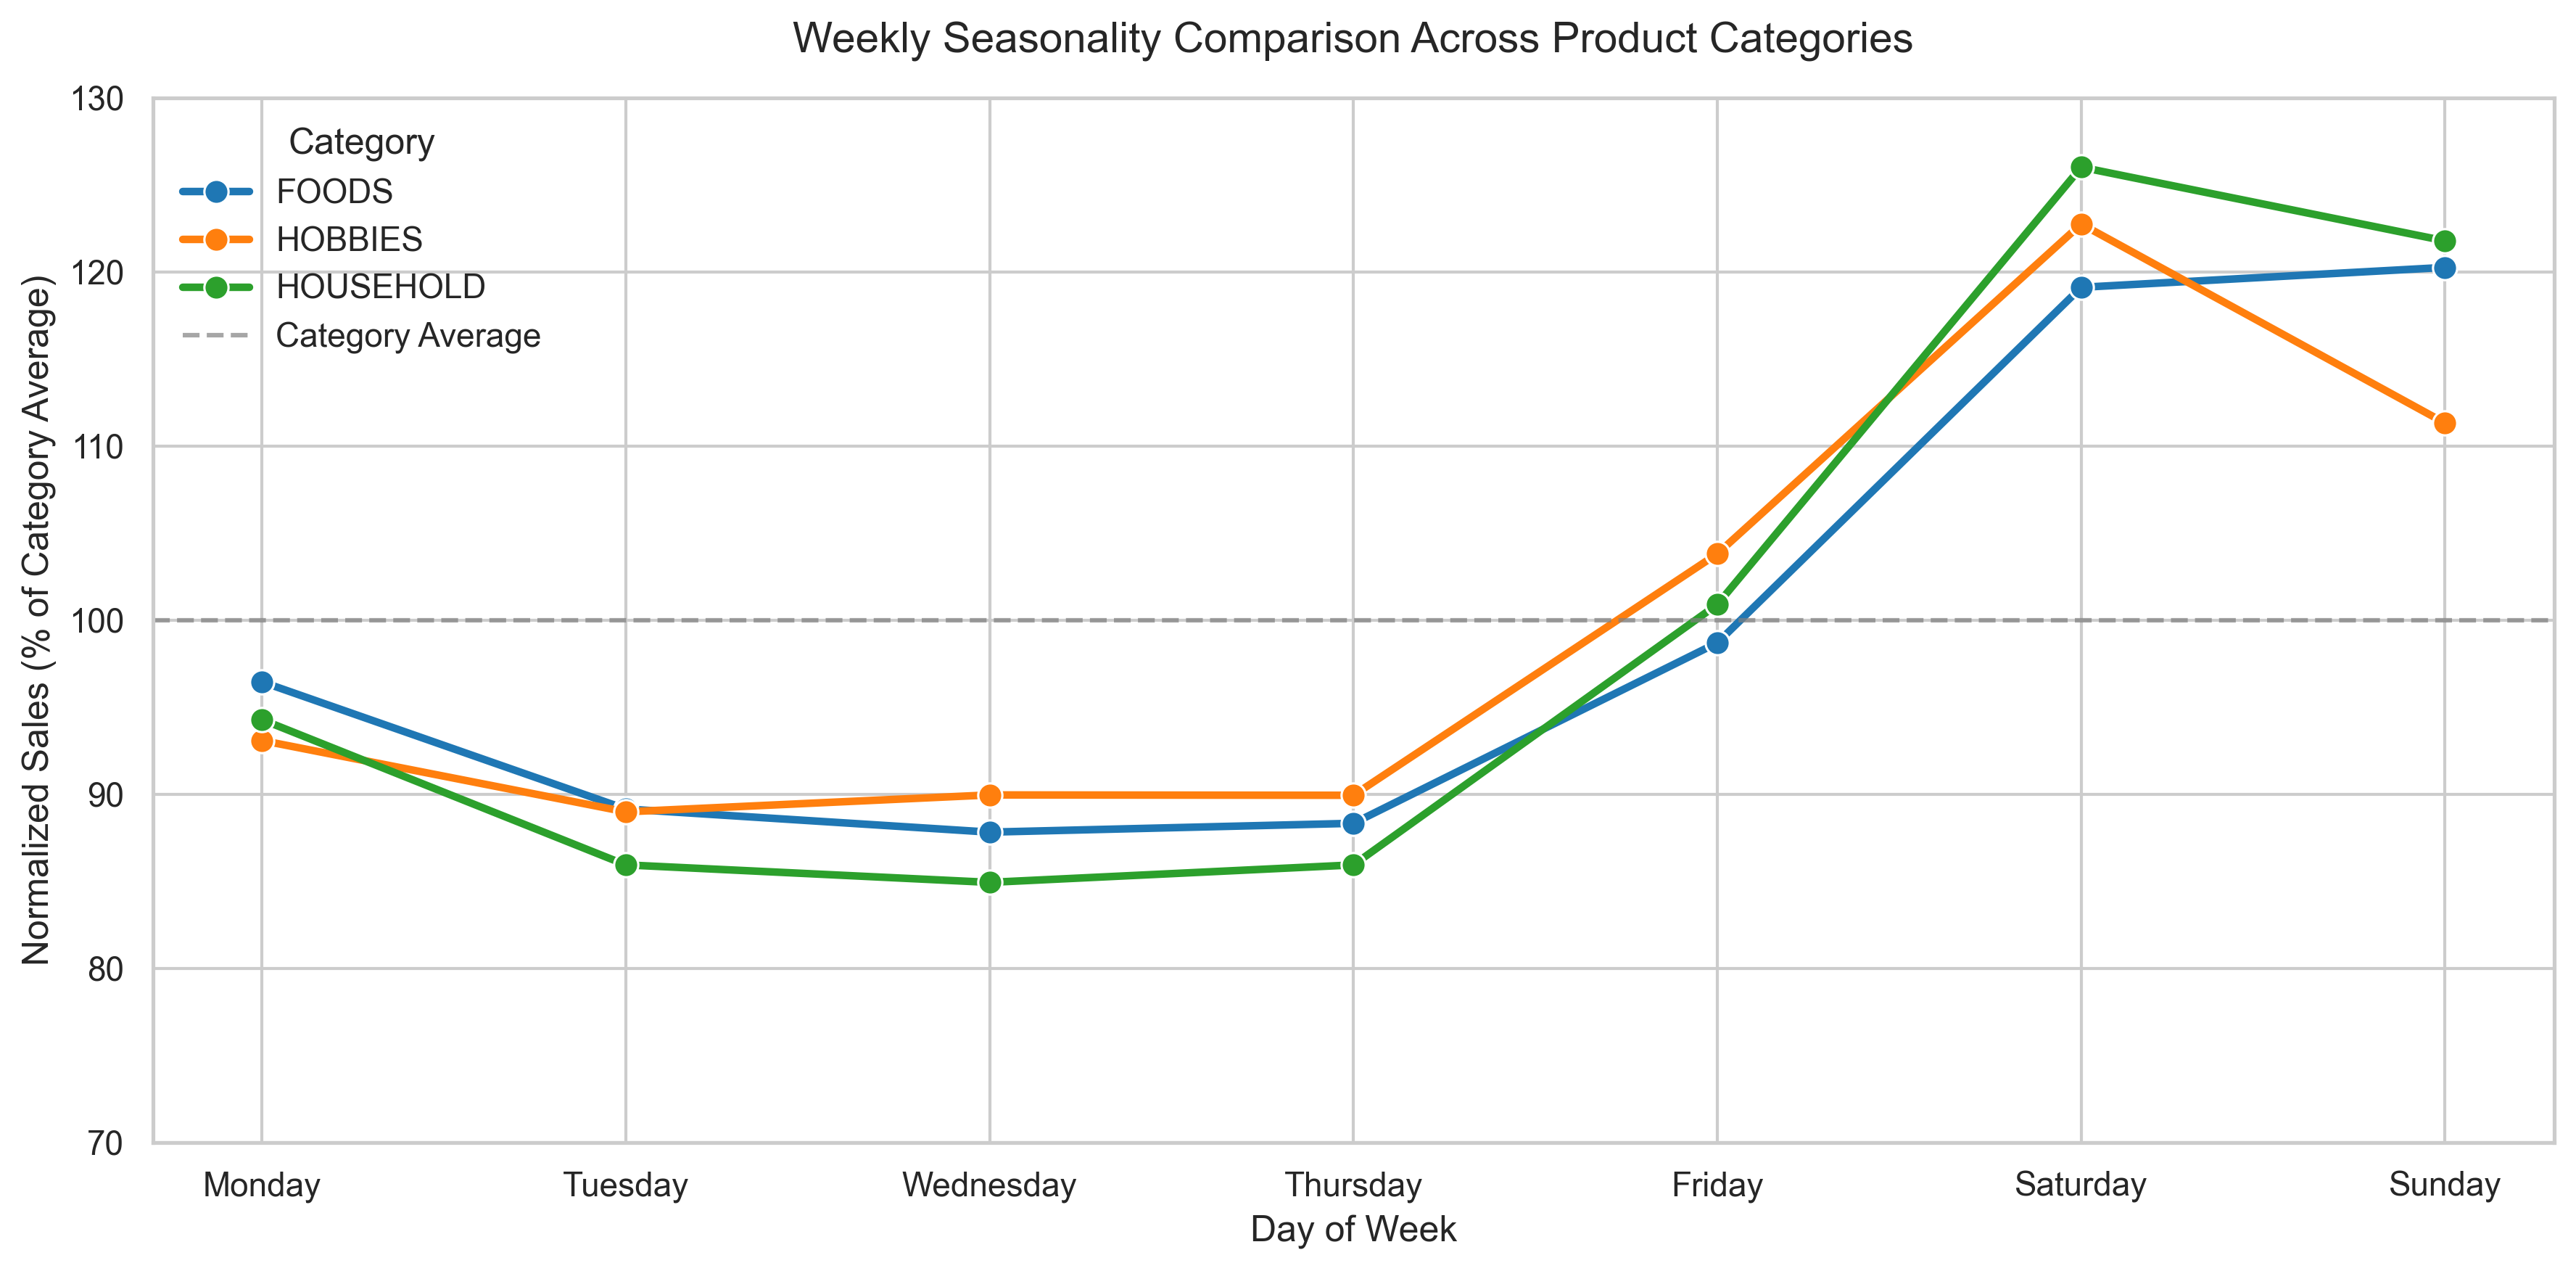

In [301]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử bạn đã chạy các lệnh nạp dữ liệu này:
# calendar = pd.read_csv('data/calendar.csv')
# sales = pd.read_csv('data/sales_train_validation.csv')

# --- 1. Chuẩn bị Dữ liệu ---

# 1a. Chuyển đổi dữ liệu sales từ dạng "wide" sang dạng "long"
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
sales_long = pd.melt(sales, id_vars=id_vars, var_name='d', value_name='sales')

# 1b. Gộp với dữ liệu calendar để lấy thông tin thứ trong tuần (weekday)
# Chỉ lấy các cột cần thiết từ calendar để tiết kiệm bộ nhớ
calendar_subset = calendar[['d', 'weekday', 'wday']]
sales_merged = pd.merge(sales_long, calendar_subset, on='d', how='left')

# --- 2. Tính toán Tính thời vụ theo tuần (Weekly Seasonality) ---

# 2a. Tính tổng doanh số theo từng Danh mục (Category) cho mỗi Ngày (d)
daily_cat_sales = sales_merged.groupby(['cat_id', 'd', 'weekday', 'wday'])['sales'].sum().reset_index()

# 2b. Tính trung bình doanh số hàng ngày cho mỗi Danh mục
# Đây sẽ là đường cơ sở (100%) để chuẩn hóa
cat_avg_sales = daily_cat_sales.groupby('cat_id')['sales'].mean().reset_index()
cat_avg_sales.rename(columns={'sales': 'avg_daily_sales'}, inplace=True)

# 2c. Gộp doanh số trung bình trở lại để chuẩn hóa
daily_cat_sales = pd.merge(daily_cat_sales, cat_avg_sales, on='cat_id')

# 2d. Chuẩn hóa doanh số: Tính tỷ lệ phần trăm so với mức trung bình của danh mục
daily_cat_sales['normalized_sales'] = (daily_cat_sales['sales'] / daily_cat_sales['avg_daily_sales']) * 100

# 2e. Tính toán tính thời vụ trung bình theo từng Thứ trong tuần cho mỗi Danh mục
weekly_seasonality = daily_cat_sales.groupby(['cat_id', 'weekday', 'wday'])['normalized_sales'].mean().reset_index()

# Sắp xếp theo thứ tự ngày trong tuần (wday: 1=Saturday, 2=Sunday, ..., 7=Friday theo chuẩn của M5 dataset)
# CẦN CHÚ Ý: M5 calendar set Saturday là wday=1.
# Để hiển thị từ Monday đến Sunday giống hình của bạn, chúng ta cần map lại thứ tự.
day_order_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
weekly_seasonality['sort_order'] = weekly_seasonality['weekday'].map(day_order_map)
weekly_seasonality = weekly_seasonality.sort_values(by=['cat_id', 'sort_order'])


# --- 3. Vẽ Biểu đồ ---

# Thiết lập style với nền trắng và lưới mờ (giống hình mẫu)
sns.set_theme(style="whitegrid")

# Khởi tạo figure và trục
fig, ax = plt.subplots(figsize=(12, 6))

# Định nghĩa bảng màu (dựa trên các màu trong hình)
custom_palette = {
    "FOODS": "#1f77b4",     # Xanh dương
    "HOBBIES": "#ff7f0e",   # Cam
    "HOUSEHOLD": "#2ca02c"  # Xanh lá
}

# Vẽ biểu đồ đường có đánh dấu điểm (markers)
sns.lineplot(
    data=weekly_seasonality,
    x='weekday',
    y='normalized_sales',
    hue='cat_id',
    marker='o',           # Thêm dấu chấm tròn
    markersize=8,
    linewidth=2.5,        # Đường nét đậm hơn
    palette=custom_palette,
    ax=ax
)

# Thêm đường tham chiếu đứt nét ở mức 100%
ax.axhline(100, color='gray', linestyle='--', alpha=0.7, label='Category Average')

# Thiết lập tiêu đề và nhãn trục
plt.title("Weekly Seasonality Comparison Across Product Categories", fontsize=14, pad=15)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Normalized Sales (% of Category Average)", fontsize=12)

# Giới hạn trục Y (dựa trên hình mẫu)
plt.ylim(70, 130)

# Tùy chỉnh Legend
# Lấy các handles và labels hiện tại
handles, labels = ax.get_legend_handles_labels()
# Xóa tiêu đề tự động của hue ('cat_id') và tạo legend mới
plt.legend(handles=handles, labels=labels, title='Category', loc='upper left', frameon=False)

# Điều chỉnh layout để không bị cắt chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

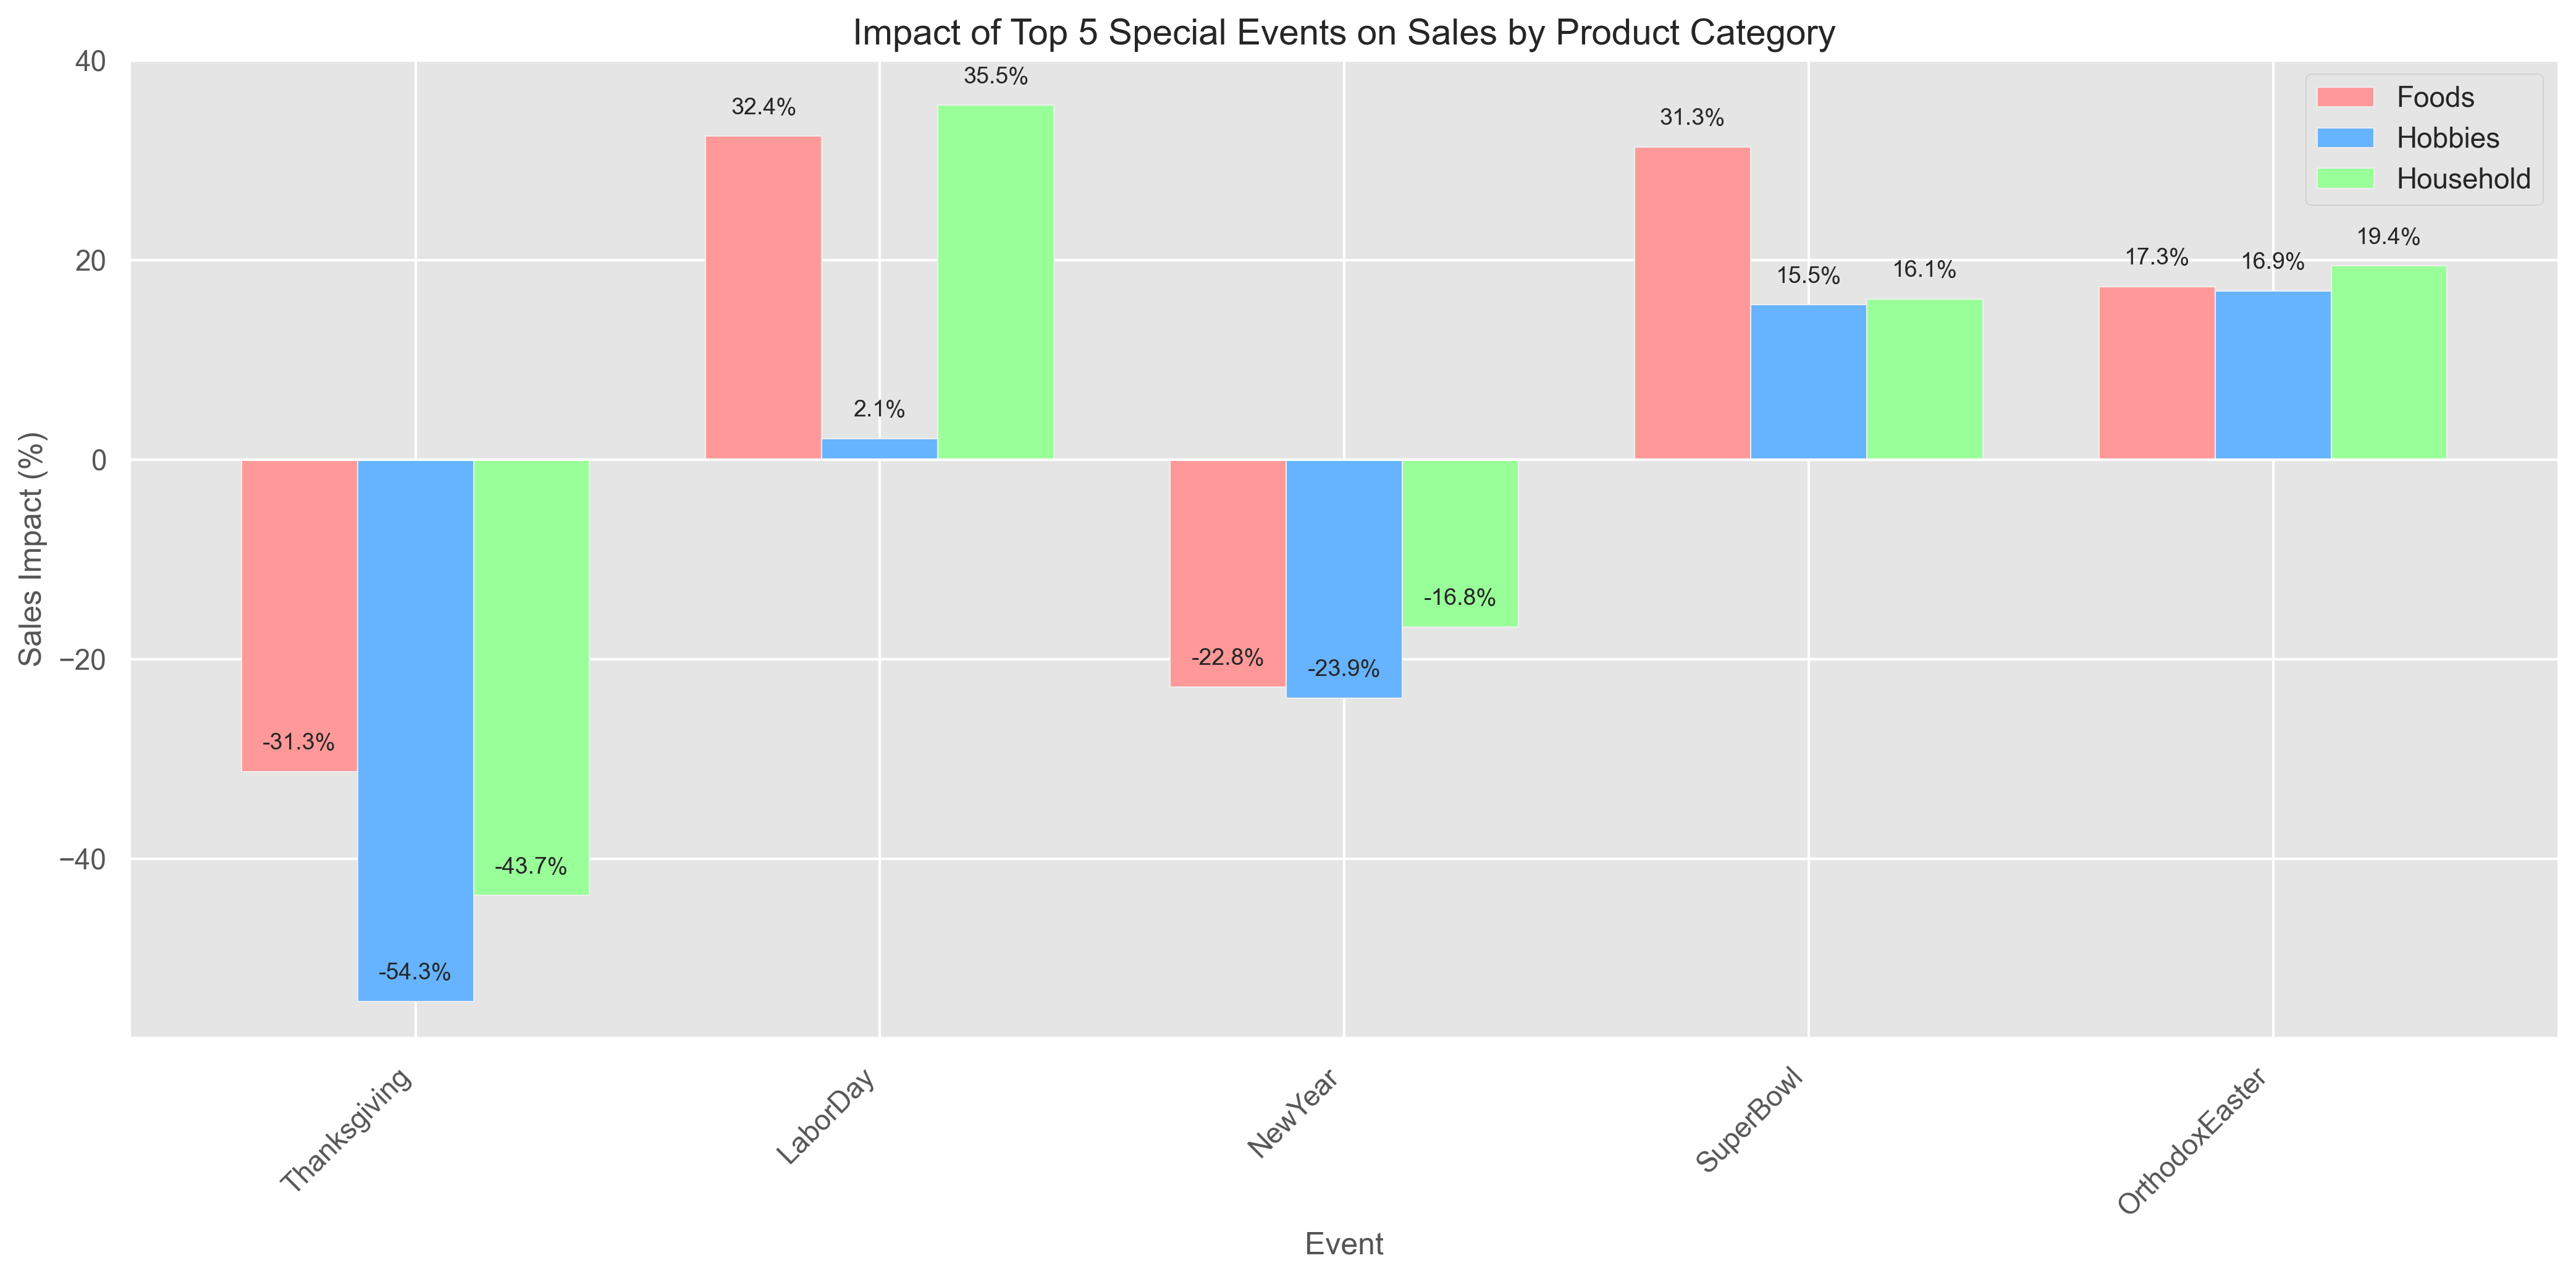

In [302]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data
# Extracting the data points from the image provided.
data = {
    'Event': ['Thanksgiving', 'LaborDay', 'NewYear', 'SuperBowl', 'OrthodoxEaster'],
    'Foods': [-31.3, 32.4, -22.8, 31.3, 17.3],
    'Hobbies': [-54.3, 2.1, -23.9, 15.5, 16.9],
    'Household': [-43.7, 35.5, -16.8, 16.1, 19.4]
}

df = pd.DataFrame(data)

# 2. Set up the plot aesthetics
plt.style.use('ggplot') # Using ggplot style for the grey background and grid
fig, ax = plt.subplots(figsize=(14, 7))

# 3. Define plotting parameters
events = df['Event']
x = np.arange(len(events))  # the label locations
width = 0.25  # the width of the bars

# Define colors matching the image
color_foods = '#ff9999'   # Light red/salmon
color_hobbies = '#66b3ff' # Light blue
color_household = '#99ff99' # Light green

# 4. Create the bars
rects1 = ax.bar(x - width, df['Foods'], width, label='Foods', color=color_foods)
rects2 = ax.bar(x, df['Hobbies'], width, label='Hobbies', color=color_hobbies)
rects3 = ax.bar(x + width, df['Household'], width, label='Household', color=color_household)

# 5. Add labels, title, and formatting
ax.set_ylabel('Sales Impact (%)', fontsize=12)
ax.set_xlabel('Event', fontsize=12)
ax.set_title('Impact of Top 5 Special Events on Sales by Product Category', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(events, rotation=45, ha='right')
ax.legend()

# Set y-axis limits to match the original plot
ax.set_ylim(-58, 40)

# Add a horizontal line at y=0
ax.axhline(0, color='white', linewidth=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('white')

# 6. Function to attach a text label above/below each bar
def autolabel(rects):
    """Attach a text label above/below each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        # Determine label position based on positive or negative value
        if height >= 0:
            y_pos = height + 1
            va = 'bottom'
        else:
            y_pos = height + 1
            va = 'bottom'

        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, y_pos),
                    xytext=(0, 3) if height >= 0 else (0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va=va, fontsize=9)

# 7. Apply the labels
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# 8. Adjust layout and display
plt.tight_layout()
plt.show()

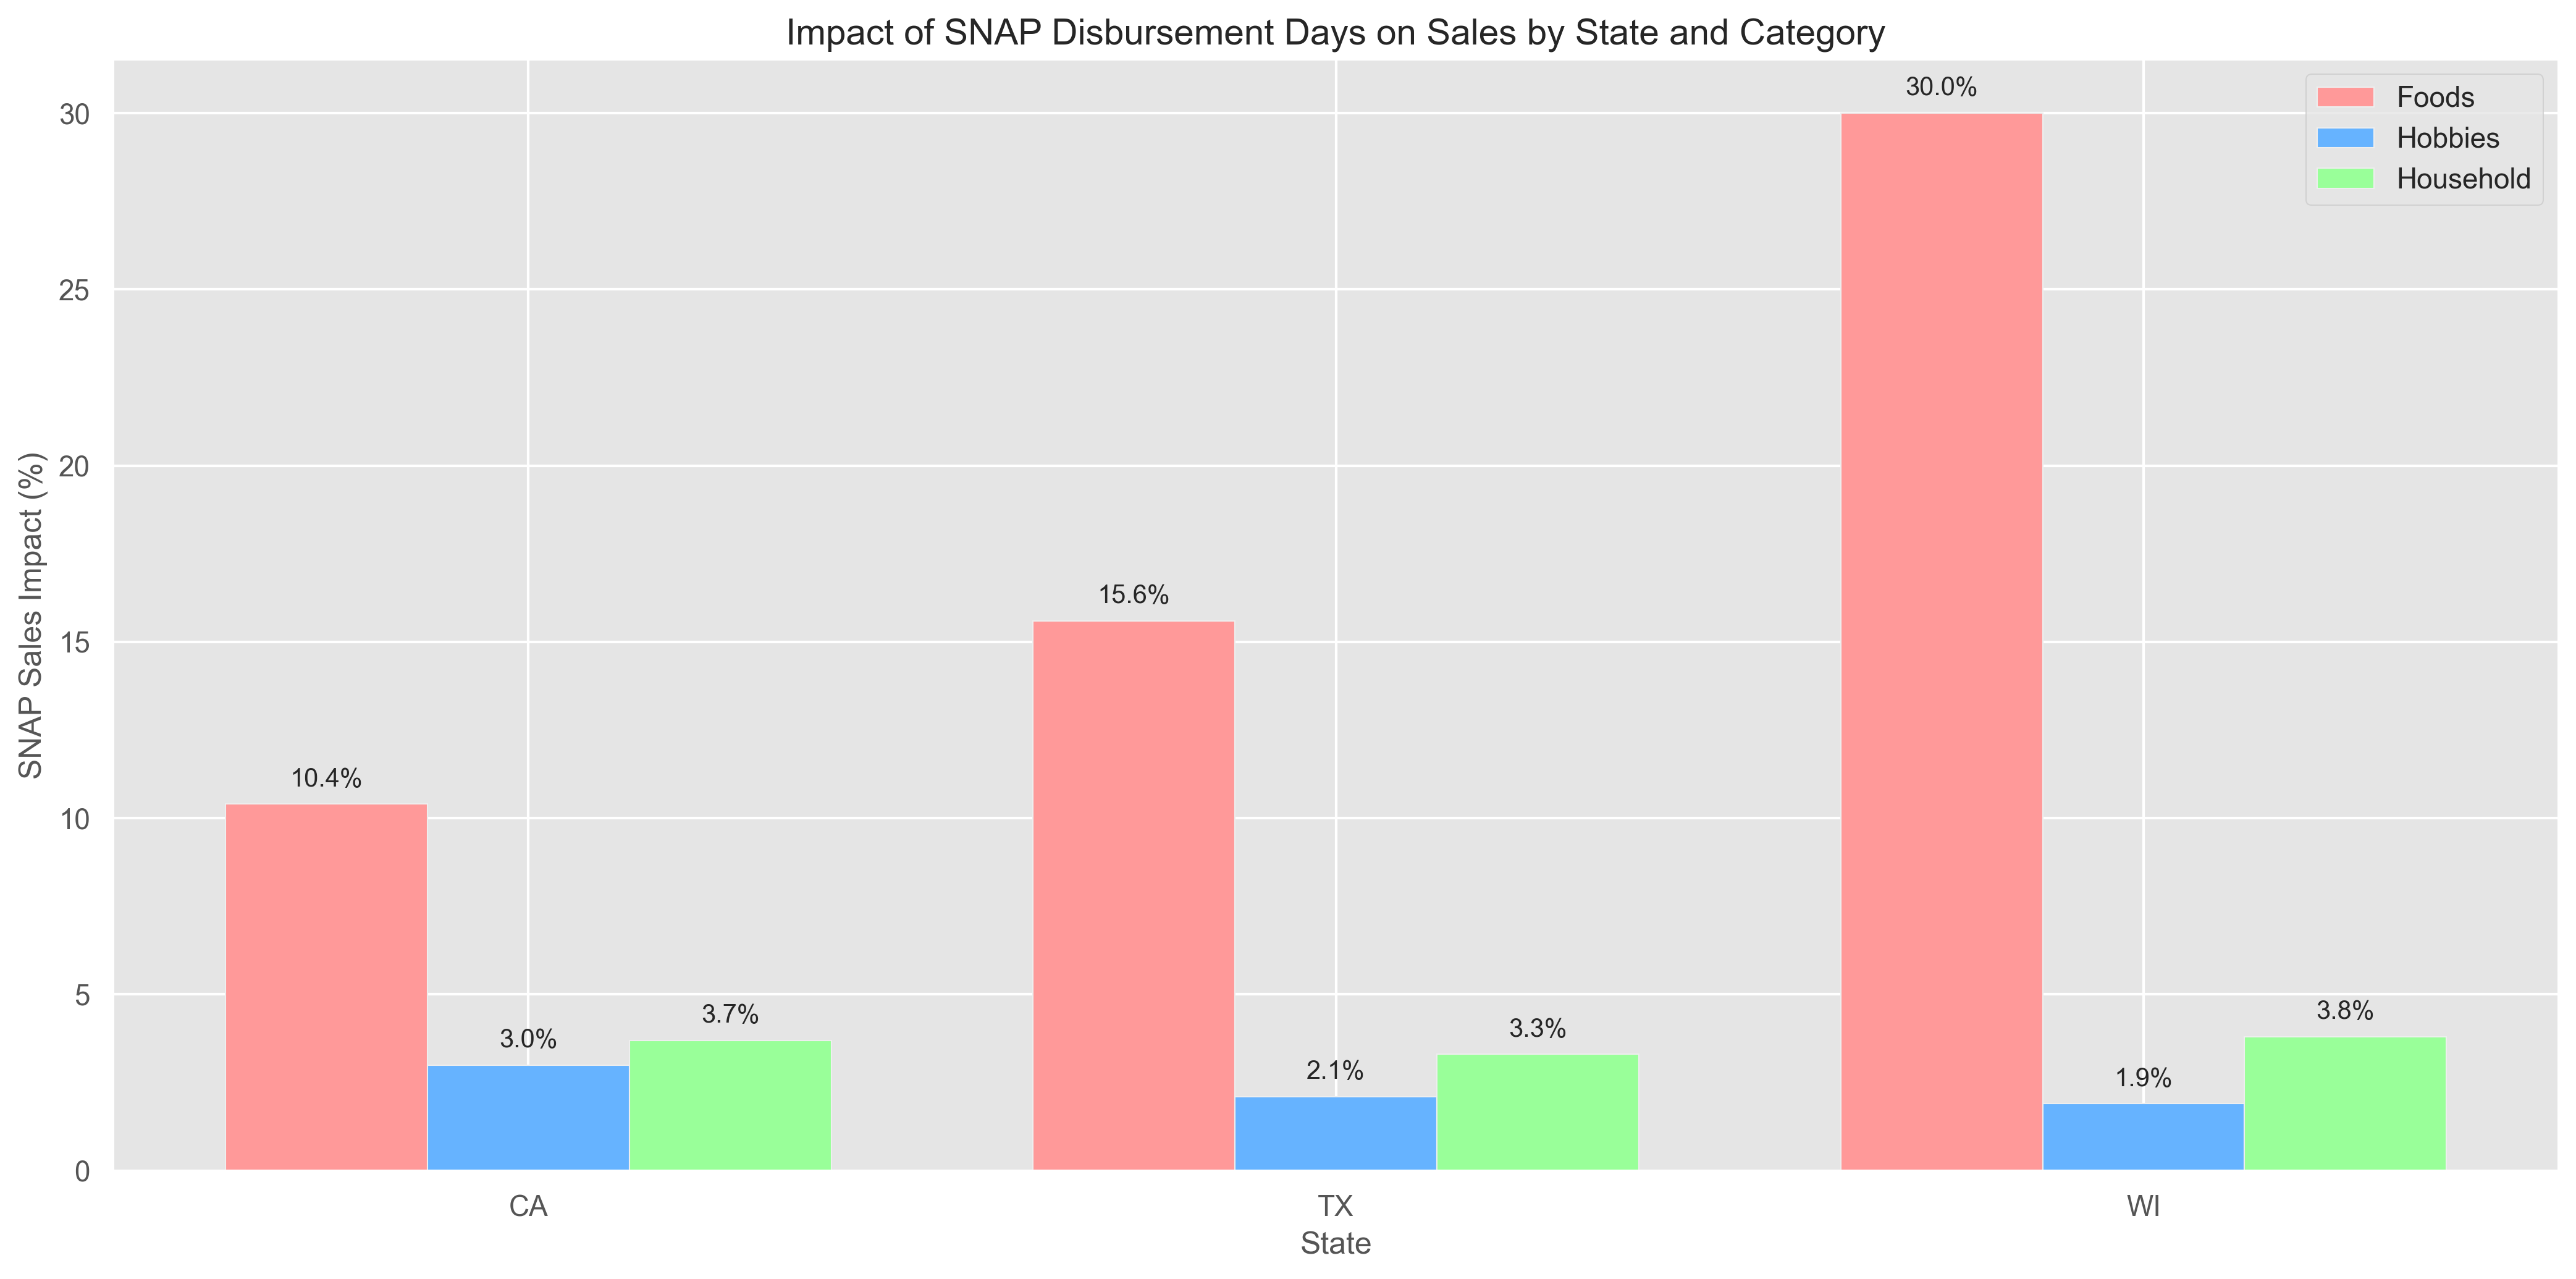

In [303]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu
states = ['CA', 'TX', 'WI']
foods_impact = [10.4, 15.6, 30.0]
hobbies_impact = [3.0, 2.1, 1.9]
household_impact = [3.7, 3.3, 3.8]

# 2. Cài đặt style giống hình (nền xám, lưới trắng)
plt.style.use('ggplot')

# Thiết lập kích thước khung hình (figsize)
fig, ax = plt.subplots(figsize=(14, 7))

# Thiết lập vị trí trục x và độ rộng của cột
x = np.arange(len(states))
width = 0.25

# 3. Định nghĩa màu sắc (khớp với hình mẫu)
color_foods = '#ff9999'      # Đỏ nhạt / Hồng
color_hobbies = '#66b3ff'    # Xanh dương nhạt
color_household = '#99ff99'  # Xanh lá nhạt

# 4. Vẽ các cột
rects1 = ax.bar(x - width, foods_impact, width, label='Foods', color=color_foods)
rects2 = ax.bar(x, hobbies_impact, width, label='Hobbies', color=color_hobbies)
rects3 = ax.bar(x + width, household_impact, width, label='Household', color=color_household)

# 5. Thêm nhãn, tiêu đề và định dạng trục
ax.set_ylabel('SNAP Sales Impact (%)', fontsize=12)
ax.set_xlabel('State', fontsize=12)
ax.set_title('Impact of SNAP Disbursement Days on Sales by State and Category', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend()

# Loại bỏ viền trên và viền phải để đồ thị thoáng hơn
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 6. Hàm đính kèm nhãn số liệu (labels) lên đầu mỗi cột
def autolabel(rects):
    """Gắn nhãn text lên trên mỗi cột"""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Dịch lên 5 points theo chiều dọc
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Gọi hàm để gắn nhãn cho 3 nhóm cột
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# 7. Tối ưu hóa layout và hiển thị
plt.tight_layout()
plt.show()

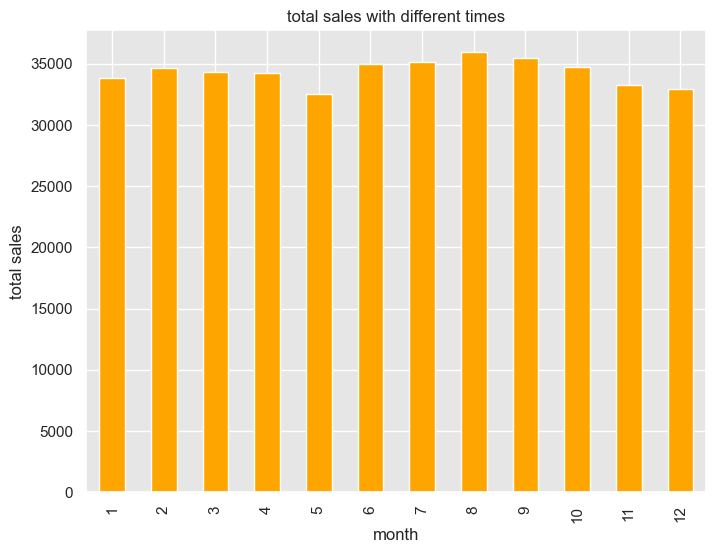

In [298]:
d.index=d['month']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
d['total sales'].plot(kind='bar',color='orange')
plt.xlabel('month')
plt.ylabel("total sales")
plt.title('total sales with different times')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

Monthly sales exhibit strong annual seasonality, with a pronounced peak in mid-summer and lower volumes toward the end of the year. This confirms that demand is systematically influenced by seasonal factors and supports the use of calendar features in forecasting models.

In [13]:
e=c.groupby(["weekday"])['total sales'].sum().reset_index()
e

,weekday,total sales
0,Friday,9343694
1,Monday,8968860
2,Saturday,11383849
3,Sunday,11269626
4,Thursday,8245967
5,Tuesday,8290677
6,Wednesday,8192736


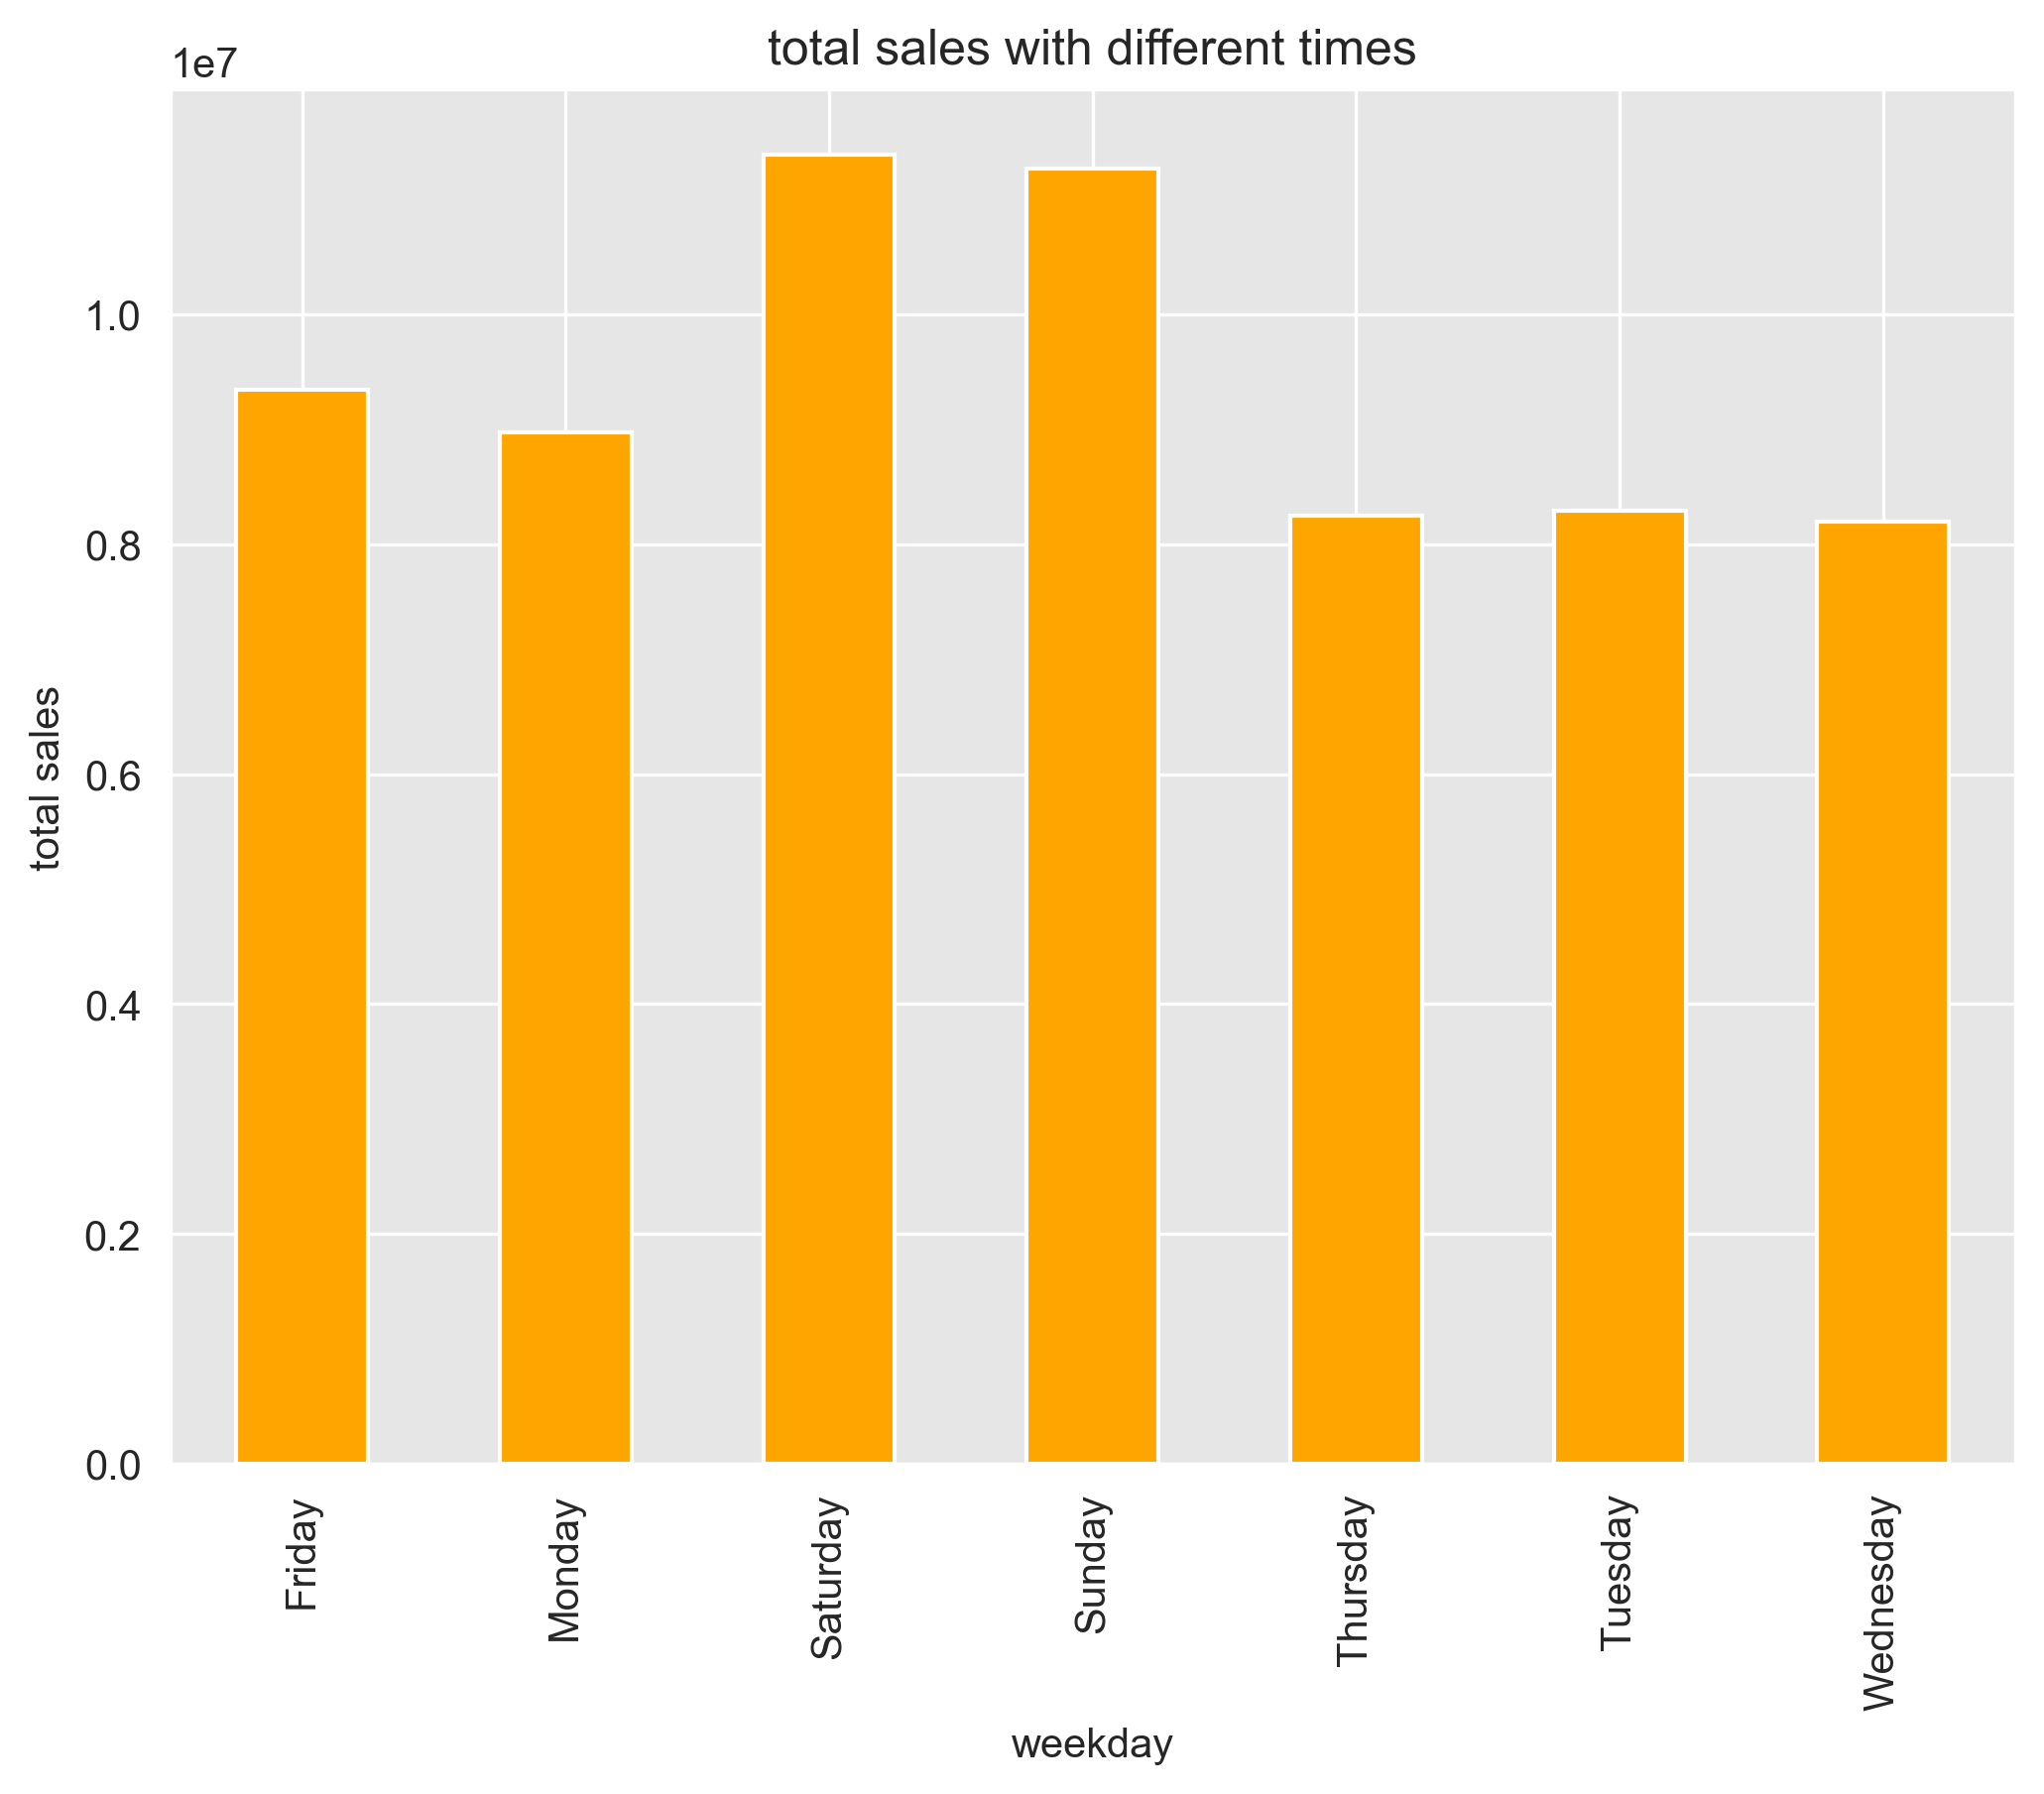

In [14]:
e.index=e['weekday']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
e['total sales'].plot(kind='bar',color='orange')
plt.xlabel('weekday')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

Sales exhibit strong weekly seasonality, with markedly higher volumes on weekends compared to weekdays. The clear weekday–weekend contrast confirms the importance of intra-week seasonal effects and supports the inclusion of weekday indicators or cyclical calendar features in subsequent forecasting models.

In [15]:
f=c.groupby(["year"])['total sales'].mean().reset_index()
f

,year,total sales
0,2011,26280.667656
1,2012,32955.838798
2,2013,35988.364384
3,2014,35862.400000
4,2015,37810.441096
5,2016,41309.973913


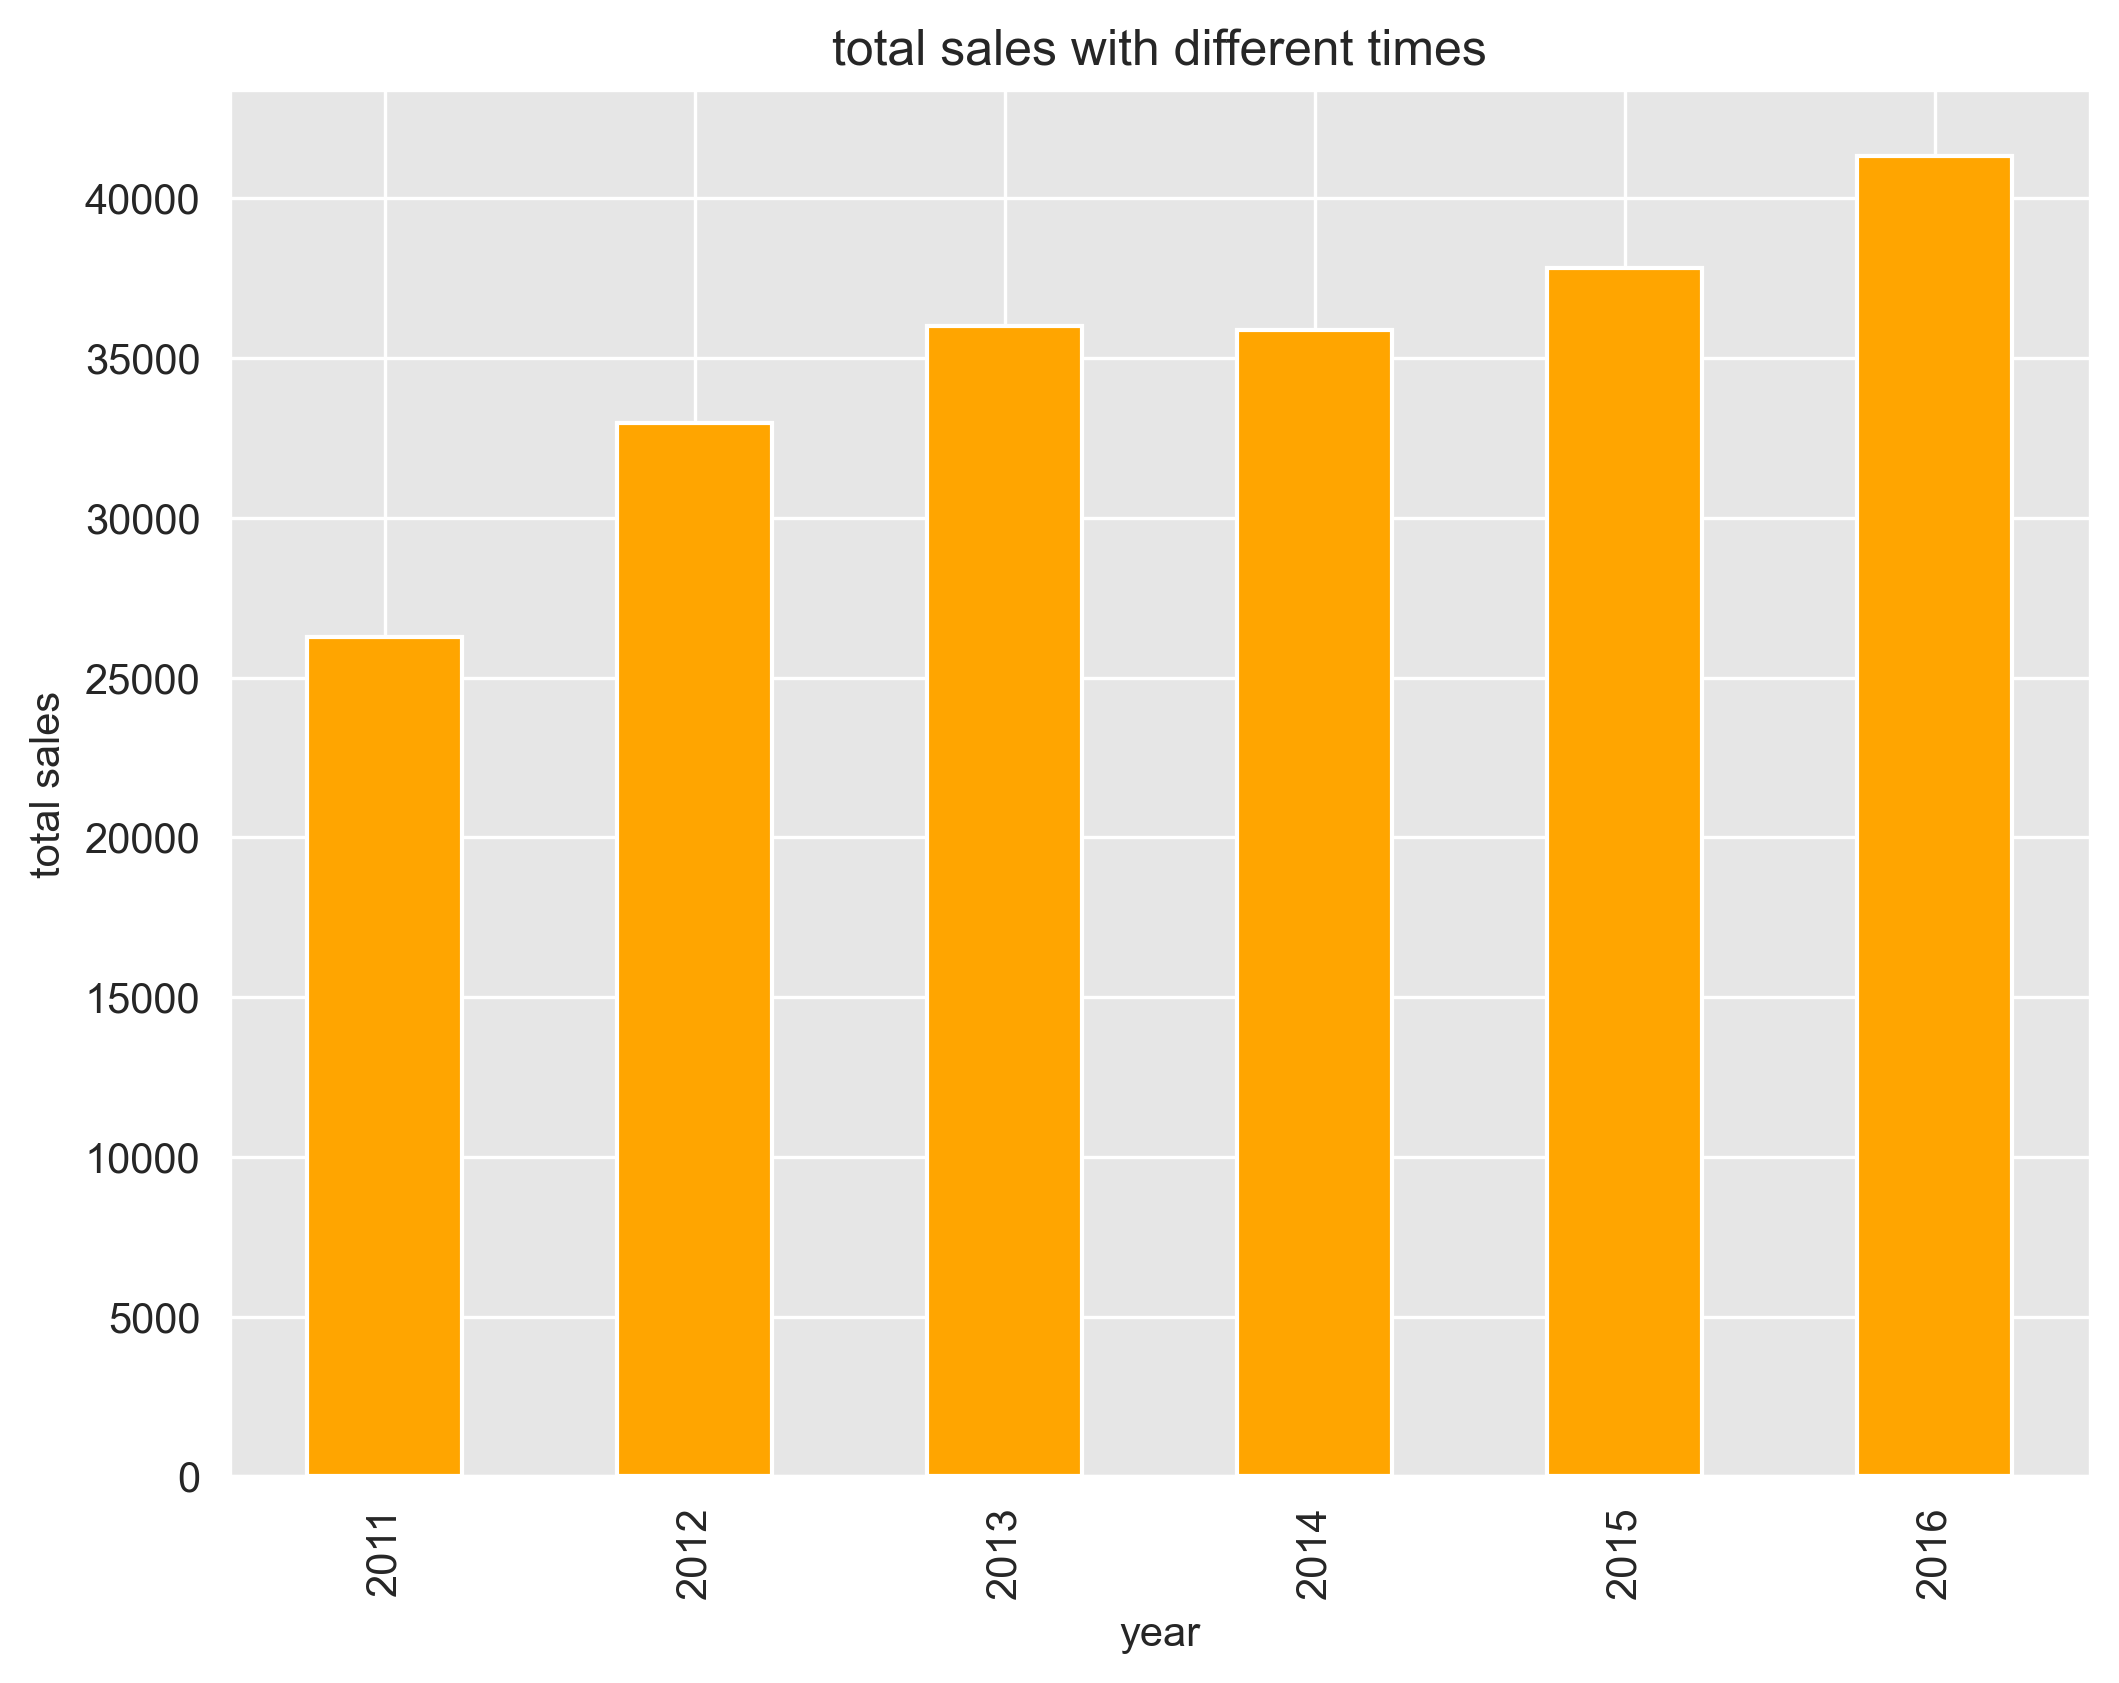

In [16]:
f.index=f['year']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
f['total sales'].plot(kind='bar',color='orange')
plt.xlabel('year')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #存檔
plt.show()

The annual aggregation of total sales demonstrates a clear upward trend over the observed period. Sales increase consistently from 2011 through 2016, indicating sustained growth in overall demand across years. This pattern suggests a positive long-term trend in the data, which may reflect factors such as portfolio expansion, increased consumer demand, or broader market growth.

In [17]:
g=c.groupby(["wm_yr_wk"])['total sales'].sum().reset_index()

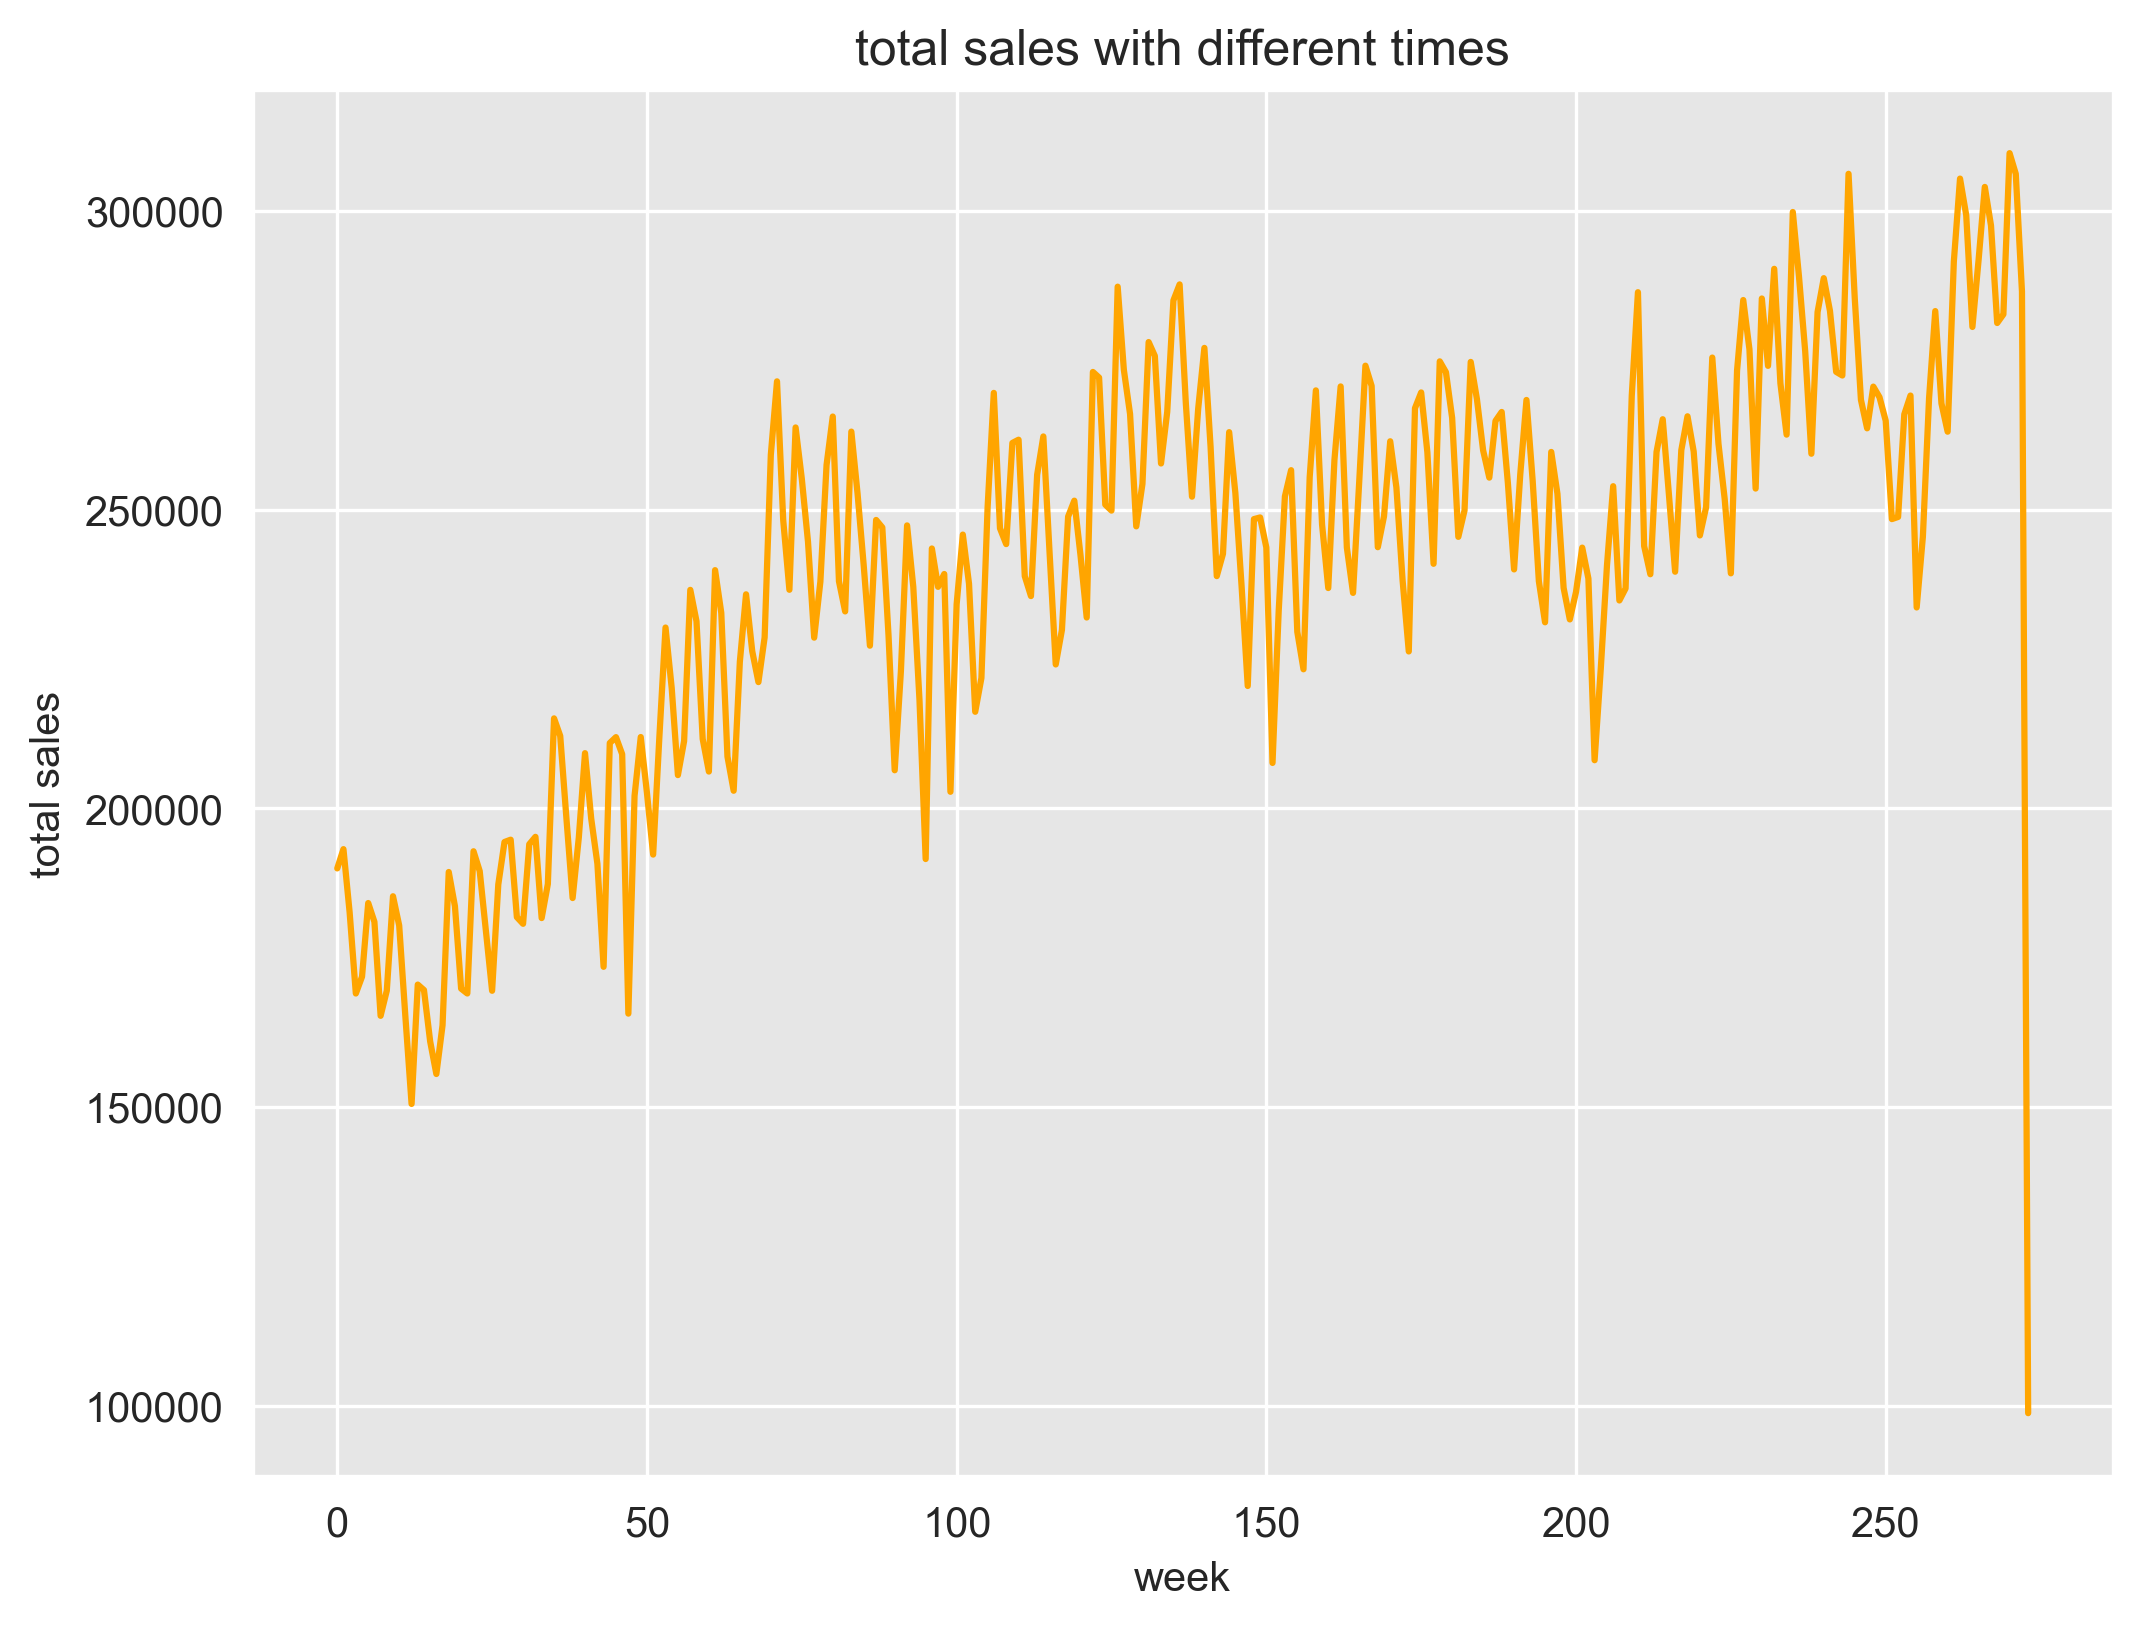

In [18]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
g['total sales'].plot(kind='line',color='orange')
plt.xlabel('week')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

Weekly total sales display a sustained upward trend combined with regular seasonal fluctuations, indicating non-stationary behavior driven by both long-term growth and recurring demand cycles.

Overall, the findings confirm that overall product sales are time-driven, with demand shaped by long-term growth, recurring seasonal patterns, and calendar-related effects. This justifies the use of time-aware forecasting approaches, such as ARIMA/SARIMAX models with trend and seasonality components, as well as machine-learning models incorporating lagged variables and calendar features.

### Visualization: Relation between sales and product category over time

In [19]:
cate=sales.groupby('cat_id').sum()
cate2=cate.T.reset_index()
cate2=cate2.drop('index',axis=1)
category=pd.concat([b,cate2],axis=1)
category['date'] =  pd.to_datetime(category['date'], format='%Y-%m-%d')

In [20]:
category

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,FOODS,HOBBIES,HOUSEHOLD
0,2011-01-29,11101.0,Saturday,1.0,1.0,2011.0,d_1,NaN,NaN,NaN,NaN,0.0,0.0,0.0,FOODS_1_001_CA_1_validationFOODS_1_002_CA_1_va...,HOBBIES_1_001_CA_1_validationHOBBIES_1_002_CA_...,HOUSEHOLD_1_001_CA_1_validationHOUSEHOLD_1_002...
1,2011-01-30,11101.0,Sunday,2.0,1.0,2011.0,d_2,NaN,NaN,NaN,NaN,0.0,0.0,0.0,FOODS_1_001FOODS_1_002FOODS_1_003FOODS_1_004FO...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOUSEHOLD_1_001HOUSEHOLD_1_002HOUSEHOLD_1_003H...
2,2011-01-31,11101.0,Monday,3.0,1.0,2011.0,d_3,NaN,NaN,NaN,NaN,0.0,0.0,0.0,FOODS_1FOODS_1FOODS_1FOODS_1FOODS_1FOODS_1FOOD...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOUSEHOLD_1HOUSEHOLD_1HOUSEHOLD_1HOUSEHOLD_1HO...
3,2011-02-01,11101.0,Tuesday,4.0,2.0,2011.0,d_4,NaN,NaN,NaN,NaN,1.0,1.0,0.0,CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA...,CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA...,CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA_1CA...
4,2011-02-02,11101.0,Wednesday,5.0,2.0,2011.0,d_5,NaN,NaN,NaN,NaN,1.0,0.0,1.0,CACACACACACACACACACACACACACACACACACACACACACACA...,CACACACACACACACACACACACACACACACACACACACACACACA...,CACACACACACACACACACACACACACACACACACACACACACACA...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23632,3472,8239
1914,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23317,3353,8363
1915,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26704,4085,9728
1916,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31927,4787,12248


In [21]:
# Ensure category sales columns are numeric
cols = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
category[cols] = category[cols].apply(pd.to_numeric, errors='coerce')

# Group by month and compute mean
d_cate = (
    category
    .groupby('month')[cols]
    .mean()
    .reset_index()
)

d_cate


,month,FOODS,HOBBIES,HOUSEHOLD
0,1.0,23607.664516,3088.600000,7282.625806
1,2.0,23693.702381,3313.869048,7656.297619
2,3.0,23289.075269,3222.860215,7754.064516
3,4.0,23383.551724,3303.304598,7581.218391
4,5.0,22343.761290,3148.651613,7022.103226
5,6.0,23816.100000,3283.580000,7435.380000
6,7.0,24396.658065,3232.451613,7655.387097
7,8.0,24562.303226,3113.496774,8027.619355
8,9.0,24364.646667,3011.486667,8074.146667
9,10.0,23944.935484,3250.645161,7912.200000


<Figure size 2400x1800 with 0 Axes>

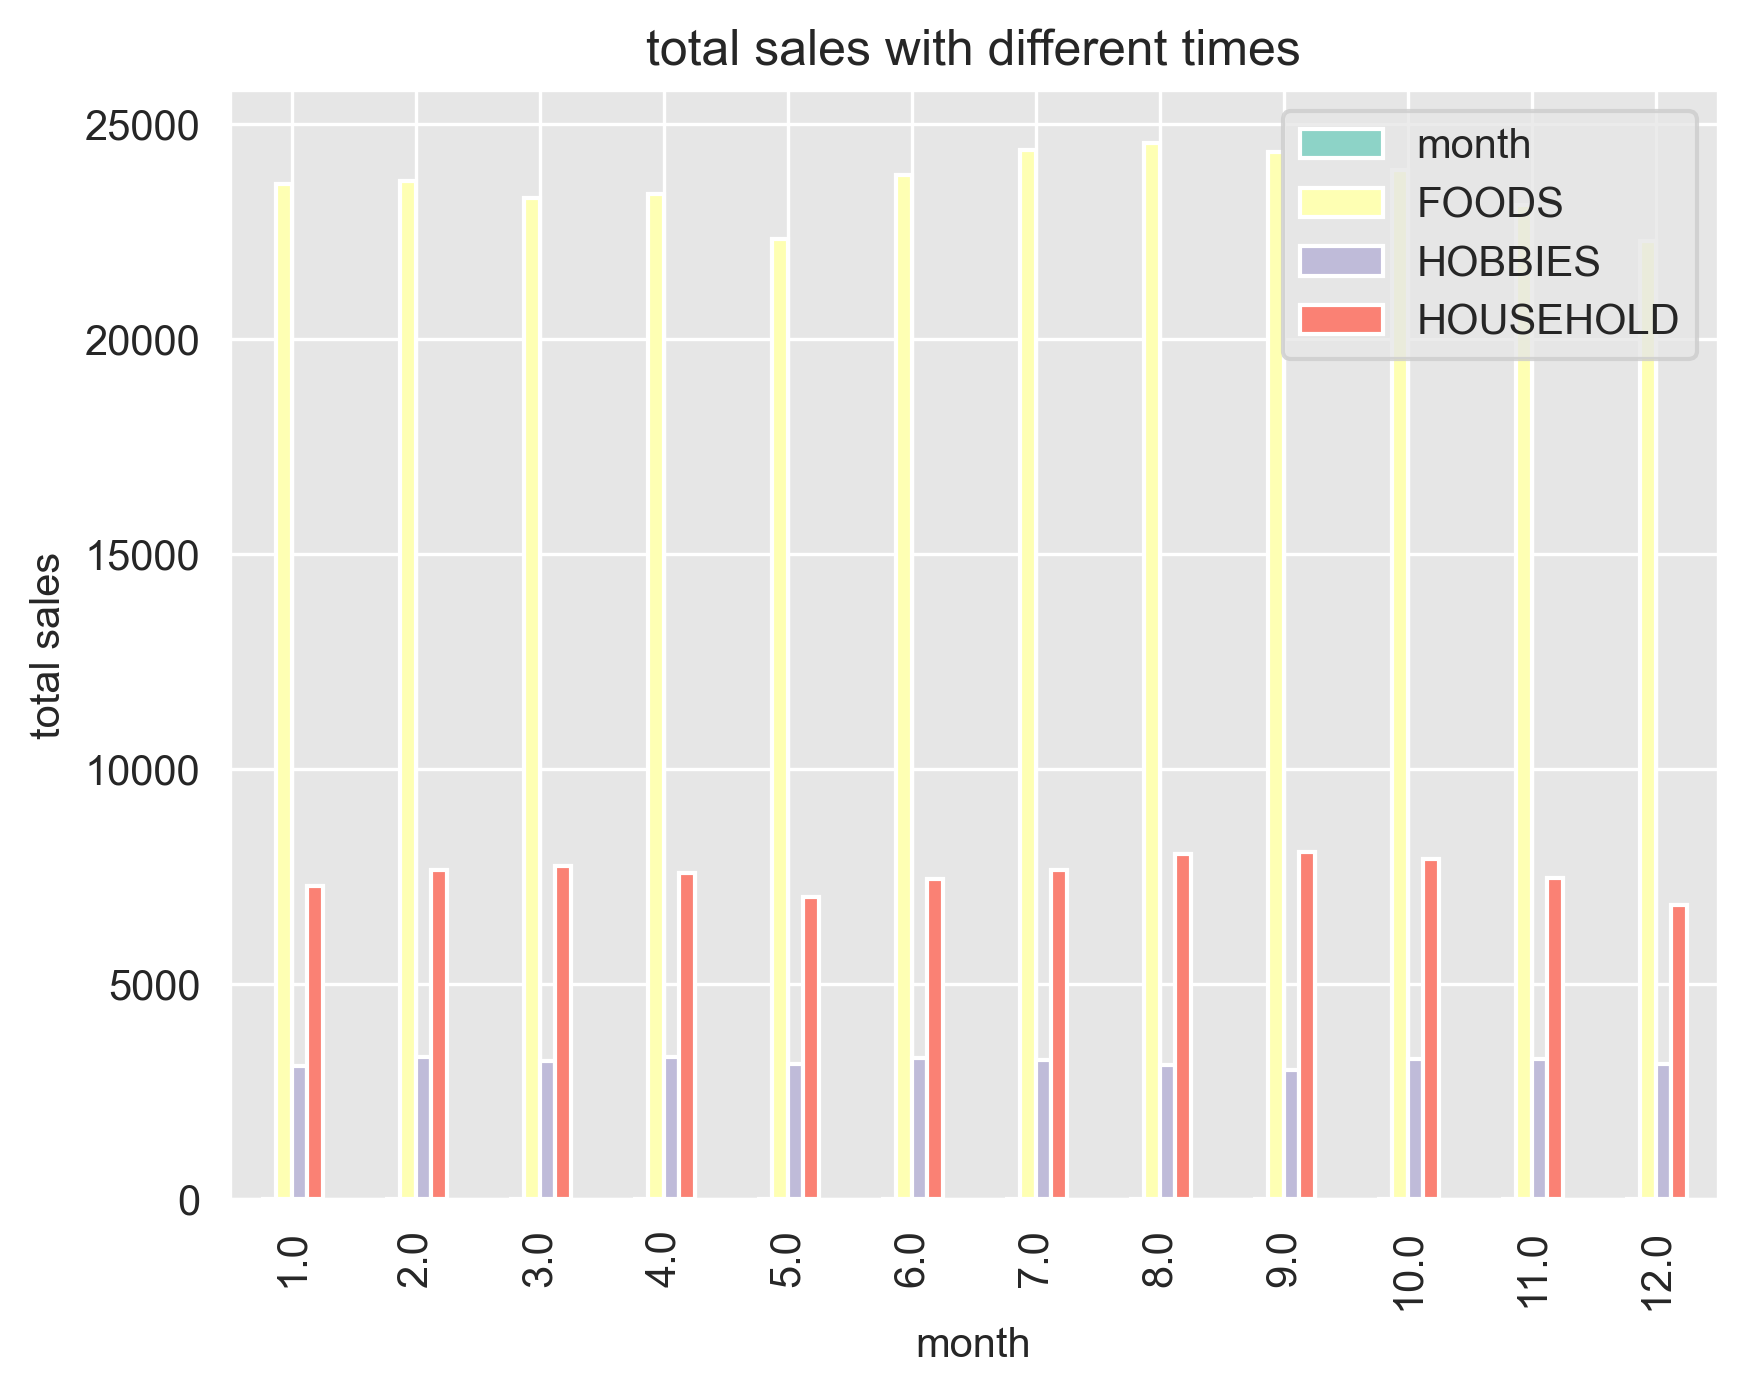

In [22]:
d_cate.index=d_cate['month']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
d_cate.plot(kind='bar')
plt.xlabel('month')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

All product categories follow similar monthly seasonal patterns to the overall sales trend, indicating that common calendar effects drive demand across categories.

In [23]:
e_cate=category.groupby(["weekday"])[['FOODS','HOBBIES','HOUSEHOLD']].sum().reset_index()
e_cate

,weekday,FOODS,HOBBIES,HOUSEHOLD
0,Friday,7734394.0,971903.0,2513534.0
1,Monday,5627543.0,782838.0,1747012.0
2,Saturday,6206765.0,813632.0,1948463.0
3,Sunday,5736838.0,777821.0,1776018.0
4,Thursday,7661226.0,1072124.0,2601537.0
5,Tuesday,5660531.0,782782.0,1767621.0
6,Wednesday,6324408.0,903320.0,2075449.0


<Figure size 2400x1800 with 0 Axes>

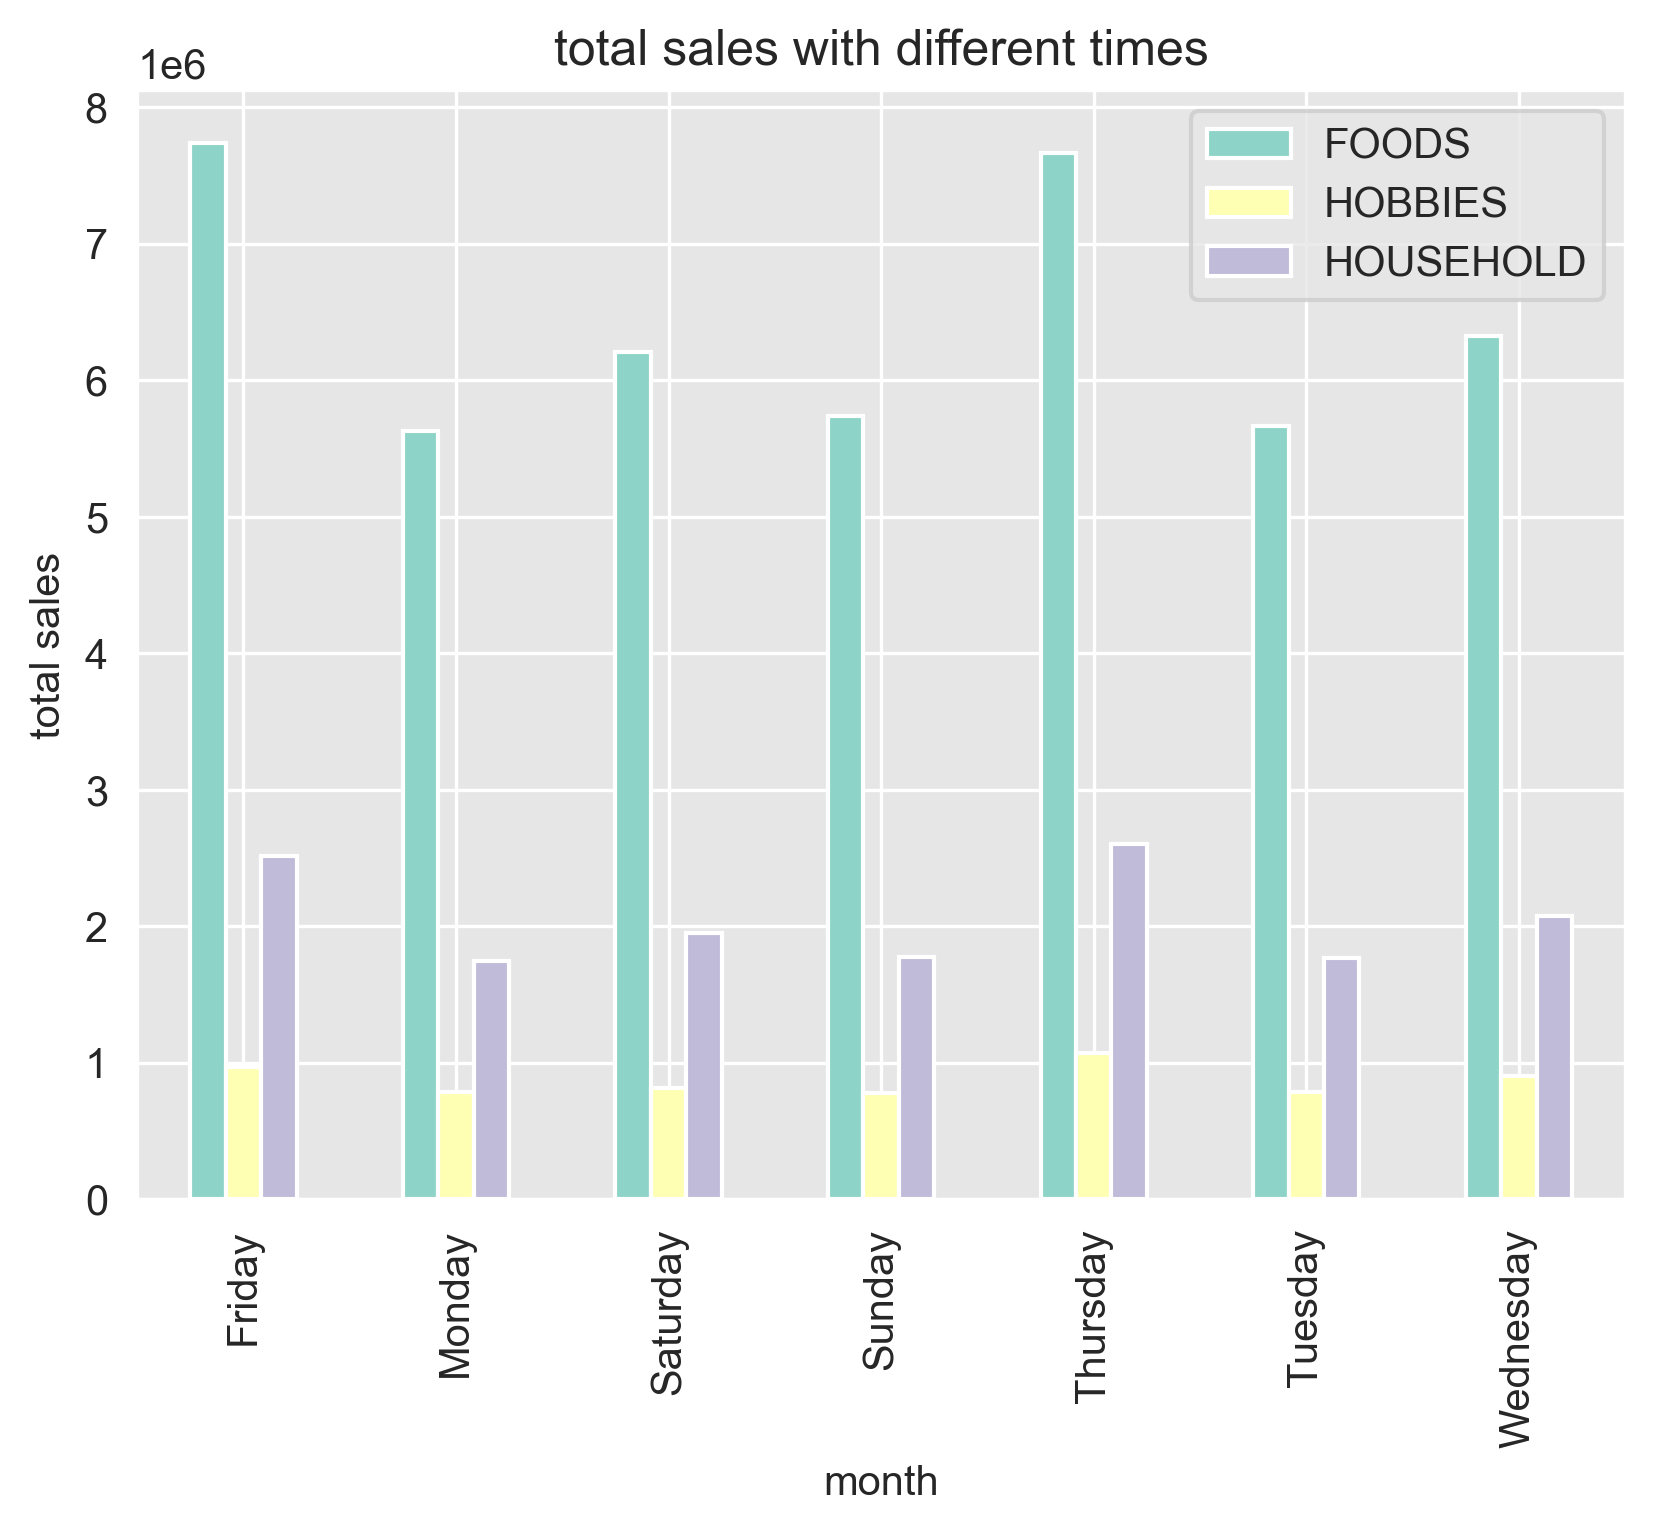

In [24]:
e_cate.index=e_cate['weekday']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
e_cate.plot(kind='bar')
plt.xlabel('month')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #存檔
plt.show()

All categories display similar weekday demand patterns to overall sales, indicating that common weekday effects influence demand across product types despite differences in sales magnitude.

In [25]:
f_cate=category.groupby(["year"])[['FOODS','HOBBIES','HOUSEHOLD']].mean().reset_index()
f_cate

,year,FOODS,HOBBIES,HOUSEHOLD
0,2011.0,18549.376506,2786.771084,4914.451807
1,2012.0,23622.117486,2629.193989,6628.199454
2,2013.0,24630.076712,3295.052055,8059.158904
3,2014.0,24682.515068,3246.421918,7970.353425
4,2015.0,24677.249315,3799.739726,9286.668493
5,2016.0,27315.869565,3846.817391,9840.947826


<Figure size 2400x1800 with 0 Axes>

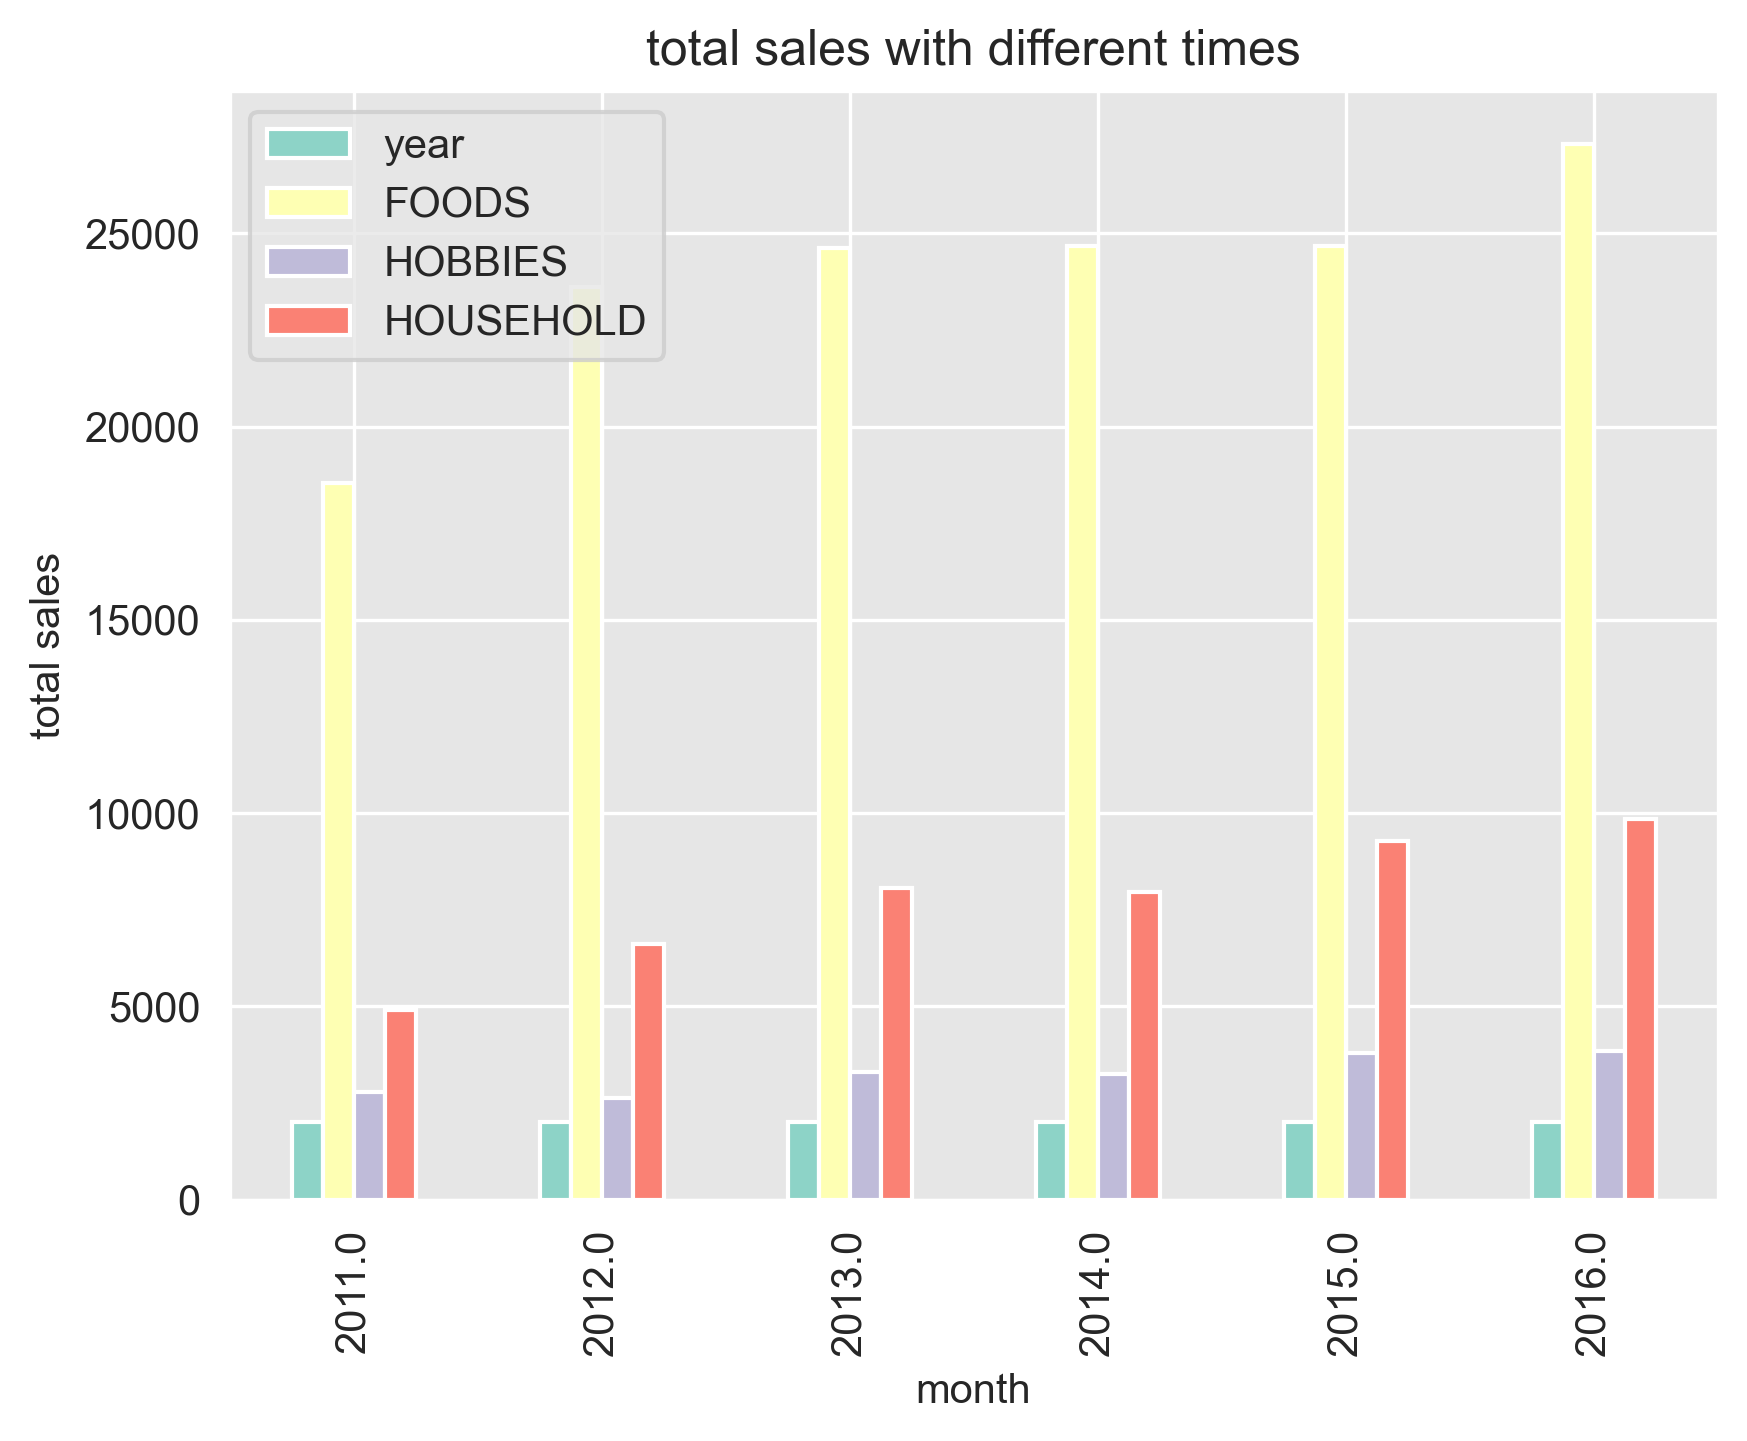

In [26]:
f_cate.index=f_cate['year']
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
f_cate.plot(kind='bar')
plt.xlabel('month')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

All product categories exhibit a similar upward trend over time, indicating that long-term demand growth affects categories uniformly despite differences in sales volume.

In [27]:
h_cate=category.groupby(["year","month"])[['FOODS','HOBBIES','HOUSEHOLD']].sum().reset_index()

<Figure size 2400x1800 with 0 Axes>

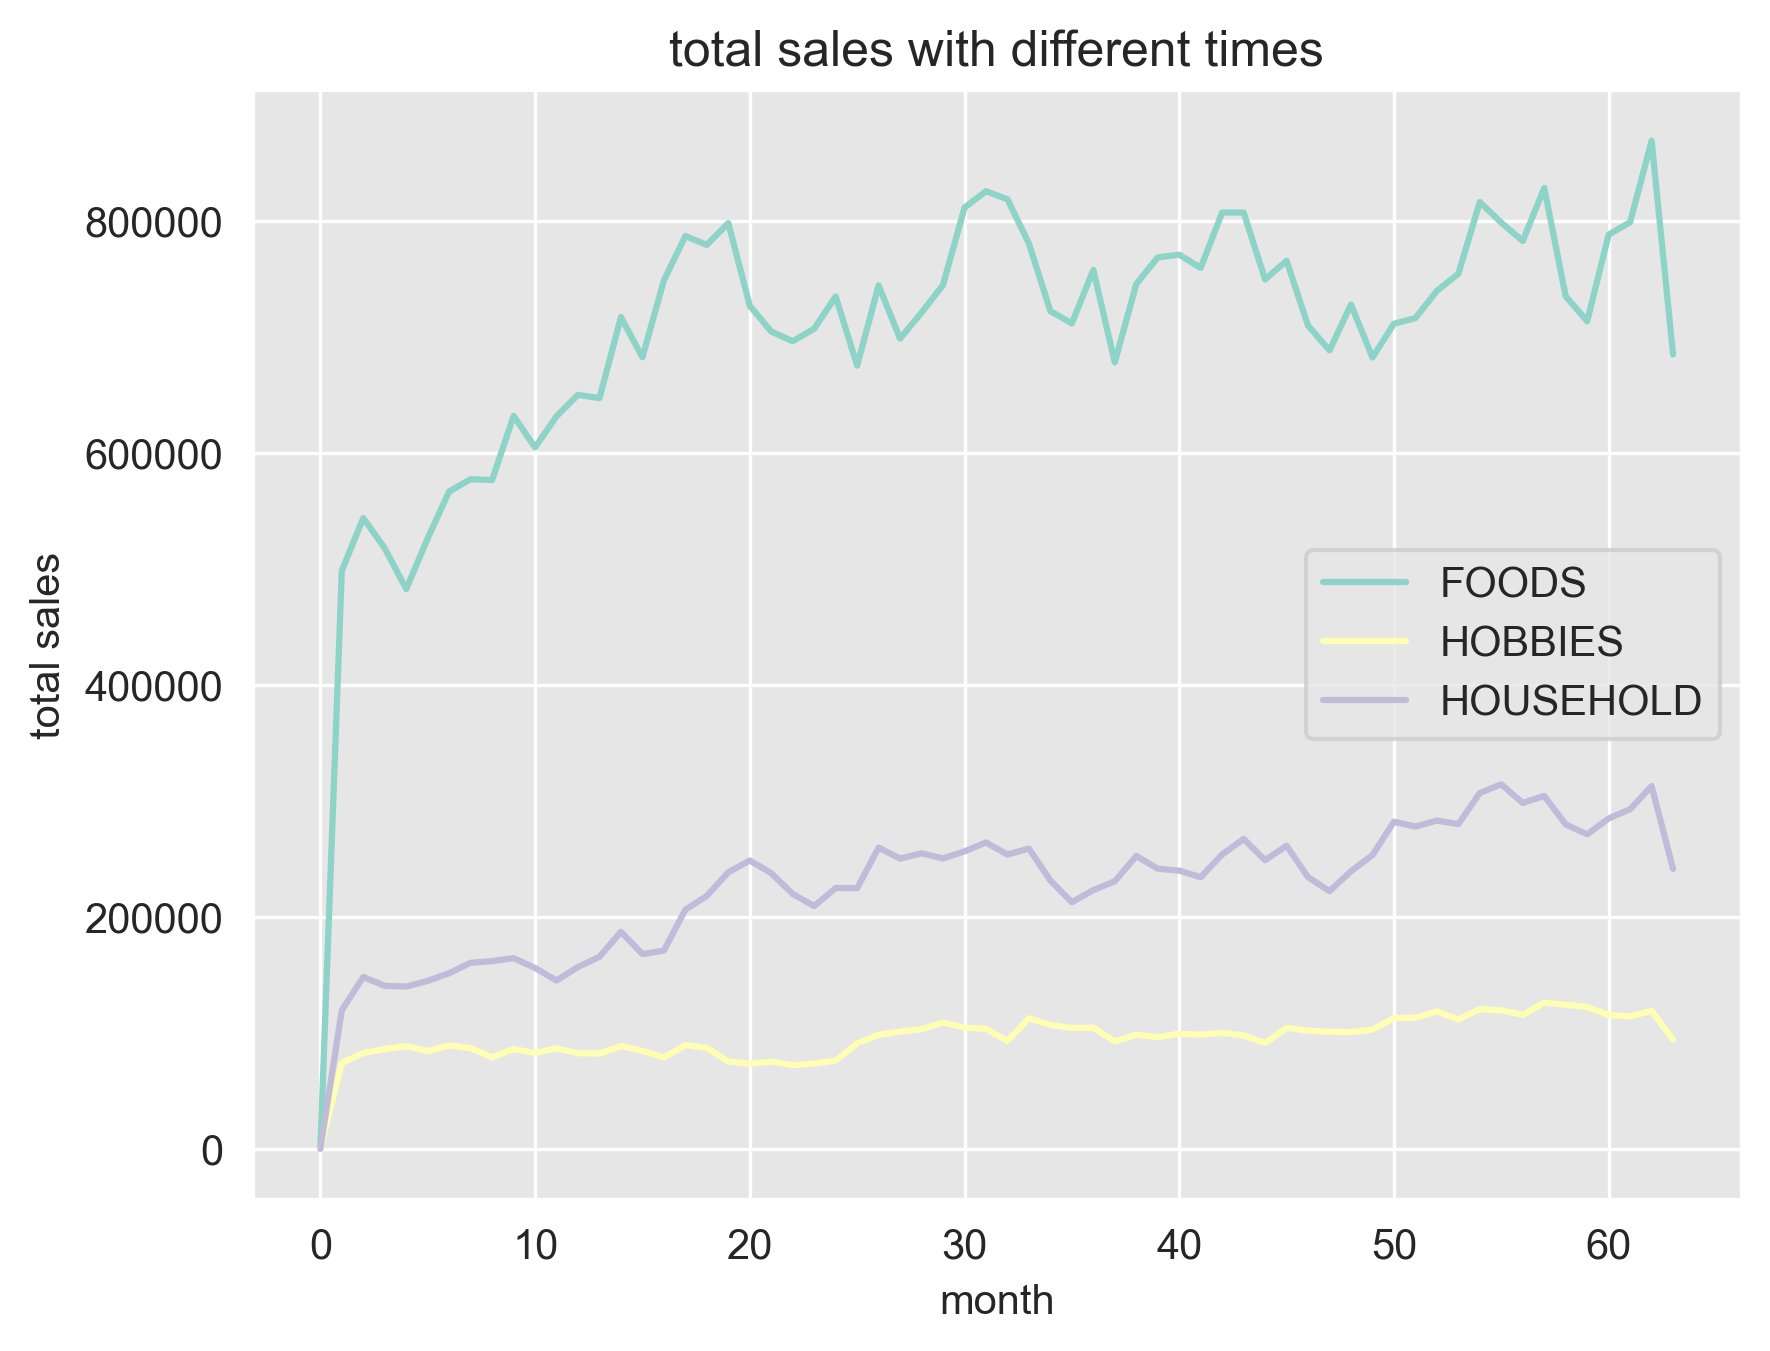

In [28]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8,6))
h_cate[['FOODS','HOBBIES','HOUSEHOLD']].plot(kind='line')
plt.xlabel('month')
plt.ylabel("total sales")
plt.title('total sales with different times')
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['figure.dpi'] = 300
#plt.savefig('1.png',dpi=900,bbox_inches='tight')  #save the file
plt.show()

All categories display a common upward trend with similar temporal fluctuations, indicating that shared time-related factors drive demand, while differences across categories are mainly in sales magnitude.

<Figure size 2400x1800 with 0 Axes>

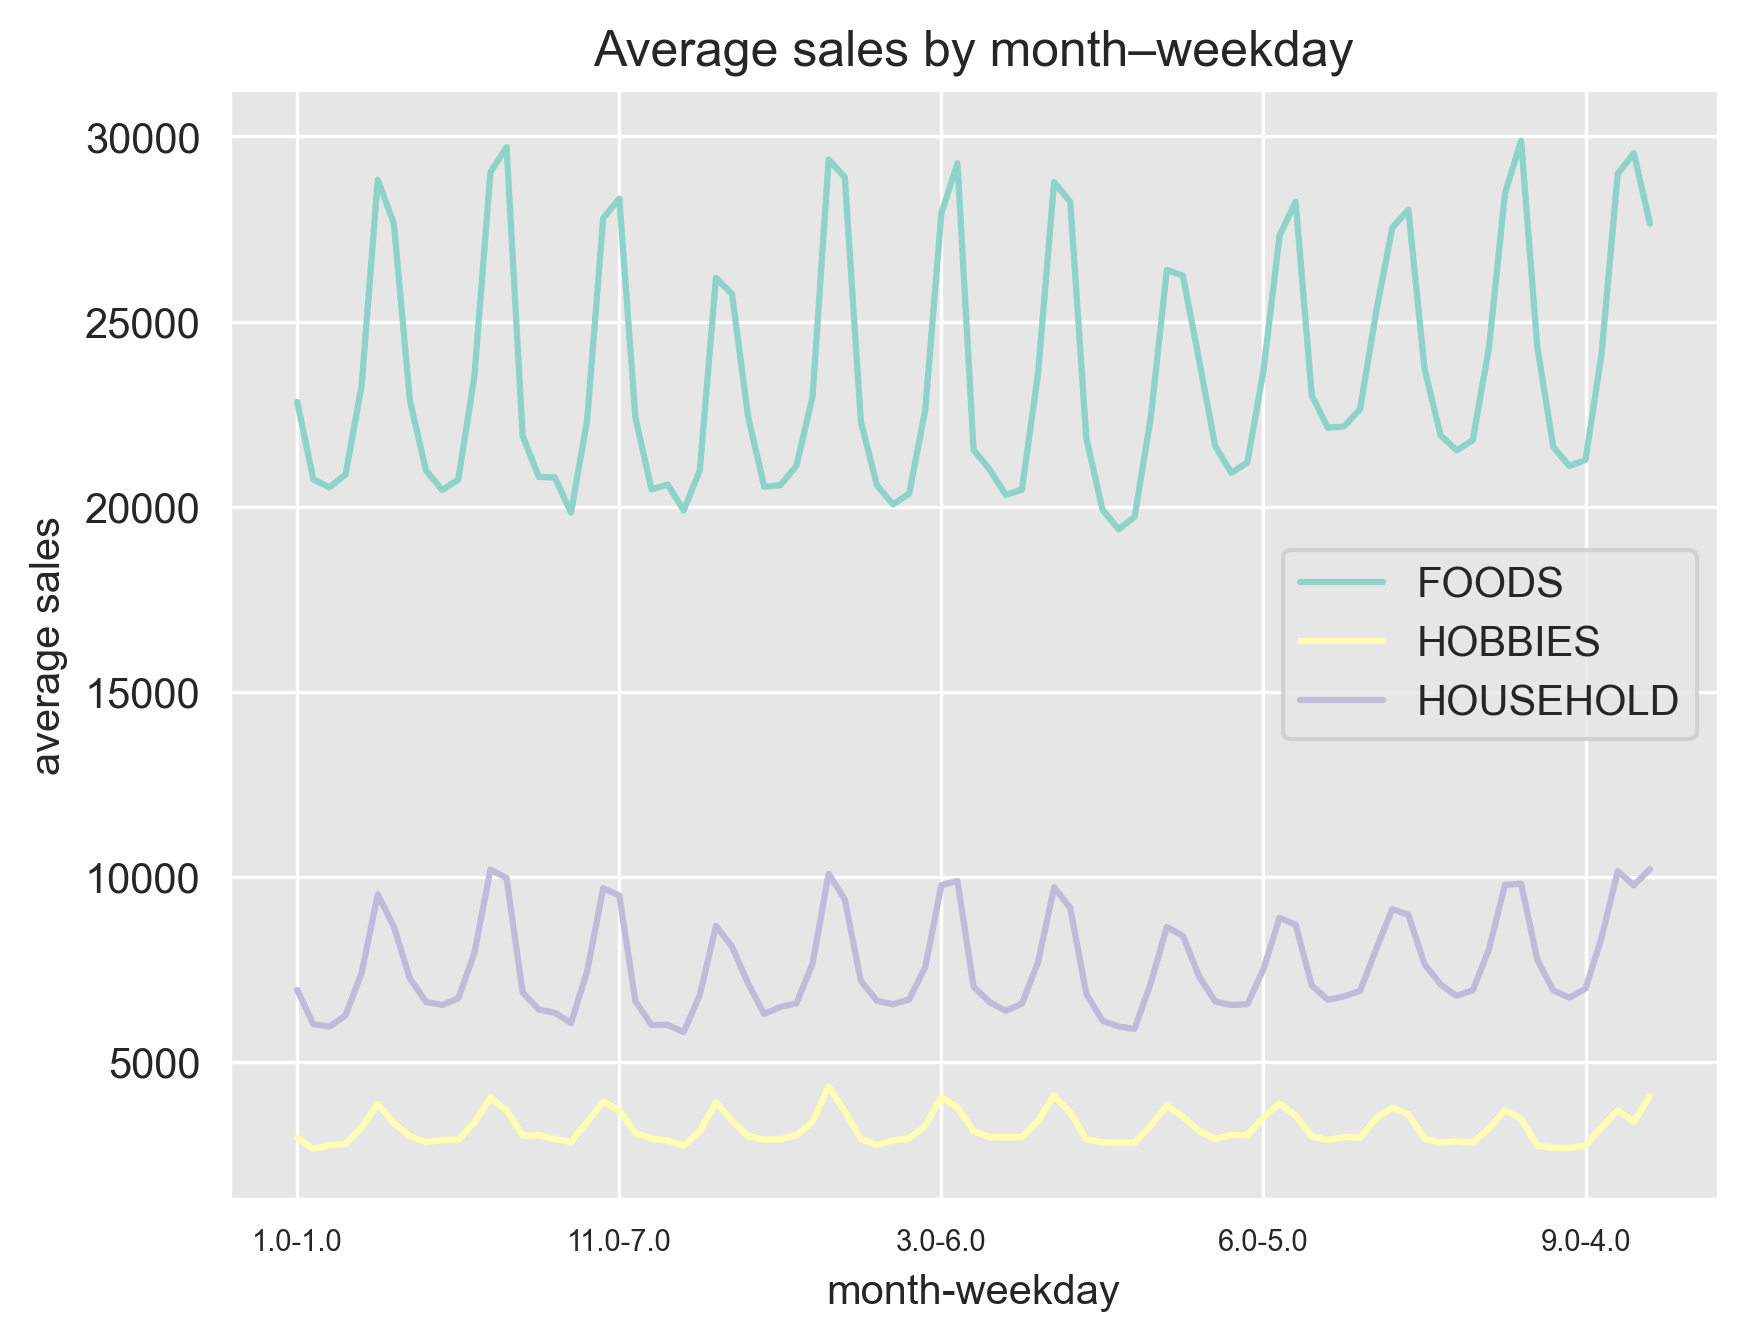

In [29]:
# 1. Create month-weekday key
category['month-weekday'] = (
    category['month'].astype(str) + '-' + category['wday'].astype(str)
)

# 2. Aggregate by month-weekday
cols = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
i_cate = (
    category
    .groupby('month-weekday')[cols]
    .mean()
    .reset_index()
)

# 3. Set index
i_cate = i_cate.set_index('month-weekday')

# 4. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(8, 6))

ax = i_cate[cols].plot()

plt.xlabel('month-weekday')
plt.ylabel('average sales')
plt.title('Average sales by month–weekday')

ax.set_xticklabels(ax.get_xticklabels(), size=7)

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300

plt.show()


### Overall:
The interaction between month and weekday reveals a consistent temporal structure across all product categories, with broadly similar cyclical patterns over the calendar. However, the magnitude of variability differs substantially by category. FOODS exhibits the largest fluctuations, indicating a high sensitivity to combined monthly and intra-week effects, likely reflecting frequent and time-dependent purchasing behavior. HOBBIES shows moderate variability, suggesting some responsiveness to calendar effects but with more stable demand relative to FOODS. In contrast, HOUSEHOLD displays the lowest level of fluctuation, indicating comparatively stable demand that is less influenced by short-term calendar dynamics.

These differences imply that while common temporal drivers affect all categories, the strength of their impact varies by product type. As a result, forecasting models should allow for category-specific sensitivity to calendar interactions, even when using shared time-based features.

## Analyze the relationship between sales volume and its past periods

In [30]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,d_251,d_252,d_253,d_254,d_255,d_256,d_257,d_258,d_259,d_260,d_261,d_262,d_263,d_264,d_265,d_266,d_267,d_268,d_269,d_270,d_271,d_272,d_273,d_274,d_275,d_276,d_277,d_278,d_279,d_280,d_281,d_282,d_283,d_284,d_285,d_286,d_287,d_288,d_289,d_290,d_291,d_292,d_293,d_294,d_295,d_296,d_297,d_298,d_299,d_300,d_301,d_302,d_303,d_304,d_305,d_306,d_307,d_308,d_309,d_310,d_311,d_312,d_313,d_314,d_315,d_316,d_317,d_318,d_319,d_320,d_321,d_322,d_323,d_324,d_325,d_326,d_327,d_328,d_329,d_330,d_331,d_332,d_333,d_334,d_335,d_336,d_337,d_338,d_339,d_340,d_341,d_342,d_343,d_344,d_345,d_346,d_347,d_348,d_349,d_350,d_351,d_352,d_353,d_354,d_355,d_356,d_357,d_358,d_359,d_360,d_361,d_362,d_363,d_364,d_365,d_366,d_367,d_368,d_369,d_370,d_371,d_372,d_373,d_374,d_375,d_376,d_377,d_378,d_379,d_380,d_381,d_382,d_383,d_384,d_385,d_386,d_387,d_388,d_389,d_390,d_391,d_392,d_393,d_394,d_395,d_396,d_397,d_398,d_399,d_400,d_401,d_402,d_403,d_404,d_405,d_406,d_407,d_408,d_409,d_410,d_411,d_412,d_413,d_414,d_415,d_416,d_417,d_418,d_419,d_420,d_421,d_422,d_423,d_424,d_425,d_426,d_427,d_428,d_429,d_430,d_431,d_432,d_433,d_434,d_435,d_436,d_437,d_438,d_439,d_440,d_441,d_442,d_443,d_444,d_445,d_446,d_447,d_448,d_449,d_450,d_451,d_452,d_453,d_454,d_455,d_456,d_457,d_458,d_459,d_460,d_461,d_462,d_463,d_464,d_465,d_466,d_467,d_468,d_469,d_470,d_471,d_472,d_473,d_474,d_475,d_476,d_477,d_478,d_479,d_480,d_481,d_482,d_483,d_484,d_485,d_486,d_487,d_488,d_489,d_490,d_491,d_492,d_493,d_494,...,d_1414,d_1415,d_1416,d_1417,d_1418,d_1419,d_1420,d_1421,d_1422,d_1423,d_1424,d_1425,d_1426,d_1427,d_1428,d_1429,d_1430,d_1431,d_1432,d_1433,d_1434,d_1435,d_1436,d_1437,d_1438,d_1439,d_1440,d_1441,d_1442,d_1443,d_1444,d_1445,d_1446,d_1447,d_1448,d_1449,d_1450,d_1451,d_1452,d_1453,d_1454,d_1455,d_1456,d_1457,d_1458,d_1459,d_1460,d_1461,d_1462,d_1463,d_1464,d_1465,d_1466,d_1467,d_1468,d_1469,d_1470,d_1471,d_1472,d_1473,d_1474,d_1475,d_1476,d_1477,d_1478,d_1479,d_1480,d_1481,d_1482,d_1483,d_1484,d_1485,d_1486,d_1487,d_1488,d_1489,d_1490,d_1491,d_1492,d_1493,d_1494,d_1495,d_1496,d_1497,d_1498,d_1499,d_1500,d_1501,d_1502,d_1503,d_1504,d_1505,d_1506,d_1507,d_1508,d_1509,d_1510,d_1511,d_1512,d_1513,d_1514,d_1515,d_1516,d_1517,d_1518,d_1519,d_1520,d_1521,d_1522,d_1523,d_1524,d_1525,d_1526,d_1527,d_1528,d_1529,d_1530,d_1531,d_1532,d_1533,d_1534,d_1535,d_1536,d_1537,d_1538,d_1539,d_1540,d_1541,d_1542,d_1543,d_1544,d_1545,d_1546,d_1547,d_1548,d_1549,d_1550,d_1551,d_1552,d_1553,d_1554,d_1555,d_1556,d_1557,d_1558,d_1559,d_1560,d_1561,d_1562,d_1563,d_1564,d_1565,d_1566,d_1567,d_1568,d_1569,d_1

In [31]:
ww=sales[sales['state_id']=='TX']
ww= ww[sales['cat_id']=='FOODS']
www=ww.sum(axis=0)
www=pd.DataFrame(www)
www=www.reset_index()
www=www[6:]
www.columns=['day','sale']
www=www.reset_index().drop('index',axis=1)
www['sale']=www['sale'].astype('int')
www['t']=list(range(1,1914))

C:\Users\herna\AppData\Local\Temp\ipykernel_30704\1319183110.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ww= ww[sales['cat_id']=='FOODS']


In [32]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import linregress

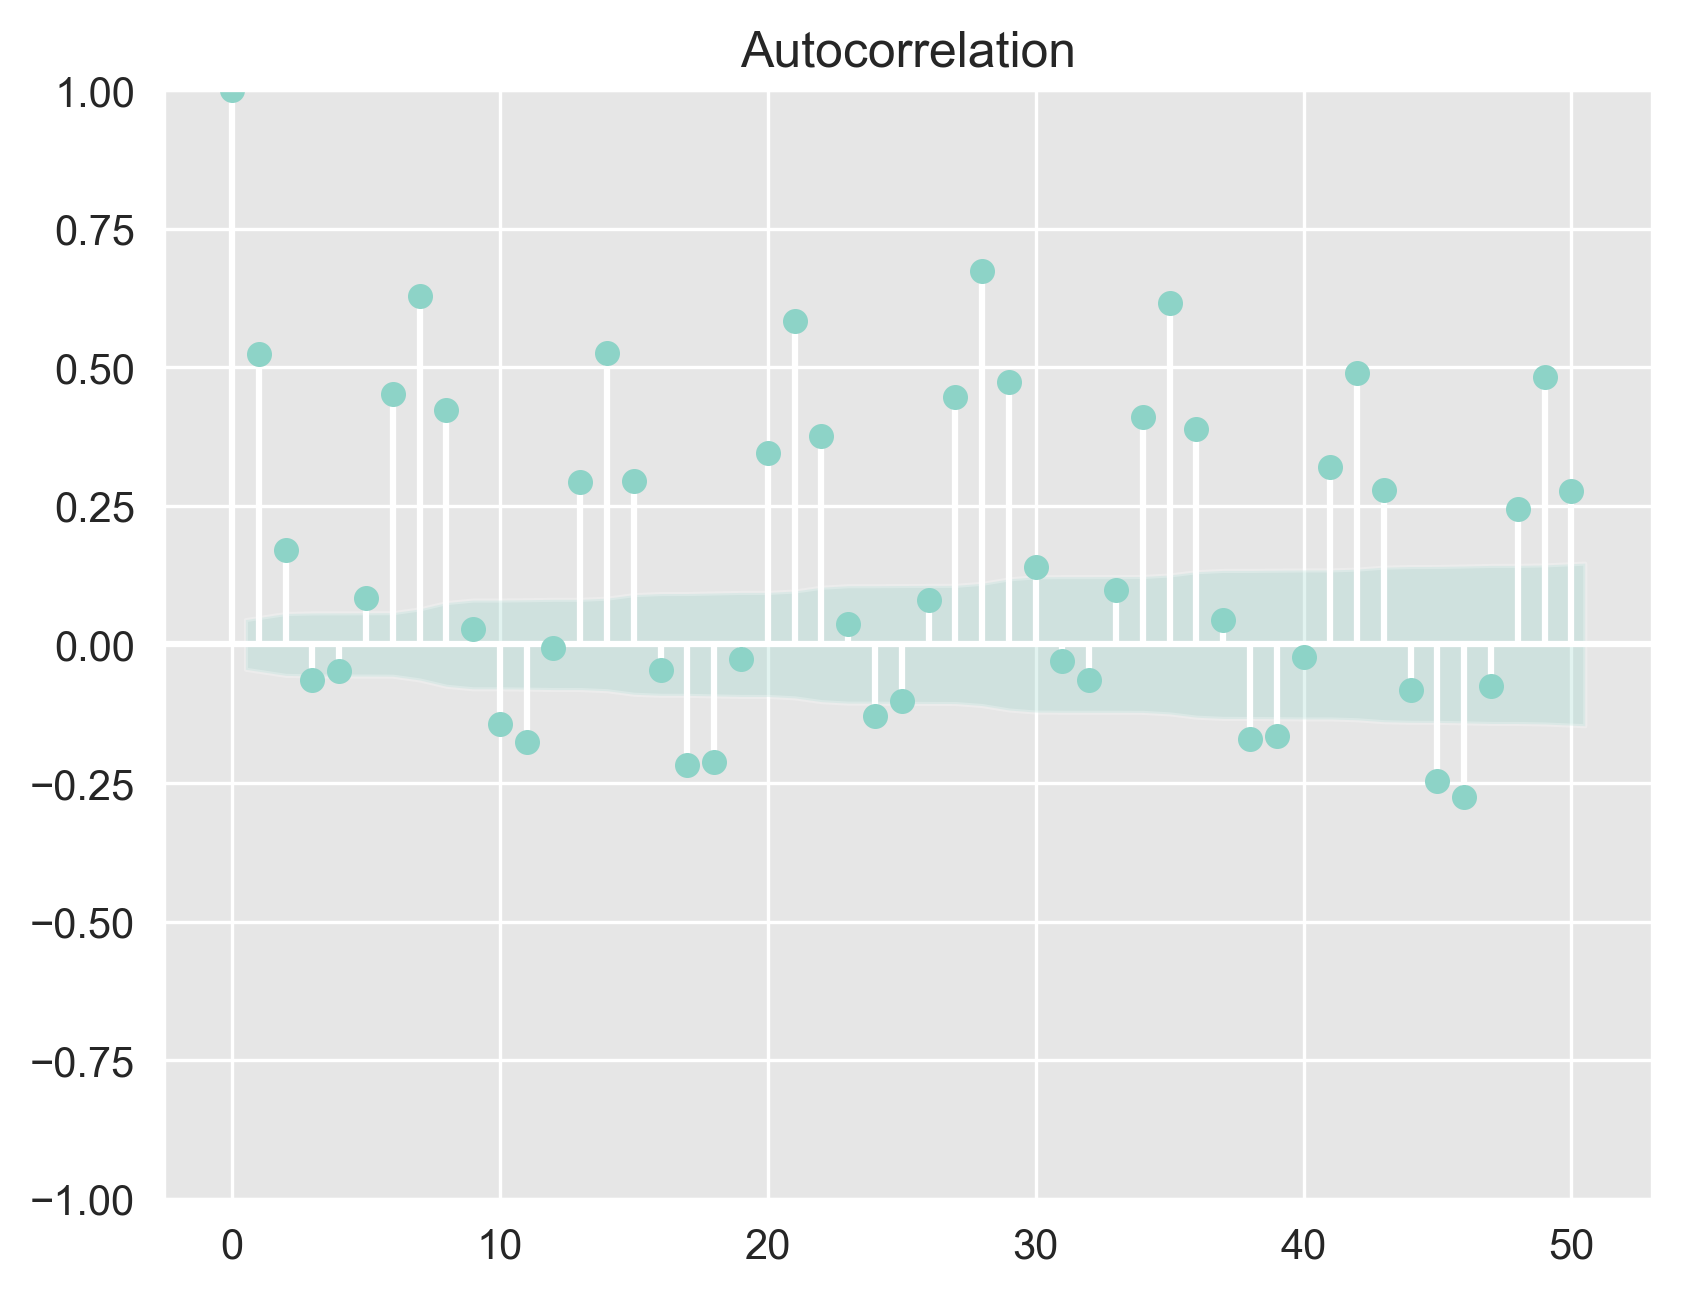

In [33]:
plot_acf(www['sale'],lags=50)
plt.show()

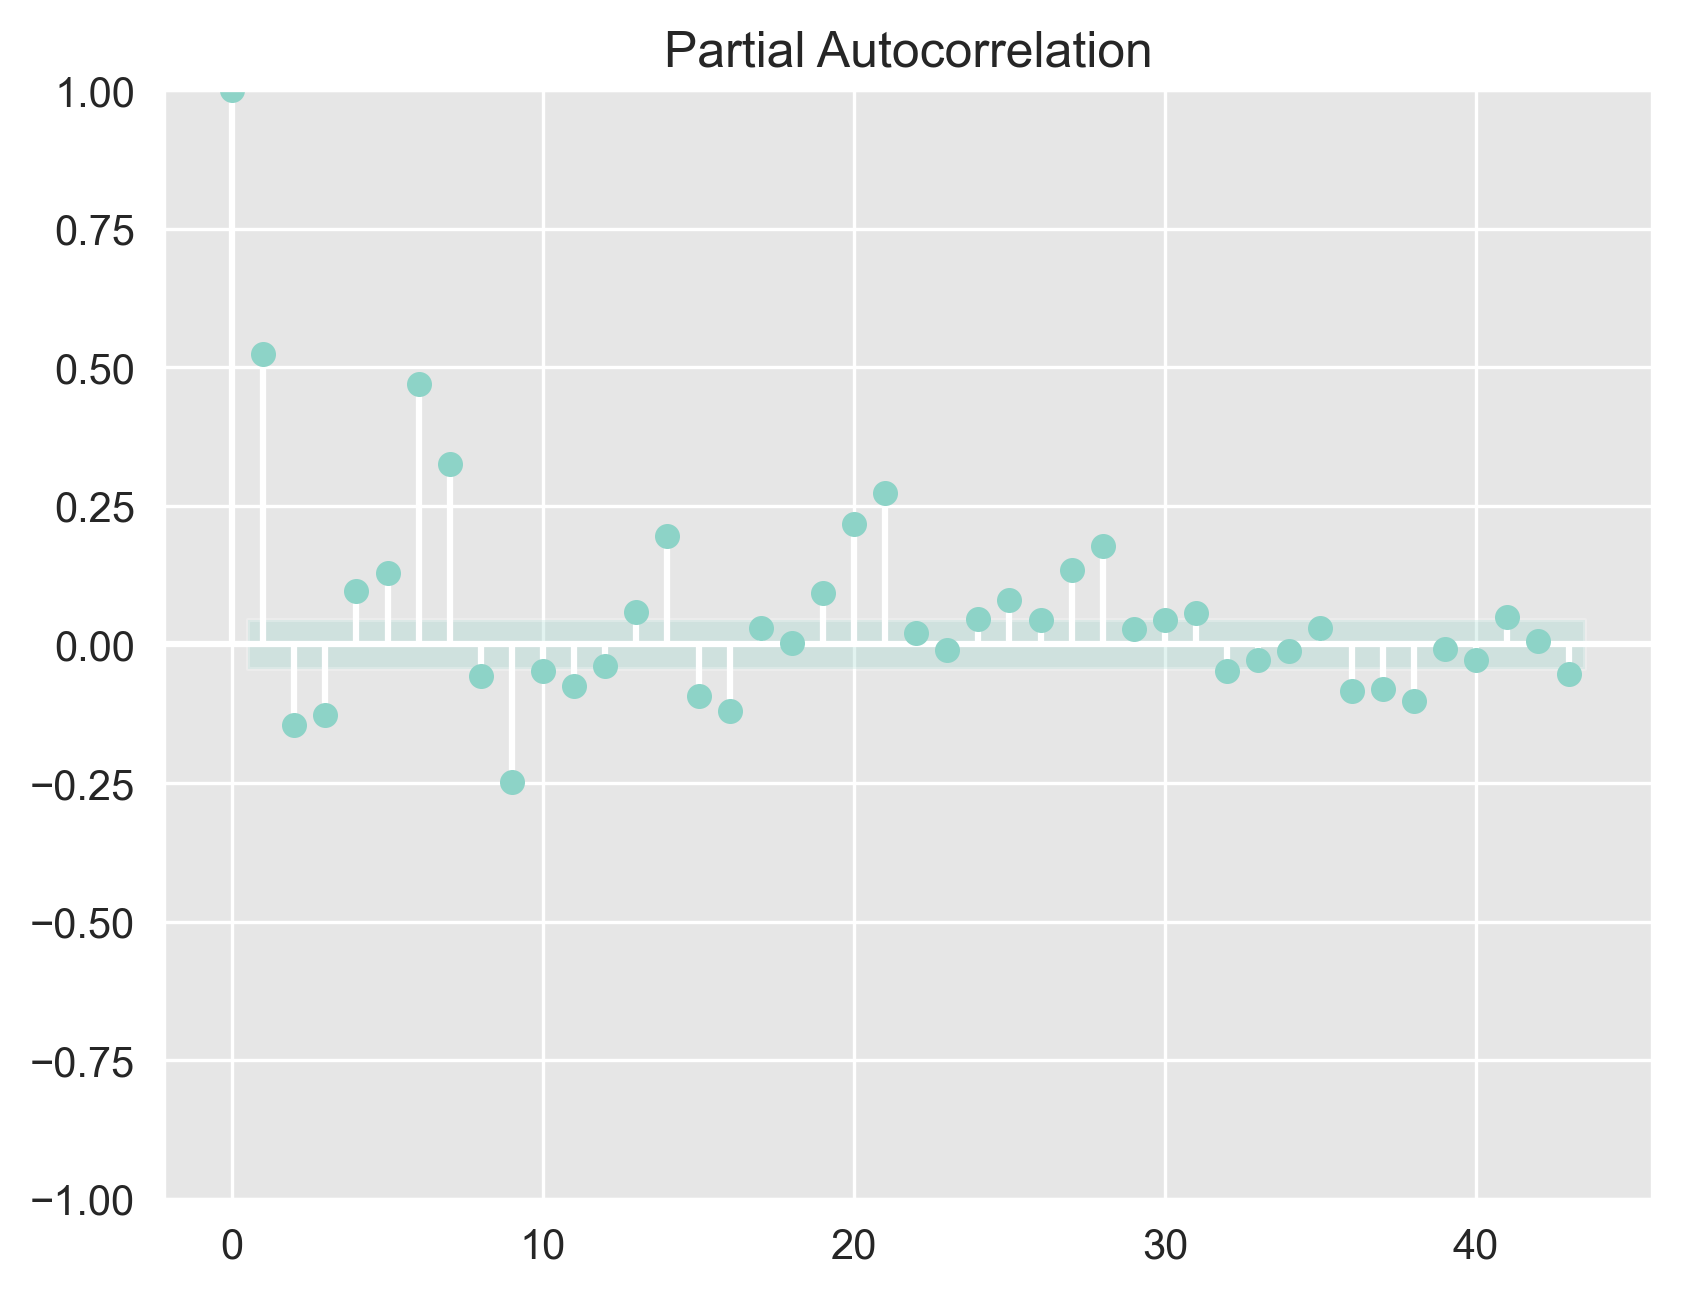

In [34]:
plot_pacf(www['sale'],lags=43)
plt.show()

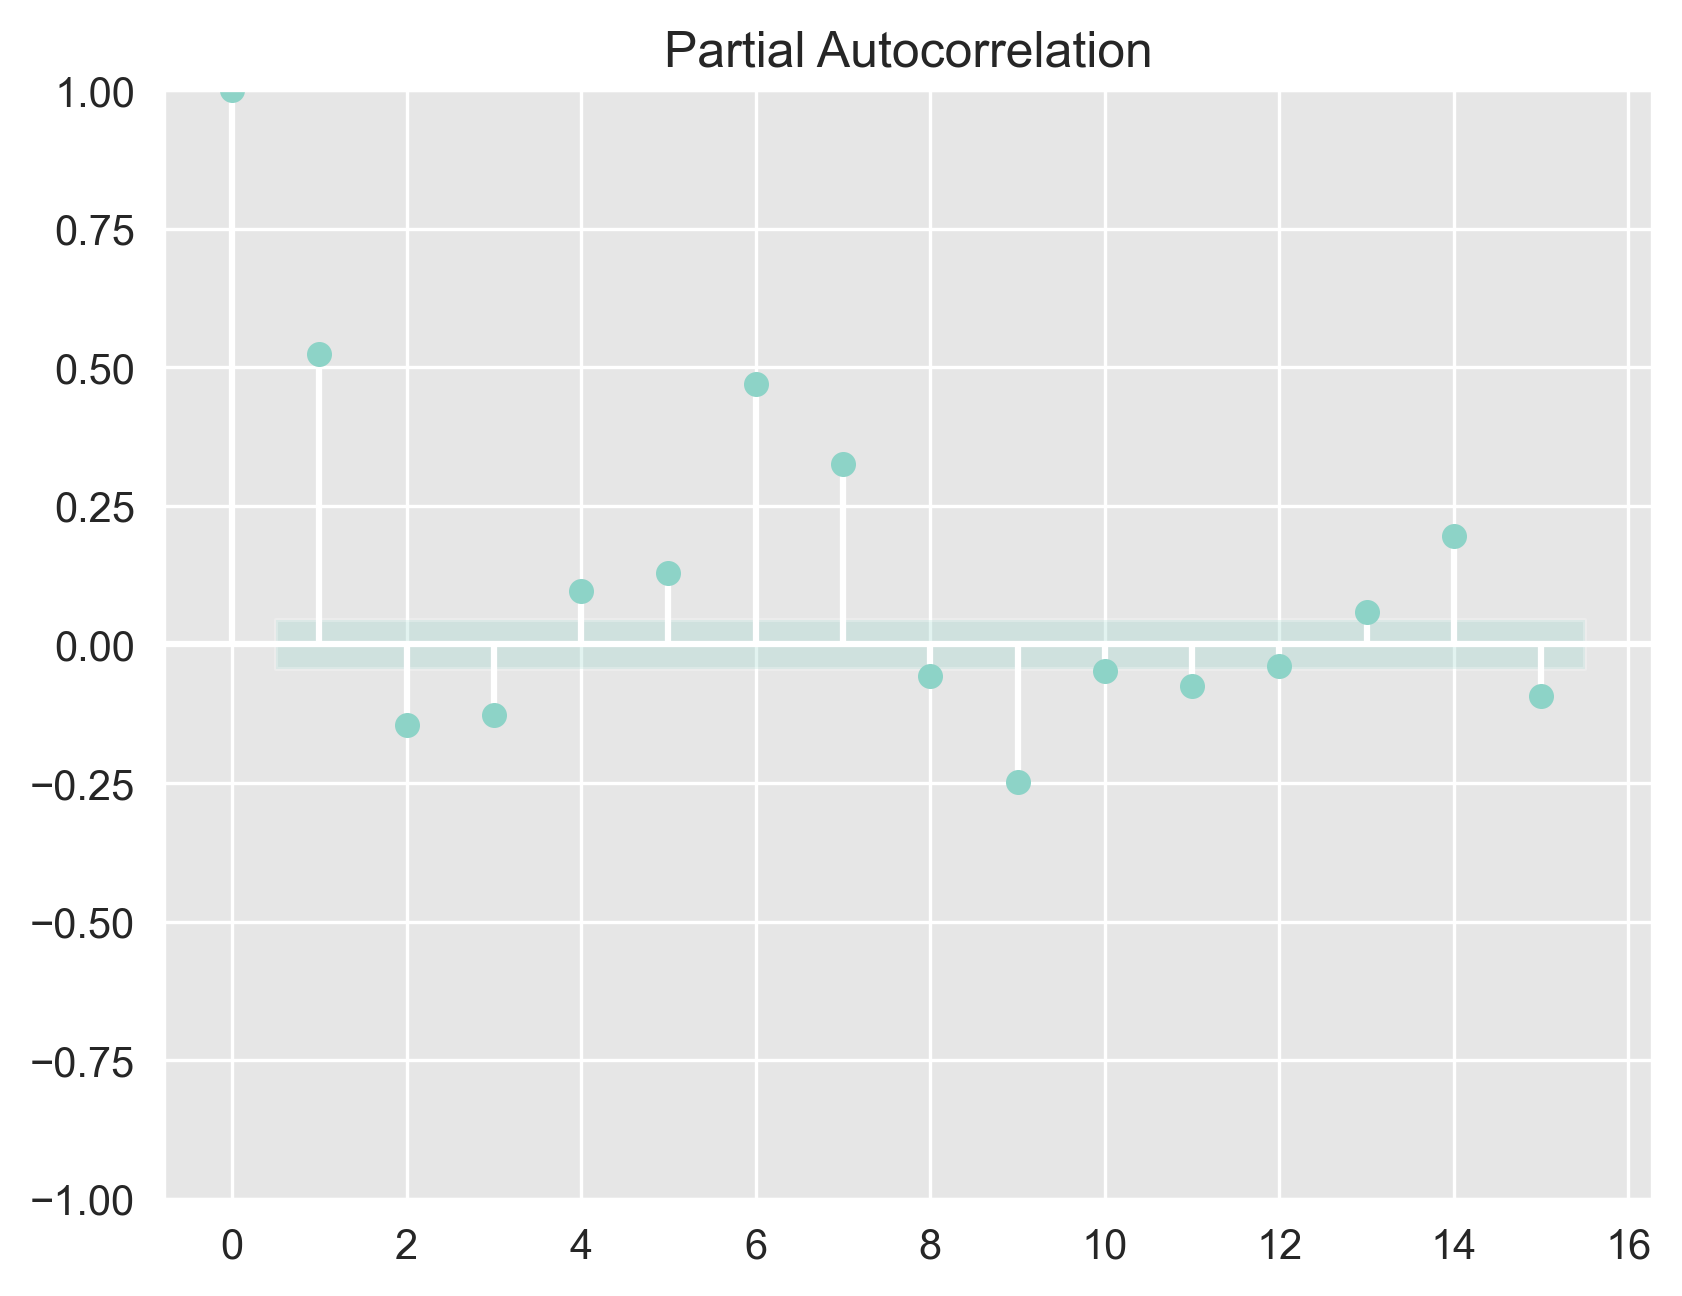

In [35]:
plot_pacf(www['sale'],lags=15)
plt.show()

#### From the above, we can infer that the sales volume for the current period is likely highly correlated with the sales volume on the same day of the previous week.

The autocorrelation (ACF) plot shows statistically significant correlations at several low-order lags, indicating strong temporal dependence in sales and confirming that current values are influenced by recent past observations. In addition, recurring peaks at regular intervals suggest the presence of seasonal patterns, consistent with weekly and monthly demand cycles observed earlier in the exploratory analysis.

The partial autocorrelation (PACF) plot reveals a small number of significant spikes at early lags, after which the correlations drop rapidly toward zero. This behavior indicates that most of the temporal structure can be explained by a limited number of autoregressive terms, while higher-order lags contribute marginal additional information. The rapid decay in the PACF supports the use of a low-order AR component.

Overall, the ACF and PACF results confirm that the series is not white noise, exhibits both short-term dependence and seasonality, and is therefore suitable for time-series models such as ARIMA/SARIMA. The identified lag structure provides empirical justification for selecting autoregressive orders and incorporating differencing and seasonal components in subsequent forecasting models.

### Exploratory Data Analysis: SNAP and Sales

This section explores the relationship between product sales and participation in the Supplemental Nutrition Assistance Program (SNAP). The objective of this analysis is to assess whether SNAP-related effects are associated with systematic changes in sales patterns and to determine whether SNAP should be included as a predictive feature in subsequent forecasting models.

The Supplemental Nutrition Assistance Program (SNAP) is a federal assistance program in the United States that provides eligible low-income households with financial support to purchase food. SNAP benefits are typically distributed on a monthly schedule, which may induce recurring demand patterns as households adjust their purchasing behaviour around benefit issuance dates.

The M5 dataset includes binary indicators reflecting SNAP eligibility by state and date. By examining sales dynamics during SNAP and non-SNAP periods, this exploratory analysis aims to identify potential demand shifts linked to benefit distribution cycles. Evidence of consistent sales effects would justify incorporating SNAP indicators as exogenous variables in forecasting models.


SNAP Program: https://www.feedingamerica.org/take-action/advocate/federal-hunger-relief-programs/snap







In [36]:
sells_train = pd.read_csv("data/sales_train_validation.csv")
sells_train.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,d_251,d_252,d_253,d_254,d_255,d_256,d_257,d_258,d_259,d_260,d_261,d_262,d_263,d_264,d_265,d_266,d_267,d_268,d_269,d_270,d_271,d_272,d_273,d_274,d_275,d_276,d_277,d_278,d_279,d_280,d_281,d_282,d_283,d_284,d_285,d_286,d_287,d_288,d_289,d_290,d_291,d_292,d_293,d_294,d_295,d_296,d_297,d_298,d_299,d_300,d_301,d_302,d_303,d_304,d_305,d_306,d_307,d_308,d_309,d_310,d_311,d_312,d_313,d_314,d_315,d_316,d_317,d_318,d_319,d_320,d_321,d_322,d_323,d_324,d_325,d_326,d_327,d_328,d_329,d_330,d_331,d_332,d_333,d_334,d_335,d_336,d_337,d_338,d_339,d_340,d_341,d_342,d_343,d_344,d_345,d_346,d_347,d_348,d_349,d_350,d_351,d_352,d_353,d_354,d_355,d_356,d_357,d_358,d_359,d_360,d_361,d_362,d_363,d_364,d_365,d_366,d_367,d_368,d_369,d_370,d_371,d_372,d_373,d_374,d_375,d_376,d_377,d_378,d_379,d_380,d_381,d_382,d_383,d_384,d_385,d_386,d_387,d_388,d_389,d_390,d_391,d_392,d_393,d_394,d_395,d_396,d_397,d_398,d_399,d_400,d_401,d_402,d_403,d_404,d_405,d_406,d_407,d_408,d_409,d_410,d_411,d_412,d_413,d_414,d_415,d_416,d_417,d_418,d_419,d_420,d_421,d_422,d_423,d_424,d_425,d_426,d_427,d_428,d_429,d_430,d_431,d_432,d_433,d_434,d_435,d_436,d_437,d_438,d_439,d_440,d_441,d_442,d_443,d_444,d_445,d_446,d_447,d_448,d_449,d_450,d_451,d_452,d_453,d_454,d_455,d_456,d_457,d_458,d_459,d_460,d_461,d_462,d_463,d_464,d_465,d_466,d_467,d_468,d_469,d_470,d_471,d_472,d_473,d_474,d_475,d_476,d_477,d_478,d_479,d_480,d_481,d_482,d_483,d_484,d_485,d_486,d_487,d_488,d_489,d_490,d_491,d_492,d_493,d_494,...,d_1414,d_1415,d_1416,d_1417,d_1418,d_1419,d_1420,d_1421,d_1422,d_1423,d_1424,d_1425,d_1426,d_1427,d_1428,d_1429,d_1430,d_1431,d_1432,d_1433,d_1434,d_1435,d_1436,d_1437,d_1438,d_1439,d_1440,d_1441,d_1442,d_1443,d_1444,d_1445,d_1446,d_1447,d_1448,d_1449,d_1450,d_1451,d_1452,d_1453,d_1454,d_1455,d_1456,d_1457,d_1458,d_1459,d_1460,d_1461,d_1462,d_1463,d_1464,d_1465,d_1466,d_1467,d_1468,d_1469,d_1470,d_1471,d_1472,d_1473,d_1474,d_1475,d_1476,d_1477,d_1478,d_1479,d_1480,d_1481,d_1482,d_1483,d_1484,d_1485,d_1486,d_1487,d_1488,d_1489,d_1490,d_1491,d_1492,d_1493,d_1494,d_1495,d_1496,d_1497,d_1498,d_1499,d_1500,d_1501,d_1502,d_1503,d_1504,d_1505,d_1506,d_1507,d_1508,d_1509,d_1510,d_1511,d_1512,d_1513,d_1514,d_1515,d_1516,d_1517,d_1518,d_1519,d_1520,d_1521,d_1522,d_1523,d_1524,d_1525,d_1526,d_1527,d_1528,d_1529,d_1530,d_1531,d_1532,d_1533,d_1534,d_1535,d_1536,d_1537,d_1538,d_1539,d_1540,d_1541,d_1542,d_1543,d_1544,d_1545,d_1546,d_1547,d_1548,d_1549,d_1550,d_1551,d_1552,d_1553,d_1554,d_1555,d_1556,d_1557,d_1558,d_1559,d_1560,d_1561,d_1562,d_1563,d_1564,d_1565,d_1566,d_1567,d_1568,d_1569,d_1

In [37]:
sells_train.shape

(30490, 1919)

From the above, we have a total of 30,490 rows of data, with each data having 1,919 columns. These columns include basic information about the products and its sales volume from d_1 to d_1913.

Next, read the data from "calendar.csv."

In [38]:
calendar = pd.read_csv("data/calendar.csv")
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [39]:
calendar.shape

(1969, 14)

**day_extraction(calendar, snap, state, end_day)**

Extract specific days based on the parameters and return an array containing those days.

- calendar: the calendar data used
- snap: 1 for snap = True, 0 for snap = False.
- state: one of the three states - "CA," "TX," or "WI" (since the snap dates vary for each state
- end_day, default = 1913: The end date for extraction

In [40]:
def day_extraction(calendar, snap, state, end_day = 1913):
    snap2value = lambda x: 1 if x==True else 0
    value = snap2value(snap)
    stateName = 'snap_' + state
    day_list = calendar[calendar[stateName] == value].loc[:, 'd'].values.tolist()
    for i in range(len(day_list)-1, 0, -1):
        if int(day_list[i][-4:]) > 1913:
            day_list.pop()
        else:
            break
    return np.array(day_list)

#### State vs snap

In [41]:
state_list = sells_train['state_id'].value_counts().index.tolist()
days_list = []
mean_with_snap = []
mean_without_snap = []
for i in range(len(state_list)):
    days_list.append(day_extraction(calendar, snap = True, state = state_list[i]))
    days_list.append(day_extraction(calendar, snap = False, state = state_list[i]))
    mean_with_snap.append(sells_train[(sells_train['state_id'] == state_list[i])].loc[:, days_list[2*i]].mean().mean())
    mean_without_snap.append(sells_train[(sells_train['state_id'] == state_list[i])].loc[:, days_list[2*i+1]].mean().mean())

d = {'state' : state_list*2, 'mean' : mean_with_snap + mean_without_snap ,'snap':['With snap']*3 + ['Without snap']*3}
snap_df = pd.DataFrame(d)

In [42]:
snap_df

,state,mean,snap
0,CA,1.293202,With snap
1,TX,1.160242,With snap
2,WI,1.176733,With snap
3,CA,1.197590,Without snap
4,TX,1.040678,Without snap
5,WI,0.966274,Without snap


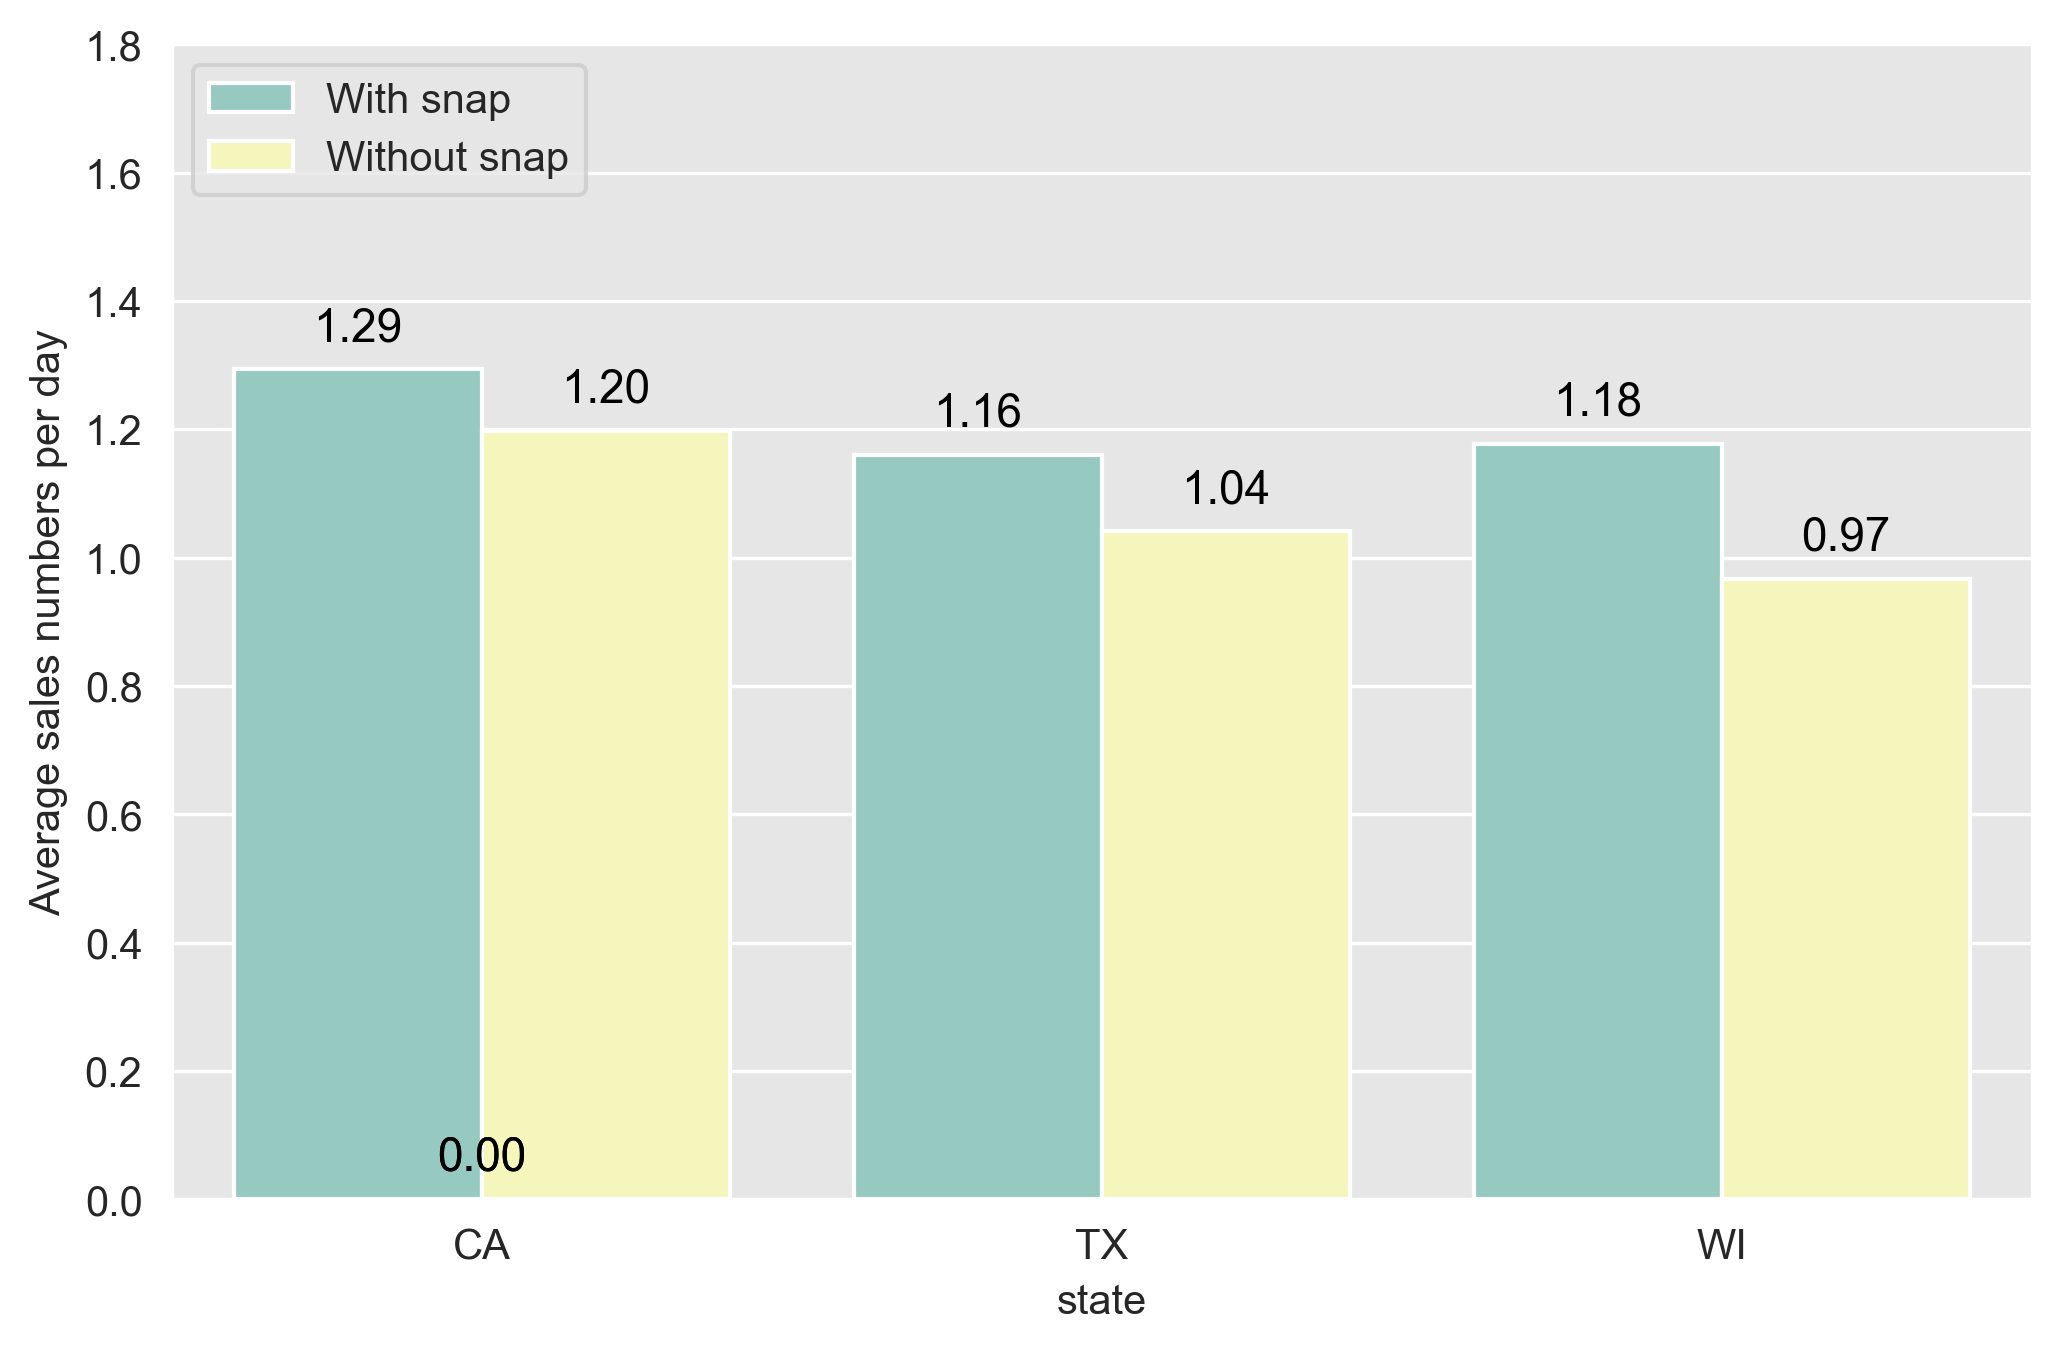

In [43]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="state", hue="snap", y="mean", data=snap_df)
ax.set_ylabel("Average sales numbers per day")
for p in ax.patches:
    ax.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
         ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
         textcoords='offset points')
_ = ax.set_ylim(0,1.8)
plt.legend(loc='upper left')
plt.show()
plt.close()

The figure compares average daily sales across states during SNAP and non-SNAP periods. In all states, sales are higher on SNAP-eligible days, indicating a positive association between SNAP participation and demand levels. The strength of this effect varies by state, suggesting heterogeneous demand responses.

These results support the inclusion of SNAP-related indicators as potential explanatory features in subsequent demand forecasting models.


In [44]:
snap_compare = snap_df.iloc[:3, :2].copy()
snap_compare.columns = ['State', 'Mean_with_snap']
snap_compare['Mean_without_snap'] = snap_df.iloc[3:,1].tolist()
snap_compare['Growth with snap(%)'] = (snap_compare['Mean_with_snap'] /snap_compare['Mean_without_snap'] - 1)*100
snap_compare

,State,Mean_with_snap,Mean_without_snap,Growth with snap(%)
0,CA,1.293202,1.197590,7.983615
1,TX,1.160242,1.040678,11.489051
2,WI,1.176733,0.966274,21.780524


We can learn from the above that snap has a positive impact on sales in all states, although the degree of impact varies slightly.

##### Product category vs snap
Analyze snap's impact on the sales volume of each product category in all states.

In [45]:
item_cat_list = sells_train['cat_id'].value_counts().index.tolist()
item_cat_list

['FOODS', 'HOUSEHOLD', 'HOBBIES']

In [46]:
state_list = sells_train['state_id'].value_counts().index.tolist()
days_list = []
mean_with_snap = []
mean_without_snap = []
for i in range(len(state_list)):
    days_list.append(day_extraction(calendar, snap = True, state = state_list[i]))
    days_list.append(day_extraction(calendar, snap = False, state = state_list[i]))
    for j in range(len(item_cat_list)):
      mean_with_snap.append(sells_train[(sells_train['state_id'] == state_list[i]) & (sells_train['cat_id']==item_cat_list[j])]\
                            .loc[:, days_list[2*i]].mean().mean())
      mean_without_snap.append(sells_train[(sells_train['state_id'] == state_list[i])& (sells_train['cat_id']==item_cat_list[j])]\
                               .loc[:, days_list[2*i+1]].mean().mean())

In [47]:
state_list_dup = state_list*3
state_list_dup.sort()
d = {'state' : state_list_dup*2, 'mean' : mean_with_snap + mean_without_snap ,'cat_id':item_cat_list*6, 'snap':['With snap']*9 + ['Without snap']*9}
snap_df = pd.DataFrame(d)
snap_df['state_cat_id'] = snap_df['state'] + '_' + snap_df['cat_id']
snap_df

,state,mean,cat_id,snap,state_cat_id
0,CA,1.862391,FOODS,With snap,CA_FOODS
1,CA,0.822962,HOUSEHOLD,With snap,CA_HOUSEHOLD
2,CA,0.716944,HOBBIES,With snap,CA_HOBBIES
3,TX,1.727489,FOODS,With snap,TX_FOODS
4,TX,0.739282,HOUSEHOLD,With snap,TX_HOUSEHOLD
5,TX,0.497606,HOBBIES,With snap,TX_HOBBIES
6,WI,1.855156,FOODS,With snap,WI_FOODS
7,WI,0.629186,HOUSEHOLD,With snap,WI_HOUSEHOLD
8,WI,0.465915,HOBBIES,With snap,WI_HOBBIES
9,CA,1.688498,FOODS,Without snap,CA_FOODS


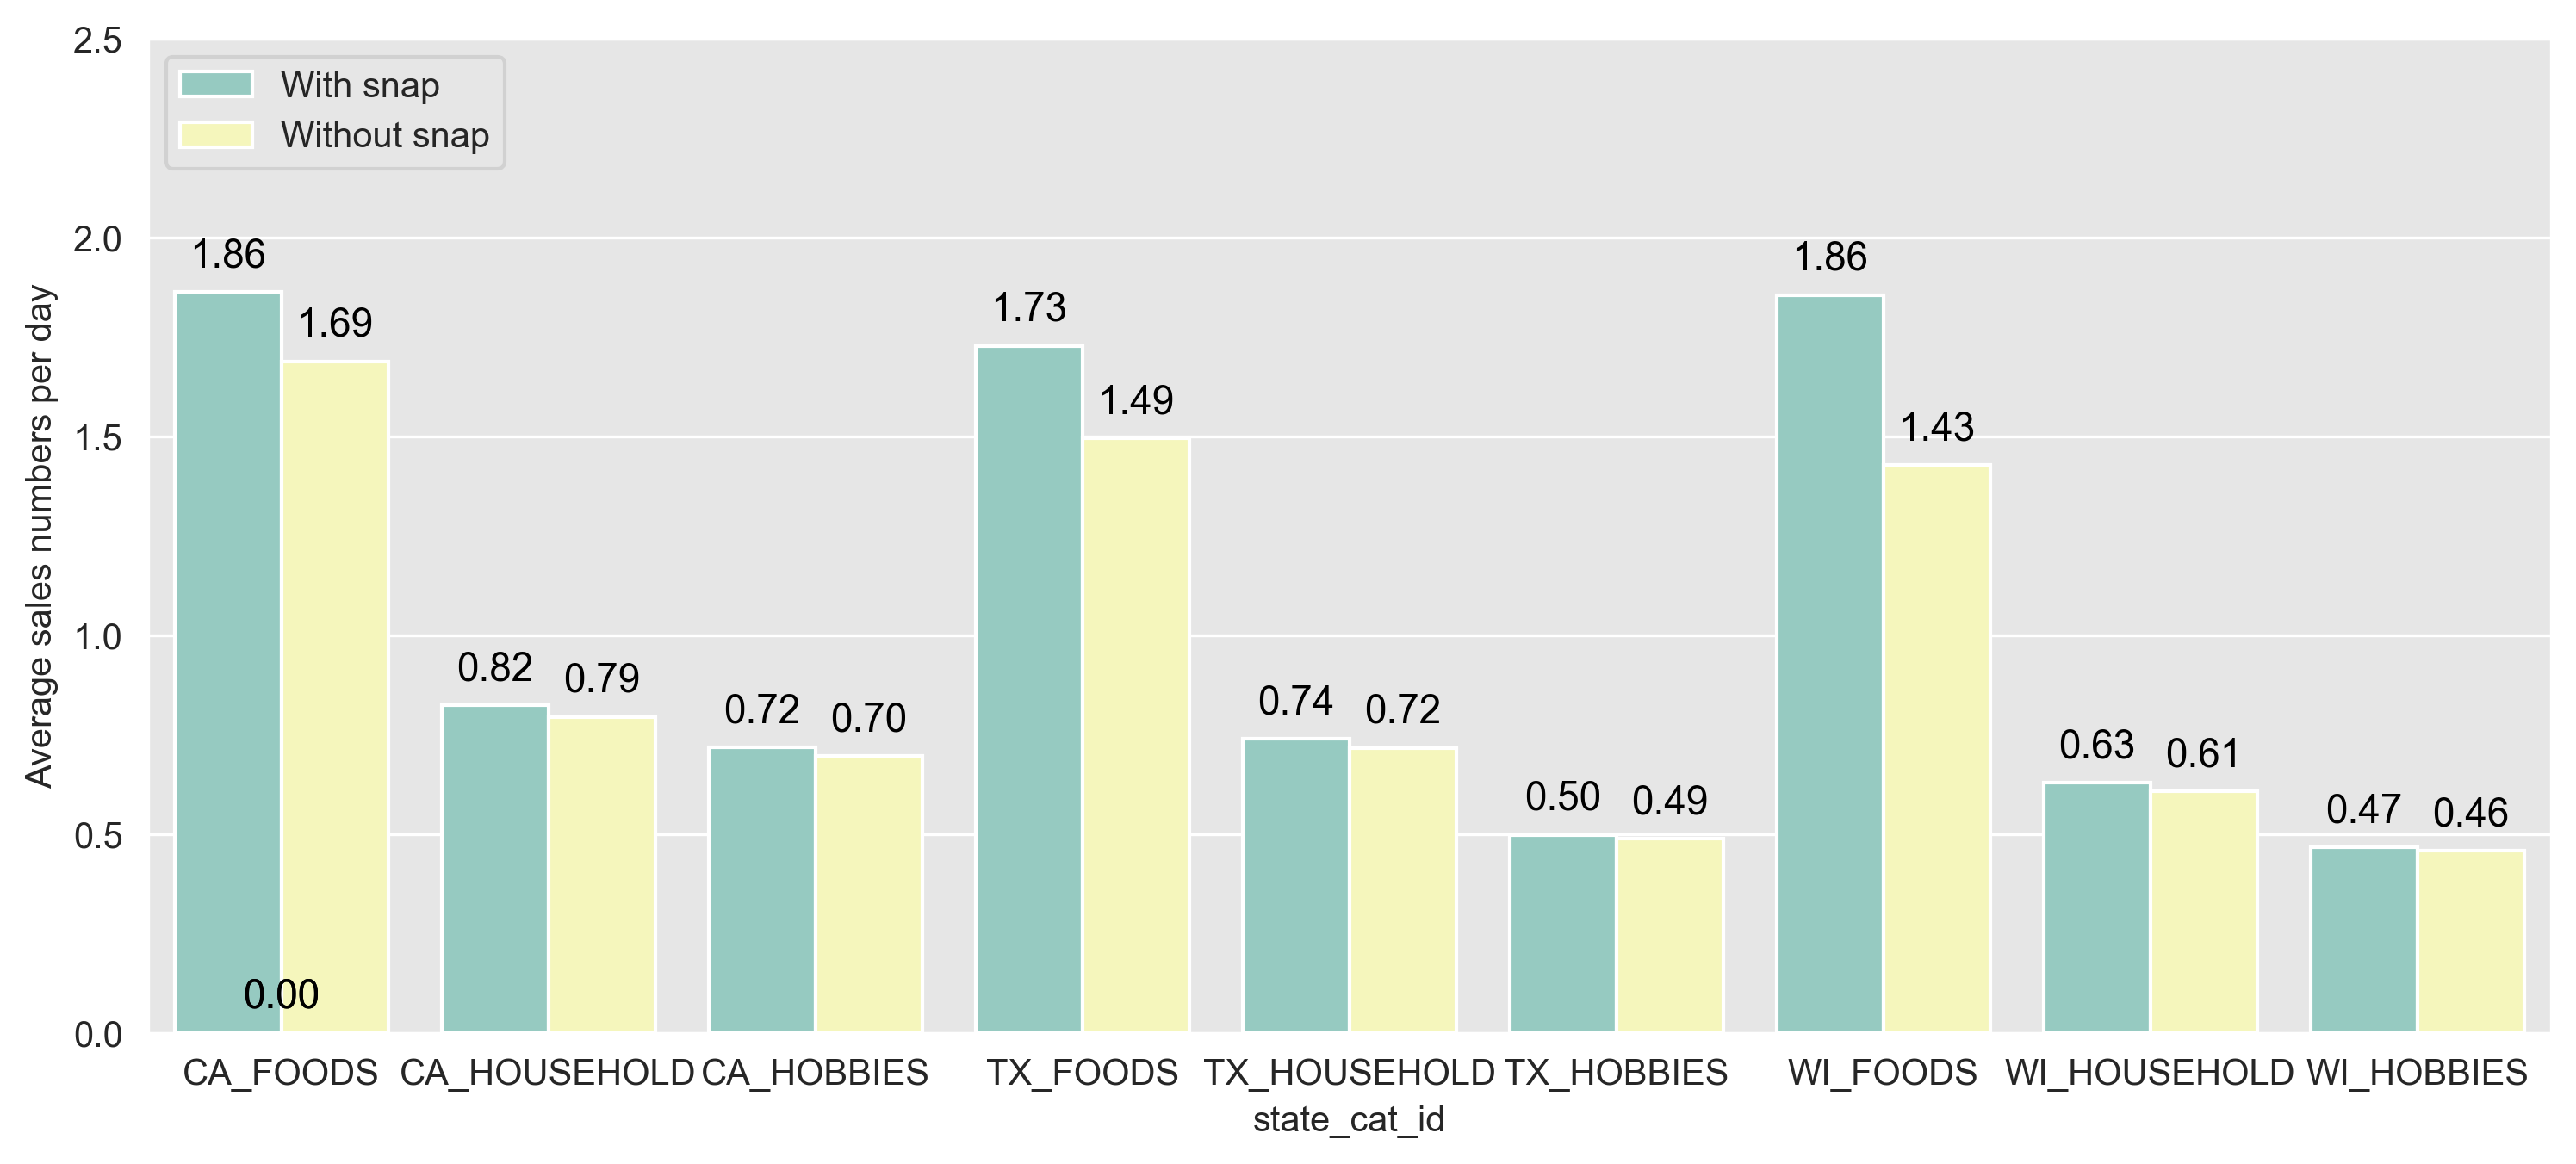

In [48]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(x="state_cat_id", hue="snap", y="mean", data=snap_df)
ax.set_ylabel("Average sales numbers per day")
for p in ax.patches:
    ax.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
         ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
         textcoords='offset points')
_ = ax.set_ylim(0,2.5)
plt.legend(loc='upper left')
plt.show()
plt.close()

Observing the plot above, we can know that snap only has significant impact on FOODS sales.

#### Store vs snap

In [49]:
stores = sells_train['store_id'].value_counts()
stores

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

In [50]:
stores_id = stores.index.tolist()
stores_id.sort()

days_list = []
mean_with_snap = []
mean_without_snap = []
for i in range(len(stores_id)):
    state = stores_id[i][:2]
    days_list.append(day_extraction(calendar, snap = True, state = state ))
    days_list.append(day_extraction(calendar, snap = False, state = state))
    mean_with_snap.append(sells_train[(sells_train['store_id'] == stores_id[i])].loc[:, days_list[2*i]].mean().mean())
    mean_without_snap.append(sells_train[(sells_train['store_id'] == stores_id[i])].loc[:, days_list[2*i+1]].mean().mean())
# print(mean_with_snap)
# print(mean_without_snap)

stores_df = pd.DataFrame({'Store_id':stores_id*2, 'Mean':mean_with_snap + mean_without_snap, 'snap':['With snap']*10 + ['Without snap']*10})

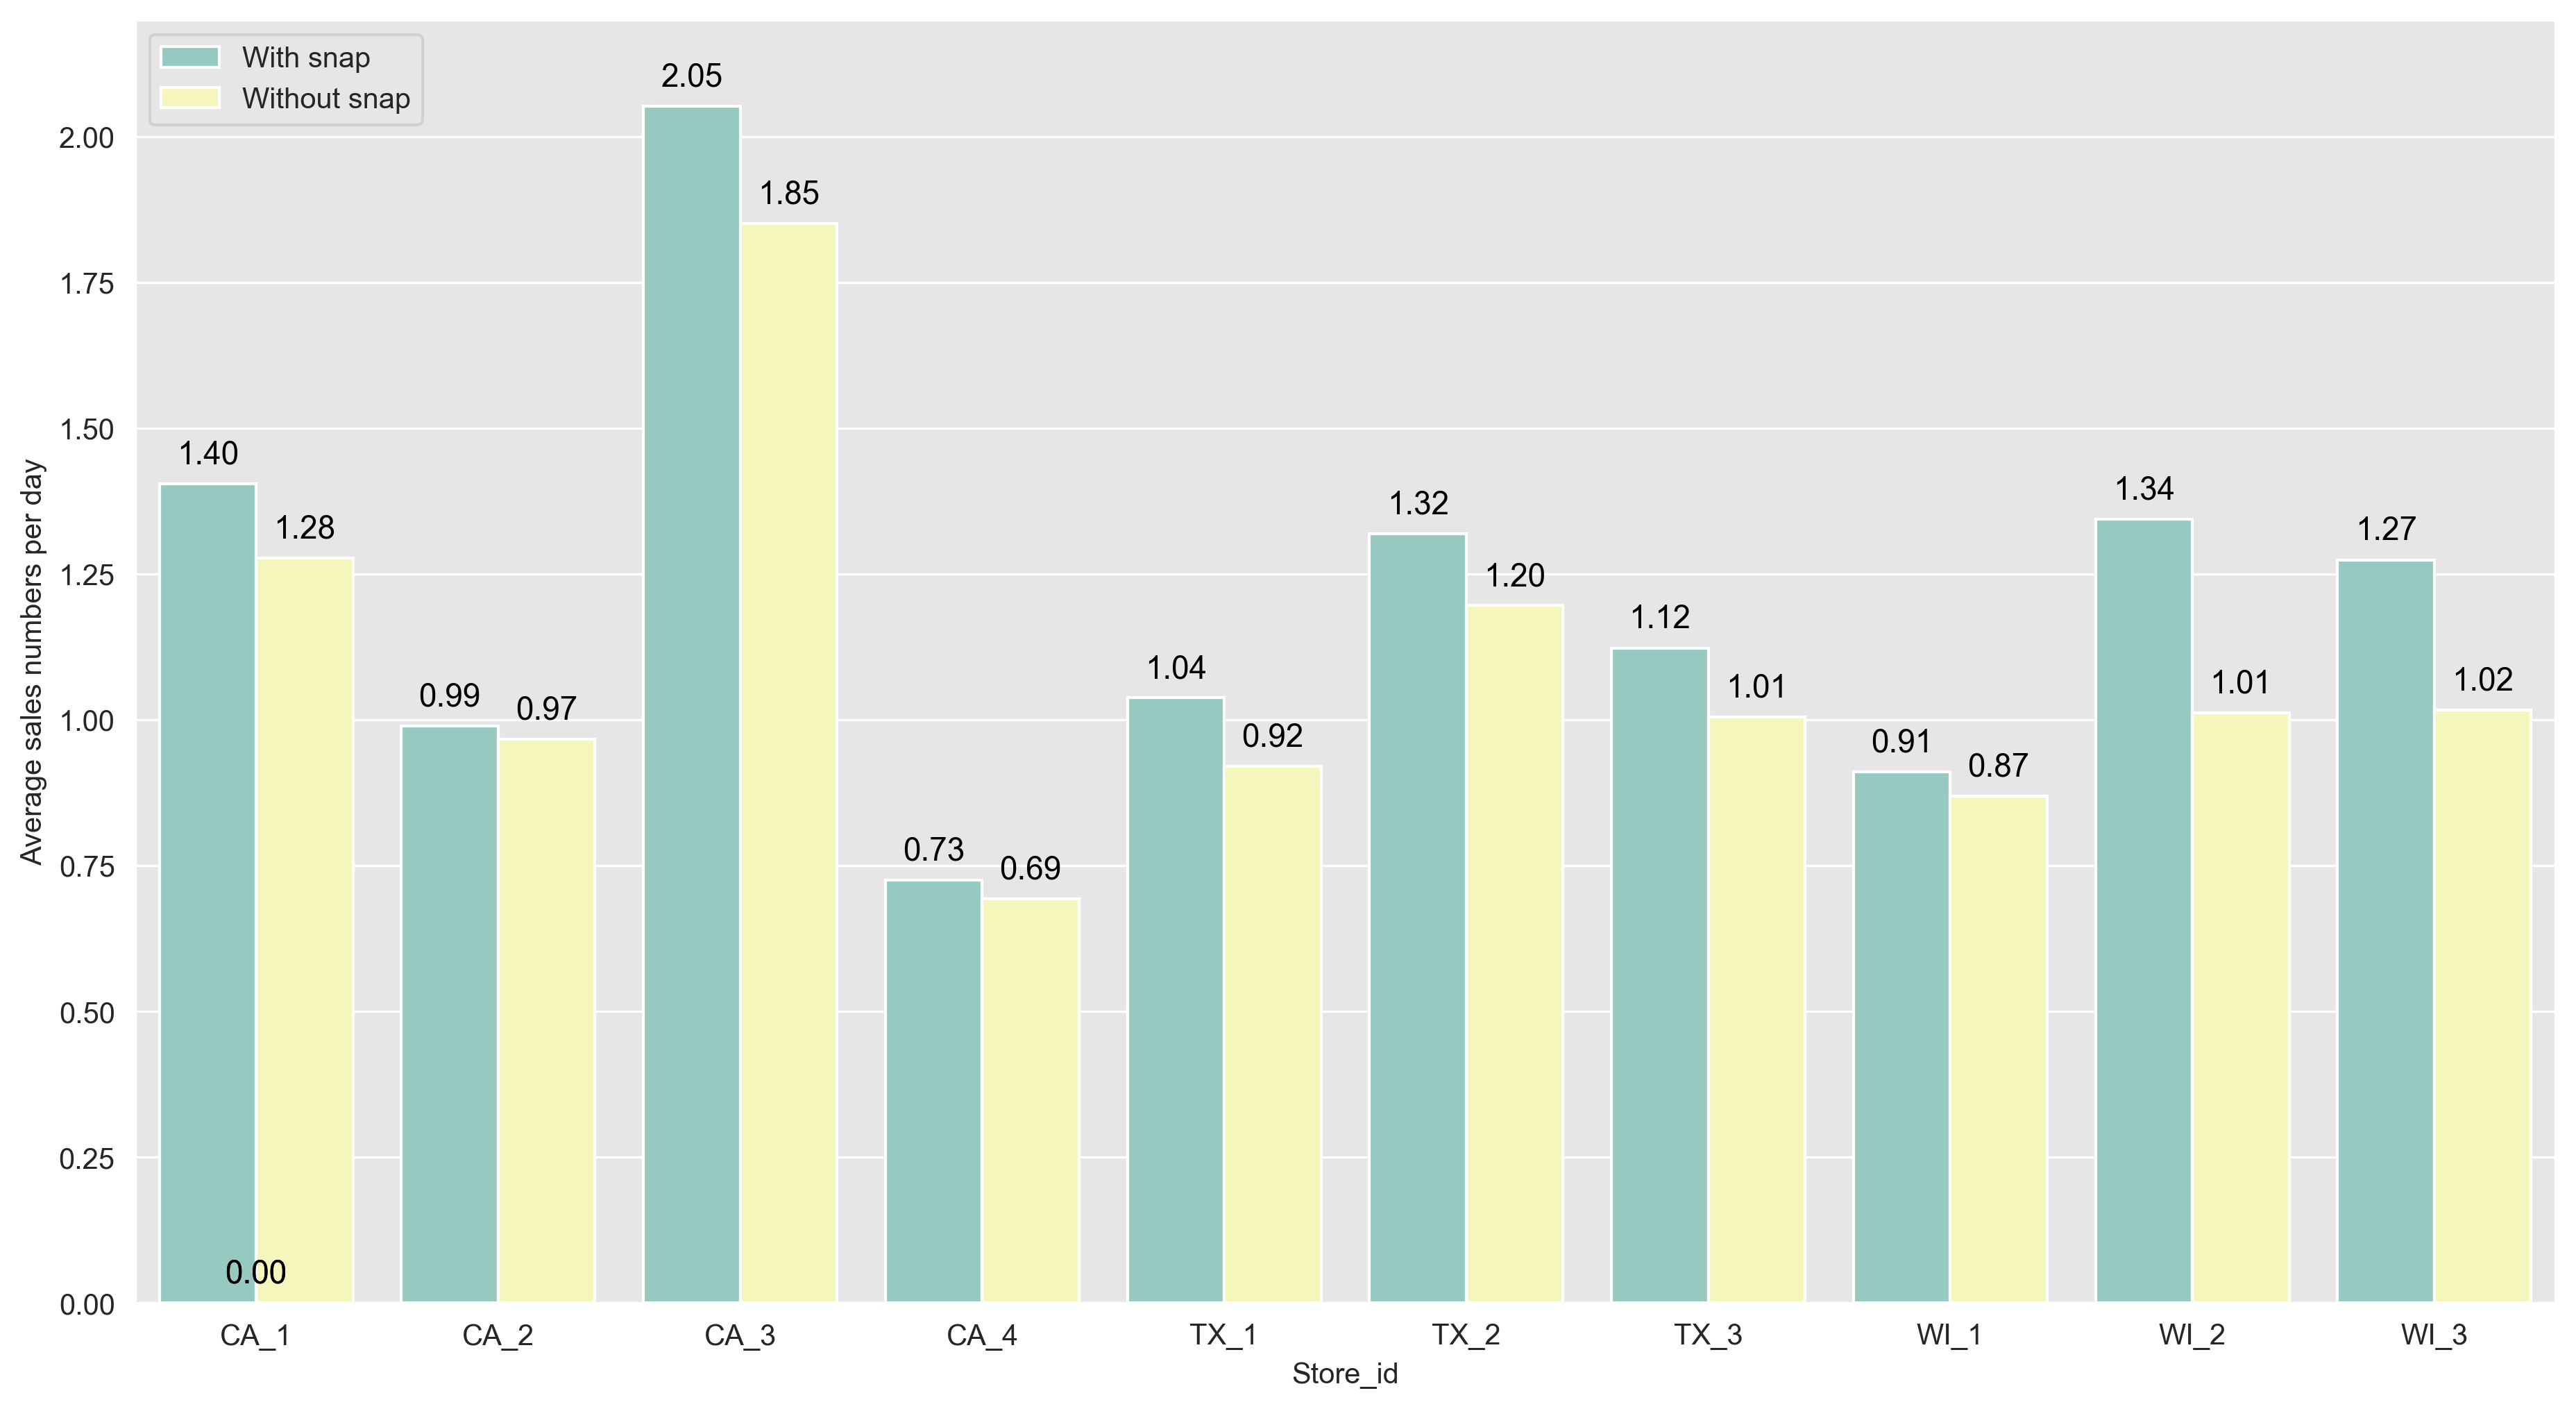

In [51]:
plt.figure(figsize=(15, 8))
ax = sns.barplot(x="Store_id", hue="snap", y="Mean", data=stores_df)
ax.set_ylabel("Average sales numbers per day")
for p in ax.patches:
    ax.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
         ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
         textcoords='offset points')
_ = ax.set_ylim(0,2.2)
plt.legend(loc='upper left')
plt.show()
plt.close()

The figure shows average daily sales by store, comparing periods with and without SNAP participation. Across nearly all stores, sales are consistently higher during SNAP-eligible periods, although the magnitude of the effect varies across locations. This indicates that SNAP-related demand impacts are not uniform and exhibit store-level heterogeneity.

These patterns suggest that SNAP indicators may capture localized demand dynamics and could improve model performance when incorporated as exogenous features at the item–store level.


In [52]:
stores_compare_df = pd.DataFrame({'Store_id':stores_id, 'Mean_with_snap' : mean_with_snap, 'Mean_without_snap':mean_without_snap})
stores_compare_df['Growth with snap(%)'] =(stores_compare_df['Mean_with_snap']/stores_compare_df['Mean_without_snap']-1)*100
stores_compare_df

,Store_id,Mean_with_snap,Mean_without_snap,Growth with snap(%)
0,CA_1,1.404695,1.278157,9.900020
1,CA_2,0.989801,0.967363,2.319564
2,CA_3,2.053171,1.851879,10.869611
3,CA_4,0.725139,0.692963,4.643196
4,TX_1,1.037879,0.920702,12.726939
5,TX_2,1.319730,1.196195,10.327314
6,TX_3,1.123118,1.005138,11.737714
7,WI_1,0.911159,0.868855,4.868974
8,WI_2,1.344542,1.012642,32.775676
9,WI_3,1.274498,1.017324,25.279434


From the above, it is known that most stores are affected by snap. The impact varies across stores, with some experiencing a more significant impact than others.



#### **Conclusion**

Regardless of the aspects, whether by state, product category, or store, we observe a correlation between the presence or absence of snap and sales volume. Therefore, snap appears to be valuable information. When making predictions, incorporating snap as a feature is recommended to enhance the accuracy of the model.

### Load data

In [53]:
sell_prices = pd.read_csv("data/sell_prices.csv")
print(sell_prices.shape)
sell_prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [54]:
sell_prices['wm_yr_wk'].unique()

array([11325, 11326, 11327, 11328, 11329, 11330, 11331, 11332, 11333,
       11334, 11335, 11336, 11337, 11338, 11339, 11340, 11341, 11342,
       11343, 11344, 11345, 11346, 11347, 11348, 11349, 11350, 11351,
       11352, 11353, 11401, 11402, 11403, 11404, 11405, 11406, 11407,
       11408, 11409, 11410, 11411, 11412, 11413, 11414, 11415, 11416,
       11417, 11418, 11419, 11420, 11421, 11422, 11423, 11424, 11425,
       11426, 11427, 11428, 11429, 11430, 11431, 11432, 11433, 11434,
       11435, 11436, 11437, 11438, 11439, 11440, 11441, 11442, 11443,
       11444, 11445, 11446, 11447, 11448, 11449, 11450, 11451, 11452,
       11501, 11502, 11503, 11504, 11505, 11506, 11507, 11508, 11509,
       11510, 11511, 11512, 11513, 11514, 11515, 11516, 11517, 11518,
       11519, 11520, 11521, 11522, 11523, 11524, 11525, 11526, 11527,
       11528, 11529, 11530, 11531, 11532, 11533, 11534, 11535, 11536,
       11537, 11538, 11539, 11540, 11541, 11542, 11543, 11544, 11545,
       11546, 11547,

In [55]:
sell_prices.set_index(['store_id', 'item_id', 'wm_yr_wk'], inplace=True)
sell_prices.head()

sell_price
store_id item_id       wm_yr_wk            
CA_1     HOBBIES_1_001 11325           9.58
                       11326           9.58
                       11327           8.26
                       11328           8.26
                       11329           8.26

In [56]:
sell_prices.index

MultiIndex([('CA_1', 'HOBBIES_1_001', 11325),
            ('CA_1', 'HOBBIES_1_001', 11326),
            ('CA_1', 'HOBBIES_1_001', 11327),
            ('CA_1', 'HOBBIES_1_001', 11328),
            ('CA_1', 'HOBBIES_1_001', 11329),
            ('CA_1', 'HOBBIES_1_001', 11330),
            ('CA_1', 'HOBBIES_1_001', 11331),
            ('CA_1', 'HOBBIES_1_001', 11332),
            ('CA_1', 'HOBBIES_1_001', 11333),
            ('CA_1', 'HOBBIES_1_001', 11334),
            ...
            ('WI_3',   'FOODS_3_827', 11612),
            ('WI_3',   'FOODS_3_827', 11613),
            ('WI_3',   'FOODS_3_827', 11614),
            ('WI_3',   'FOODS_3_827', 11615),
            ('WI_3',   'FOODS_3_827', 11616),
            ('WI_3',   'FOODS_3_827', 11617),
            ('WI_3',   'FOODS_3_827', 11618),
            ('WI_3',   'FOODS_3_827', 11619),
            ('WI_3',   'FOODS_3_827', 11620),
            ('WI_3',   'FOODS_3_827', 11621)],
           names=['store_id', 'item_id', 'wm_yr_wk'], length=68

### Build training dataframe

We expanded each product to have 1913 rows. This way, we could have historical sales data into daily sales columns, and integrate it with the calendar data.

In [57]:
id_order = sells_train['id'].tolist()
id_order[:10]

['HOBBIES_1_001_CA_1_validation',
 'HOBBIES_1_002_CA_1_validation',
 'HOBBIES_1_003_CA_1_validation',
 'HOBBIES_1_004_CA_1_validation',
 'HOBBIES_1_005_CA_1_validation',
 'HOBBIES_1_006_CA_1_validation',
 'HOBBIES_1_007_CA_1_validation',
 'HOBBIES_1_008_CA_1_validation',
 'HOBBIES_1_009_CA_1_validation',
 'HOBBIES_1_010_CA_1_validation']

In [58]:
day_num = 1913
basic_data = sells_train.iloc[:, :6].copy()
duplicate = [basic_data]*day_num
basic_data = pd.concat(duplicate)
basic_data['id'] = basic_data['id'].astype('category')
basic_data['id'] = basic_data['id'].cat.set_categories(id_order)
basic_data = basic_data.sort_values(by = ['id']).reset_index(drop = True)
basic_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA


In [59]:
day_name = sells_train.columns[6:].tolist()
day_name[:10]

['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10']

In [60]:
sample_num = len(sells_train)
basic_data['d'] = day_name*sample_num
basic_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5


In [61]:
sell_amt = np.reshape(sells_train.iloc[:, 6:].values, (day_num*sample_num, 1))
basic_data['num_sold'] = sell_amt
basic_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,num_sold
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0


In [62]:
basic_data.shape

(58327370, 8)

In [63]:
cal_df = pd.concat([calendar.iloc[:1913]]*sample_num).reset_index(drop=True)
cal_df

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58327365,2016-04-20,11612,Wednesday,5,4,2016,d_1909,NaN,NaN,NaN,NaN,0,0,0
58327366,2016-04-21,11612,Thursday,6,4,2016,d_1910,NaN,NaN,NaN,NaN,0,0,0
58327367,2016-04-22,11612,Friday,7,4,2016,d_1911,NaN,NaN,NaN,NaN,0,0,0
58327368,2016-04-23,11613,Saturday,1,4,2016,d_1912,NaN,NaN,NaN,NaN,0,0,0


In [64]:
cal_df.drop(['wday','d'], axis=1, inplace = True)

In [65]:
cal_df.shape

(58327370, 12)

In [66]:
train_data = pd.concat([basic_data, cal_df], axis=1)
train_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,num_sold,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,2011-01-31,11101,Monday,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,2011-02-01,11101,Tuesday,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,2011-02-02,11101,Wednesday,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [67]:
train_data.shape

(58327370, 20)

In [68]:
import gc
gc.collect()

0

### Snap and state

Convert the "snap" column into a single dummy variable column based on the "state".

In [69]:
state2snap = lambda x: x['snap_CA'] if x['state_id'] == 'CA' else(x['snap_TX'] if x['state_id']=='TX' else x['snap_WI'])

In [70]:
snap = train_data[['snap_CA', 'snap_TX', 'snap_WI', 'state_id']].apply(state2snap, axis=1)
snap

0           0
1           0
2           0
3           1
4           1
           ..
58327365    0
58327366    0
58327367    0
58327368    0
58327369    0
Length: 58327370, dtype: int64

In [71]:
train_data.drop(['snap_CA', 'snap_TX', 'snap_WI'], inplace = True, axis=1)

In [72]:
train_data['snap'] = snap

In [73]:
train_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,num_sold,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN,NaN,NaN,0
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,1,2011,NaN,NaN,NaN,NaN,0
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,2011-01-31,11101,Monday,1,2011,NaN,NaN,NaN,NaN,0
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,2011-02-01,11101,Tuesday,2,2011,NaN,NaN,NaN,NaN,1
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,2011-02-02,11101,Wednesday,2,2011,NaN,NaN,NaN,NaN,1


In [74]:
#train_data.to_csv('train.csv',index=False)

### Merge

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from tqdm._tqdm_notebook import tqdm_notebook
tqdm_notebook.pandas()
#.progress_apply()

C:\Users\herna\AppData\Local\Temp\ipykernel_27584\3605313959.py:1: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.*` instead of `tqdm._tqdm_notebook.*`
  from tqdm._tqdm_notebook import tqdm_notebook


In [4]:
train_data = pd.read_csv("train.csv")

C:\Users\herna\AppData\Local\Temp\ipykernel_27584\2026531262.py:1: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv("train.csv")


In [5]:
train_data.shape

(58327370, 18)

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 18 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   id            object
 1   item_id       object
 2   dept_id       object
 3   cat_id        object
 4   store_id      object
 5   state_id      object
 6   d             object
 7   num_sold      int64 
 8   date          object
 9   wm_yr_wk      int64 
 10  weekday       object
 11  month         int64 
 12  year          int64 
 13  event_name_1  object
 14  event_type_1  object
 15  event_name_2  object
 16  event_type_2  object
 17  snap          int64 
dtypes: int64(5), object(13)
memory usage: 7.8+ GB


In [8]:
sell_prices = pd.read_csv("data/sell_prices.csv")

In [9]:
print(sell_prices.shape)
sell_prices.head(10)

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


In [87]:
#train_data_withprice=train_data.merge(sell_prices,"left")

In [10]:
# CHUNK-WISE PRICE MERGE
#In the M5 dataset, the sales table contains tens of millions of rows, and performing a single global merge with the price table can cause excessive RAM usage or crash the kernel. By splitting the merge by store_id, each join operation is performed on a much smaller subset of the data.

# Downcast identifier columns to categorical type to reduce memory usage
# This is critical when working with large M5 tables
for c in ['store_id', 'item_id']:
    train_data[c] = train_data[c].astype('category')
    sell_prices[c] = sell_prices[c].astype('category')

# Downcast price to float32 to further reduce RAM consumption
sell_prices['sell_price'] = sell_prices['sell_price'].astype('float32')

# Ensure that the weekly key (wm_yr_wk) exists in the training data
# Prices are indexed by week, so this variable is required for a correct merge
if 'wm_yr_wk' not in train_data.columns:
    train_data = train_data.merge(
        calendar[['d', 'wm_yr_wk']],
        on='d',
        how='left'
    )

# Keep only the necessary columns from the price table
# This avoids carrying unused data through the merge
sell_prices_small = sell_prices[
    ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']
]

merged_parts = []

# Perform the merge store by store instead of all at once
# This chunk-wise approach prevents memory spikes during the join
for store in train_data['store_id'].cat.categories:
    print(f"Merging store: {store}")

    # Subset training data for a single store
    td_part = train_data[train_data['store_id'] == store]

    # Subset price data for the same store
    sp_part = sell_prices_small[sell_prices_small['store_id'] == store]

    # Merge sales with prices using store, item, and week identifiers
    merged_part = td_part.merge(
        sp_part,
        on=['store_id', 'item_id', 'wm_yr_wk'],
        how='left'
    )

    merged_parts.append(merged_part)

# Concatenate all store-level merged chunks back into one DataFrame
train_data_withprice = pd.concat(merged_parts, ignore_index=True)

# Sanity checks:
# 1) Verify the final dataset size
# 2) Check the proportion of missing prices after the merge
print("Final shape:", train_data_withprice.shape)
print("Missing price ratio:", train_data_withprice['sell_price'].isna().mean())


Merging store: CA_1
Merging store: CA_2
Merging store: CA_3
Merging store: CA_4
Merging store: TX_1
Merging store: TX_2
Merging store: TX_3
Merging store: WI_1
Merging store: WI_2
Merging store: WI_3
Final shape: (58327370, 19)
Missing price ratio: 0.2108686367994991


In [12]:
train_data_withprice.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,num_sold,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN,NaN,NaN,0,NaN
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,1,2011,NaN,NaN,NaN,NaN,0,NaN
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,2011-01-31,11101,Monday,1,2011,NaN,NaN,NaN,NaN,0,NaN
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,2011-02-01,11101,Tuesday,2,2011,NaN,NaN,NaN,NaN,1,NaN
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,2011-02-02,11101,Wednesday,2,2011,NaN,NaN,NaN,NaN,1,NaN


In [13]:
train_data_withprice.to_csv('train_with_price_notfill.csv',index=False)


## Fill na values for "price"

In [4]:
dataset_full = pd.read_csv(
    "train_with_price_notfill.csv",
    usecols=["date", "item_id", "store_id", "state_id", "cat_id", "num_sold", "sell_price"],
    dtype={
        "num_sold": "float32",
        "sell_price": "float32"
    },
    parse_dates=["date"]
)

In [5]:
# 2. Lọc đúng phạm vi FOODS tại California (CA)
dataset = dataset_full[
    (dataset_full['state_id'] == 'CA') &
    (dataset_full['cat_id'] == 'FOODS')
].copy()

In [7]:
full_price=dataset['sell_price'].fillna(method='bfill')

C:\Users\herna\AppData\Local\Temp\ipykernel_37084\1843739649.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_price=dataset['sell_price'].fillna(method='bfill')


In [8]:
dataset['sell_price']=full_price

In [9]:
dataset.head(10)

,item_id,cat_id,store_id,state_id,num_sold,date,sell_price
3083756,FOODS_1_001,FOODS,CA_1,CA,3.0,2011-01-29,2.0
3083757,FOODS_1_001,FOODS,CA_1,CA,0.0,2011-01-30,2.0
3083758,FOODS_1_001,FOODS,CA_1,CA,0.0,2011-01-31,2.0
3083759,FOODS_1_001,FOODS,CA_1,CA,1.0,2011-02-01,2.0
3083760,FOODS_1_001,FOODS,CA_1,CA,4.0,2011-02-02,2.0
3083761,FOODS_1_001,FOODS,CA_1,CA,2.0,2011-02-03,2.0
3083762,FOODS_1_001,FOODS,CA_1,CA,0.0,2011-02-04,2.0
3083763,FOODS_1_001,FOODS,CA_1,CA,2.0,2011-02-05,2.0
3083764,FOODS_1_001,FOODS,CA_1,CA,0.0,2011-02-06,2.0
3083765,FOODS_1_001,FOODS,CA_1,CA,0.0,2011-02-07,2.0


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10995924 entries, 3083756 to 23330947
Data columns (total 7 columns):
 #   Column      Dtype         
---  ------      -----         
 0   item_id     object        
 1   cat_id      object        
 2   store_id    object        
 3   state_id    object        
 4   num_sold    float32       
 5   date        datetime64[ns]
 6   sell_price  float32       
dtypes: datetime64[ns](1), float32(2), object(4)
memory usage: 587.2+ MB


### The main DataFrame is complete and can now be used in the models.




# Forecasting Strategies

To address the complexity and heterogeneity of retail demand, this study adopts two forecasting strategies that operate at different levels of aggregation. The purpose of introducing multiple strategies is not to identify a single best model, but to explore alternative ways of structuring the forecasting problem under stochastic demand.

**Aggregate Demand Forecasting**

The first strategy focuses on forecasting demand at an aggregated level by summing sales across all items and stores into a single time series. This approach emphasizes system-wide demand dynamics and is designed to capture broad temporal patterns such as overall trends and seasonality. By construction, aggregation smooths local fluctuations and reduces the impact of item-specific noise, providing a consolidated view of demand evolution over time.

This strategy represents a top-down perspective on forecasting, in which demand is modeled at a high level of abstraction without explicitly distinguishing between individual products or locations.

**Item–Store-Level Forecasting with Global Models**

The second strategy operates at a disaggregated level, producing forecasts for individual item–store combinations. Rather than fitting separate models to each time series, global forecasting models are trained across multiple items and stores simultaneously. This approach allows common demand patterns to be learned across series while preserving heterogeneity at the local level.

By working directly with granular demand data, this strategy adopts a bottom-up perspective and enables detailed analysis of demand variability across products and locations. It reflects a modeling choice in which cross-sectional information is explicitly leveraged to support forecasting in large-scale retail settings.

**Scope of the Strategies**

The two strategies differ primarily in how demand is represented and structured prior to modeling. One emphasizes aggregation and system-level dynamics, while the other focuses on granularity and cross-sectional learning. No assumptions are made at this stage regarding the relative performance or suitability of either approach for specific operational decisions.


## Item–Store-Level Forecasting with Global Models

0. CONFIG

In [1]:
HORIZON = 2
STEP = 2
N_SPLITS = 3  # FINAL

TARGET_STORE = "CA_1"
MIN_WEEKS = 60  # Minimum weeks per series for inclusion in evaluation

1. DATA LOADING + WEEKLY AGGREGATION + EQUAL UNIVERSE FILTER

In [2]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder


def load_and_preprocess(path, store_id=TARGET_STORE):
    """
    Load M5 data, filter to FOODS / CA / target store, impute missing prices.
    Uses bfill + ffill for sell_price (consistent with thesis Section 3.3.2).
    """
    chunks = []

    for chunk in pd.read_csv(
            path,
            parse_dates=["date"],
            chunksize=1_000_000
    ):
        filtered = chunk[
            (chunk["cat_id"] == "FOODS") &
            (chunk["state_id"] == "CA") &
            (chunk["store_id"] == store_id)
            ].copy()

        chunks.append(filtered)

    df = pd.concat(chunks, ignore_index=True)
    df = df.sort_values(["item_id", "store_id", "date"])

    # Backward + forward fill for sell_price (NOT fillna(0))
    df["sell_price"] = (
        df.groupby(["item_id", "store_id"])["sell_price"]
        .transform(lambda x: x.bfill().ffill())
    )
    df["sell_price"] = df["sell_price"].fillna(0).astype("float32")  # last resort
    df["num_sold"] = df["num_sold"].fillna(0).astype("int16")

    # Keep last 730 days (~2 years)
    df["d_num"] = df["d"].str.replace("d_", "").astype(int)
    df = df[df["d_num"] >= df["d_num"].max() - 730].copy()

    return df

In [3]:
def convert_to_weekly(df):
    """Aggregate daily to weekly (Monday start). Sum num_sold, mean sell_price."""
    df["week"] = df["date"].dt.to_period("W").apply(lambda r: r.start_time)

    weekly = df.groupby(
        ["item_id", "store_id", "week"],
        observed=True
    ).agg({
        "num_sold": "sum",
        "sell_price": "mean"
    }).reset_index()

    weekly = weekly.sort_values(["item_id", "store_id", "week"])
    weekly["w_num"] = weekly.groupby(["item_id", "store_id"]).cumcount()

    return weekly


def filter_valid_series(df, min_weeks=MIN_WEEKS):
    """
    Filter SKU-store series to ensure equal evaluation universe across all models.
    All forecasting models train and evaluate on the same SKU subset.
    """
    counts = df.groupby(["item_id", "store_id"]).size()
    valid_keys = counts[counts >= min_weeks].index

    df_valid = df.set_index(["item_id", "store_id"])
    df_valid = df_valid[df_valid.index.isin(valid_keys)].reset_index()

    n_total = len(counts)
    n_valid = len(valid_keys)
    n_excluded = n_total - n_valid

    print(f"Total SKU-store series: {n_total}")
    print(f"Valid series (>= {min_weeks} weeks): {n_valid}")
    print(f"Excluded series (< {min_weeks} weeks): {n_excluded}")

    return df_valid


# Run pipeline
df_daily = load_and_preprocess("train_with_price_notfill.csv")
df = convert_to_weekly(df_daily)
df = filter_valid_series(df, min_weeks=MIN_WEEKS)

print(f"\nFinal shape: {df.shape}")
print(f"Unique series: {df.groupby(['item_id', 'store_id']).ngroups}")

Total SKU-store series: 1437
Valid series (>= 60 weeks): 1437
Excluded series (< 60 weeks): 0

Final shape: (150885, 6)
Unique series: 1437


In [5]:
def filter_valid_series(df, min_weeks=60):
    """
    Filter series to ensure equal evaluation universe across all models.
    All forecasting models will train and evaluate on the same SKU subset.
    """
    counts = df.groupby(["item_id", "store_id"]).size()
    valid_keys = counts[counts >= min_weeks].index

    # Filter
    df_valid = df.set_index(["item_id", "store_id"])
    df_valid = df_valid[df_valid.index.isin(valid_keys)].reset_index()

    n_excluded = len(counts) - len(valid_keys)
    print(f"Series with < {min_weeks} weeks: {n_excluded} excluded")
    print(f"Valid series for evaluation: {len(valid_keys)}")

    return df_valid


# Apply RIGHT AFTER weekly conversion:
df_daily = load_and_preprocess("train_with_price_notfill.csv")
df = convert_to_weekly(df_daily)
df = filter_valid_series(df, min_weeks=60)  # ✅ NEW

print("Final shape:", df.shape)

Series with < 60 weeks: 0 excluded
Valid series for evaluation: 1437
Final shape: (150885, 6)


2. WRMSSE COMPONENTS

In [4]:
def compute_wrmsse_components(df_train):
    """
    Compute scale (denominator of RMSSE) and revenue weights using TRAINING data only.

    Args:
        df_train: training data only (no test leak)
    """
    scale_dict = {}
    revenue_dict = {}

    for key, g in df_train.groupby(["item_id", "store_id"], observed=True):
        y = g.sort_values("w_num")["num_sold"].values

        if len(y) <= HORIZON:
            continue

        # Scale = MSE of horizon-step naive forecast
        diff = y[HORIZON:] - y[:-HORIZON]
        scale = np.mean(diff ** 2)
        scale_dict[key] = max(scale, 1e-8)

        # Revenue weight from training period
        revenue_dict[key] = np.sum(y * g["sell_price"].values)

    total = np.sum(list(revenue_dict.values()))
    weights_dict = {k: v / total for k, v in revenue_dict.items()} if total > 0 else {}

    return scale_dict, weights_dict


def calculate_wrmsse(pred_df, scale_dict, weights_dict):
    """
    Compute WRMSSE using ALL horizon steps (not just final horizon).

    RMSSE per series = sqrt( mean(squared_errors_across_horizons) / scale )
    WRMSSE = sum( weight_i * RMSSE_i )
    """
    pred_df = pred_df.sort_values(["item_id", "store_id", "w_num"]).copy()

    # Squared error per row
    pred_df["sq_error"] = (pred_df["num_sold"] - pred_df["preds"]) ** 2

    # Mean squared error per series (averaging across all horizon steps)
    mse_per_series = (
        pred_df.groupby(["item_id", "store_id"])["sq_error"]
        .mean()
    )

    # Build aligned scale and weight series
    series_keys = mse_per_series.index
    scales = pd.Series(
        [scale_dict.get(k, np.nan) for k in series_keys],
        index=series_keys
    )
    weights = pd.Series(
        [weights_dict.get(k, np.nan) for k in series_keys],
        index=series_keys
    )

    # Drop series không có scale/weight
    valid = scales.notna() & weights.notna() & (scales > 0)
    mse_valid = mse_per_series[valid]
    scales_valid = scales[valid]
    weights_valid = weights[valid]

    # RMSSE per series
    rmsse = np.sqrt(mse_valid / scales_valid)

    # WRMSSE = weighted sum
    wrmsse = (rmsse * weights_valid).sum()

    return wrmsse


# ⚠️ IMPORTANT: Move scale/weights computation INSIDE the rolling loop,
# computed per split using only train data (see Step 4 below)

3. FEATURE ENGINEERING (GLOBAL)WRMSSE Function (Unified)


In [6]:
def create_features(df, encoders=None, fit=False):
    """
    Build feature set for global ML models.
    Features: 5 lags + rolling_4 + month + 2 categorical IDs = 9 total.
    """
    df = df.sort_values(["item_id", "store_id", "w_num"]).copy()

    g = df.groupby(["item_id", "store_id"])["num_sold"]

    df["lag_1"] = g.shift(1)
    df["lag_2"] = g.shift(2)
    df["lag_4"] = g.shift(4)
    df["lag_7"] = g.shift(7)
    df["lag_52"] = g.shift(52)
    df["rolling_4"] = g.shift(1).rolling(4).mean()
    df["month"] = df["week"].dt.month

    # Drop NA based on feature columns only
    feature_cols = [
        "lag_1", "lag_2", "lag_4", "lag_7", "lag_52", "rolling_4"
    ]
    df = df.dropna(subset=feature_cols)

    if fit:
        item_le = LabelEncoder()
        store_le = LabelEncoder()
        df["item_id_idx"] = item_le.fit_transform(df["item_id"])
        df["store_id_idx"] = store_le.fit_transform(df["store_id"])
        encoders = {"item": item_le, "store": store_le}
    else:
        df["item_id_idx"] = encoders["item"].transform(df["item_id"])
        df["store_id_idx"] = encoders["store"].transform(df["store_id"])

    return (df, encoders) if fit else df

4. ROLLING-ORIGIN SPLITS

In [7]:
def generate_splits(df):
    """
    Generate N_SPLITS expanding-window rolling-origin splits.
    Each split has horizon = HORIZON weeks, step = STEP weeks.
    """
    max_w = df["w_num"].max()
    splits = []

    for i in range(N_SPLITS):
        test_end = max_w - i * STEP
        test_start = test_end - HORIZON

        train = df[df["w_num"] <= test_start]
        test = df[(df["w_num"] > test_start) & (df["w_num"] <= test_end)]

        splits.append((train, test))

    # Reverse: earliest split first (chronological order)
    return splits[::-1]

ML MODEL TRAIN + PREDICT (UNIFIED)

In [8]:
def train_ml(model_type, train):
    """Train Random Forest or LightGBM as global model on full SKU portfolio."""
    train_feat, encoders = create_features(train, fit=True)

    if len(train_feat) == 0:
        raise ValueError("No training data after feature engineering")

    features = [
        "item_id_idx", "store_id_idx", "month",
        "lag_1", "lag_2", "lag_4", "lag_7", "lag_52", "rolling_4"
    ]

    if model_type == "rf":
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(
            n_estimators=150,
            max_depth=14,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )
    else:
        import lightgbm as lgb
        model = lgb.LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        )

    model.fit(train_feat[features], train_feat["num_sold"])

    return model, encoders, features


def direct_forecast(model, train, test, encoders, features):
    """
    True direct forecast: features for test rows are computed using ONLY
    training data. Test-window actuals do NOT enter lag features.

    This ensures fair comparison with SARIMA, which forecasts h=1 and h=2
    purely from training data without access to test-window actuals.
    """
    # Mask test num_sold so it cannot leak into lag features
    test_masked = test.copy()
    test_masked["num_sold"] = np.nan

    df_input = pd.concat([train, test_masked]).sort_values(
        ["item_id", "store_id", "w_num"]
    )

    # Forward-fill num_sold within group from train side
    # → lag features for test rows look back to train values, not to test NaN
    df_input["num_sold_filled"] = (
        df_input.groupby(["item_id", "store_id"])["num_sold"]
        .ffill()
    )

    # Save original num_sold (with NaN for test) and use filled for features
    df_input["num_sold_orig"] = df_input["num_sold"]
    df_input["num_sold"] = df_input["num_sold_filled"]

    feat = create_features(df_input, encoders=encoders)

    # Get test rows
    test_feat = feat[feat["w_num"].isin(test["w_num"])].copy()

    if len(test_feat) == 0:
        return None

    # Predict
    test_feat["preds"] = np.maximum(model.predict(test_feat[features]), 0)

    # Restore actual num_sold from test for evaluation
    actual_map = test.set_index(["item_id", "store_id", "w_num"])["num_sold"]
    test_feat["num_sold"] = test_feat.set_index(
        ["item_id", "store_id", "w_num"]
    ).index.map(actual_map.get)

    return test_feat[[
        "item_id", "store_id", "w_num", "num_sold", "preds"
    ]].reset_index(drop=True)

8. SARIMA (LOCAL MODEL)

In [9]:
def run_sarima(train, test):
    """
    Fit SARIMA(1,1,0)(1,0,0,52) per series.
    On convergence failure: fallback to naive forecast (last observed value).
    No silent skipping - every series receives a SARIMA-attributable forecast.
    """
    records = []
    n_failed = 0
    n_total = 0

    for (item, store), g in train.groupby(["item_id", "store_id"]):
        n_total += 1
        y = g.sort_values("w_num")["num_sold"].values

        test_subset = test[
            (test["item_id"] == item) &
            (test["store_id"] == store)
            ].sort_values("w_num")

        # Skip only if test has no rows (data integrity)
        if len(test_subset) < HORIZON:
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                warnings.simplefilter("ignore", UserWarning)
                warnings.simplefilter("ignore", RuntimeWarning)

                model = SARIMAX(
                    y,
                    order=(1, 1, 0),
                    seasonal_order=(1, 0, 0, 52)
                )
                fit = model.fit(disp=False, maxiter=25)
                preds = np.maximum(fit.forecast(HORIZON), 0)

        except Exception:
            # Naive fallback: carry forward last observed value
            n_failed += 1
            last_value = y[-1] if len(y) > 0 else 0
            preds = np.full(HORIZON, max(last_value, 0))

        # Take only first HORIZON rows of test (defensive)
        temp = test_subset.iloc[:HORIZON].copy().reset_index(drop=True)
        temp["preds"] = preds[:len(temp)]
        records.append(temp)

    print(f"SARIMA: {n_failed}/{n_total} series fell back to naive forecast "
          f"({100 * n_failed / n_total:.1f}%)")

    return pd.concat(records) if records else None

ROLLING EVALUATION

In [10]:
splits = generate_splits(df)

rf_scores = []
lgb_scores = []
sarima_scores = []

for i, (train, test) in enumerate(splits):

    print(f"\n{'=' * 50}")
    print(f"SPLIT {i + 1}/{len(splits)}")
    print(f"{'=' * 50}")
    print(f"Train: {train['w_num'].min()} → {train['w_num'].max()} "
          f"({train['w_num'].nunique()} weeks)")
    print(f"Test:  {test['w_num'].min()} → {test['w_num'].max()} "
          f"({test['w_num'].nunique()} weeks)")

    # Compute WRMSSE components using TRAIN ONLY
    scale_dict, weights_dict = compute_wrmsse_components(train)

    # Train models
    rf_model, rf_enc, rf_feat = train_ml("rf", train)
    lgb_model, lgb_enc, lgb_feat = train_ml("lgb", train)

    # Predict
    rf_pred = direct_forecast(rf_model, train, test, rf_enc, rf_feat)
    lgb_pred = direct_forecast(lgb_model, train, test, lgb_enc, lgb_feat)
    sarima_pred = run_sarima(train, test)

    if rf_pred is None or lgb_pred is None or sarima_pred is None:
        print("Skipping split due to insufficient data")
        continue

    # Compute WRMSSE
    rf_score = calculate_wrmsse(rf_pred, scale_dict, weights_dict)
    lgb_score = calculate_wrmsse(lgb_pred, scale_dict, weights_dict)
    sarima_score = calculate_wrmsse(sarima_pred, scale_dict, weights_dict)

    print(f"\nWRMSSE for Split {i + 1}:")
    print(f"  RF:     {rf_score:.4f}")
    print(f"  LGB:    {lgb_score:.4f}")
    print(f"  SARIMA: {sarima_score:.4f}")

    rf_scores.append(rf_score)
    lgb_scores.append(lgb_score)
    sarima_scores.append(sarima_score)

print(f"\n{'=' * 50}")
print("FINAL WRMSSE (averaged across splits)")
print(f"{'=' * 50}")
print(f"RF:     {np.mean(rf_scores):.4f}  (std: {np.std(rf_scores):.4f})")
print(f"LGB:    {np.mean(lgb_scores):.4f}  (std: {np.std(lgb_scores):.4f})")
print(f"SARIMA: {np.mean(sarima_scores):.4f}  (std: {np.std(sarima_scores):.4f})")

wrmsse_rf = np.mean(rf_scores)
wrmsse_lgb = np.mean(lgb_scores)
wrmsse_sarima = np.mean(sarima_scores)


SPLIT 1/3
Train: 0 → 98 (99 weeks)
Test:  99 → 100 (2 weeks)


C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_id_idx"] = item_le.fit_transform(df["item_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["store_id_idx"] = store_le.fit_transform(df["store_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

SARIMA: 0/1437 series fell back to naive forecast (0.0%)

WRMSSE for Split 1:
  RF:     0.7035
  LGB:    0.7047
  SARIMA: 0.7624

SPLIT 2/3
Train: 0 → 100 (101 weeks)
Test:  101 → 102 (2 weeks)


C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_id_idx"] = item_le.fit_transform(df["item_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["store_id_idx"] = store_le.fit_transform(df["store_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

SARIMA: 0/1437 series fell back to naive forecast (0.0%)

WRMSSE for Split 2:
  RF:     0.6679
  LGB:    0.6928
  SARIMA: 0.7363

SPLIT 3/3
Train: 0 → 102 (103 weeks)
Test:  103 → 104 (2 weeks)


C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_id_idx"] = item_le.fit_transform(df["item_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["store_id_idx"] = store_le.fit_transform(df["store_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

SARIMA: 0/1437 series fell back to naive forecast (0.0%)

WRMSSE for Split 3:
  RF:     0.6324
  LGB:    0.6595
  SARIMA: 0.7187

FINAL WRMSSE (averaged across splits)
RF:     0.6679  (std: 0.0290)
LGB:    0.6857  (std: 0.0191)
SARIMA: 0.7391  (std: 0.0179)


8. FAIRNESS VERIFICATION (ensure all 3 models predict for same series)

In [11]:
def verify_equal_universe(rf_pred, lgb_pred, sarima_pred):
    """Verify all 3 models produce predictions for the same SKU-store universe."""
    rf_keys = set(zip(rf_pred["item_id"], rf_pred["store_id"]))
    lgb_keys = set(zip(lgb_pred["item_id"], lgb_pred["store_id"]))
    sarima_keys = set(zip(sarima_pred["item_id"], sarima_pred["store_id"]))

    print(f"RF predicts for:     {len(rf_keys)} series")
    print(f"LGB predicts for:    {len(lgb_keys)} series")
    print(f"SARIMA predicts for: {len(sarima_keys)} series")

    common = rf_keys & lgb_keys & sarima_keys
    print(f"\nCommon across all 3: {len(common)} series")
    print(f"RF only (not SARIMA):     {len(rf_keys - sarima_keys)}")
    print(f"SARIMA only (not RF/LGB): {len(sarima_keys - rf_keys & lgb_keys)}")

    return common


def verify_horizons(pred_df, expected_horizon=HORIZON, label=""):
    """Verify each series has exactly `expected_horizon` predictions."""
    horizon_counts = (
        pred_df.groupby(["item_id", "store_id"]).size().value_counts()
    )
    print(f"{label} - horizon counts: {dict(horizon_counts)}")


# Run verification on the most recent split
print("=" * 50)
print("VERIFICATION FOR LAST SPLIT")
print("=" * 50)

train_last, test_last = splits[-1]
scale_dict, weights_dict = compute_wrmsse_components(train_last)

rf_model, rf_enc, rf_feat = train_ml("rf", train_last)
lgb_model, lgb_enc, lgb_feat = train_ml("lgb", train_last)

rf_final = direct_forecast(rf_model, train_last, test_last, rf_enc, rf_feat)
lgb_final = direct_forecast(lgb_model, train_last, test_last, lgb_enc, lgb_feat)
sarima_final = run_sarima(train_last, test_last)

# Universe check
common = verify_equal_universe(rf_final, lgb_final, sarima_final)

# Horizon check
print()
verify_horizons(rf_final, label="RF")
verify_horizons(lgb_final, label="LGB")
verify_horizons(sarima_final, label="SARIMA")


# Recompute WRMSSE on common universe (sanity check)
def filter_to_common(pred_df, common_keys):
    pred_df = pred_df.copy()
    pred_df["key"] = list(zip(pred_df["item_id"], pred_df["store_id"]))
    return pred_df[pred_df["key"].isin(common_keys)].drop(columns=["key"])


rf_common = filter_to_common(rf_final, common)
lgb_common = filter_to_common(lgb_final, common)
sarima_common = filter_to_common(sarima_final, common)

print(f"\nWRMSSE on common universe ({len(common)} series):")
print(f"  RF:     {calculate_wrmsse(rf_common, scale_dict, weights_dict):.4f}")
print(f"  LGB:    {calculate_wrmsse(lgb_common, scale_dict, weights_dict):.4f}")
print(f"  SARIMA: {calculate_wrmsse(sarima_common, scale_dict, weights_dict):.4f}")

VERIFICATION FOR LAST SPLIT


C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_id_idx"] = item_le.fit_transform(df["item_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["store_id_idx"] = store_le.fit_transform(df["store_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

SARIMA: 0/1437 series fell back to naive forecast (0.0%)
RF predicts for:     1437 series
LGB predicts for:    1437 series
SARIMA predicts for: 1437 series

Common across all 3: 1437 series
RF only (not SARIMA):     0
SARIMA only (not RF/LGB): 0

RF - horizon counts: {2: np.int64(1437)}
LGB - horizon counts: {2: np.int64(1437)}
SARIMA - horizon counts: {2: np.int64(1437)}

WRMSSE on common universe (1437 series):
  RF:     0.6324
  LGB:    0.6595
  SARIMA: 0.7187


9. SAVE RESULTS

In [12]:
# Save WRMSSE summary
results_summary = pd.DataFrame({
    "Model": ["RF", "LightGBM", "SARIMA"],
    "WRMSSE_split1": [rf_scores[0], lgb_scores[0], sarima_scores[0]],
    "WRMSSE_split2": [rf_scores[1], lgb_scores[1], sarima_scores[1]],
    "WRMSSE_split3": [rf_scores[2], lgb_scores[2], sarima_scores[2]],
    "WRMSSE_mean": [
        np.mean(rf_scores), np.mean(lgb_scores), np.mean(sarima_scores)
    ],
    "WRMSSE_std": [
        np.std(rf_scores), np.std(lgb_scores), np.std(sarima_scores)
    ],
})
print("\nWRMSSE Summary:")
print(results_summary.to_string(index=False))
results_summary.to_csv("wrmsse_results.csv", index=False)

# Save final-split forecasts (for downstream inventory simulation)
rf_final.to_csv("rf_forecast.csv", index=False)
lgb_final.to_csv("lgb_forecast.csv", index=False)
sarima_final.to_csv("sarima_forecast.csv", index=False)

print("\nFiles saved:")
print("  - wrmsse_results.csv")
print("  - rf_forecast.csv")
print("  - lgb_forecast.csv")
print("  - sarima_forecast.csv")


WRMSSE Summary:
   Model  WRMSSE_split1  WRMSSE_split2  WRMSSE_split3  WRMSSE_mean  WRMSSE_std
      RF       0.703476       0.667914       0.632374     0.667921    0.029027
LightGBM       0.704725       0.692785       0.659520     0.685677    0.019127
  SARIMA       0.762386       0.736345       0.718692     0.739141    0.017947

Files saved:
  - wrmsse_results.csv
  - rf_forecast.csv
  - lgb_forecast.csv
  - sarima_forecast.csv


In [16]:
def compute_training_rmse_per_series(model, train, encoders, features, model_name):
    """
    Compute RMSE per (item_id, store_id) using IN-SAMPLE training residuals.
    These RMSE values are used downstream in inventory simulation to
    parameterise safety stock without leaking test-window information.
    """
    train_feat = create_features(train, encoders=encoders)

    if len(train_feat) == 0:
        return pd.DataFrame()

    train_feat = train_feat.copy()
    train_feat["pred"] = np.maximum(model.predict(train_feat[features]), 0)
    train_feat["sq_error"] = (train_feat["num_sold"] - train_feat["pred"]) ** 2

    rmse_per_series = (
        train_feat.groupby(["item_id", "store_id"])["sq_error"]
        .mean()
        .apply(np.sqrt)
        .reset_index()
        .rename(columns={"sq_error": "rmse"})
    )
    rmse_per_series["model"] = model_name

    return rmse_per_series


def compute_training_rmse_sarima(train, model_name="sarima_forecast"):
    """
    Compute RMSE per series for SARIMA using in-sample residuals.
    For series where SARIMA fails, use naive carry-forward residuals.
    """
    records = []

    for (item, store), g in train.groupby(["item_id", "store_id"]):
        y = g.sort_values("w_num")["num_sold"].values

        if len(y) < HORIZON + 2:
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                warnings.simplefilter("ignore", UserWarning)
                warnings.simplefilter("ignore", RuntimeWarning)

                fit = SARIMAX(
                    y,
                    order=(1, 1, 0),
                    seasonal_order=(1, 0, 0, 52)
                ).fit(disp=False, maxiter=25)

                # In-sample fitted values
                fitted = fit.fittedvalues
                # First few values may be NaN due to differencing — drop them
                valid_mask = ~np.isnan(fitted)

                if valid_mask.sum() < 2:
                    raise ValueError("Insufficient fitted values")

                residuals = y[valid_mask] - fitted[valid_mask]
                rmse = np.sqrt(np.mean(residuals ** 2))

        except Exception:
            # Naive fallback: carry-forward residuals
            naive_pred = np.concatenate([[y[0]], y[:-1]])
            residuals = y - naive_pred
            rmse = np.sqrt(np.mean(residuals ** 2))

        records.append({
            "item_id": item,
            "store_id": store,
            "rmse": max(float(rmse), 1e-3),
            "model": model_name,
        })

    return pd.DataFrame(records)


# Use the LAST split's training data for RMSE computation
# (This is the training data corresponding to the test window of final forecasts)
train_final, test_final = splits[-1]

# RF training RMSE
rf_model_final, rf_enc_final, rf_feat_final = train_ml("rf", train_final)
rf_rmse_df = compute_training_rmse_per_series(
    rf_model_final, train_final, rf_enc_final, rf_feat_final, "rf_forecast"
)

# LightGBM training RMSE
lgb_model_final, lgb_enc_final, lgb_feat_final = train_ml("lgb", train_final)
lgb_rmse_df = compute_training_rmse_per_series(
    lgb_model_final, train_final, lgb_enc_final, lgb_feat_final, "lgb_forecast"
)

# SARIMA training RMSE
sarima_rmse_df = compute_training_rmse_sarima(train_final, "sarima_forecast")

# Combine and save
training_rmse = pd.concat(
    [rf_rmse_df, lgb_rmse_df, sarima_rmse_df],
    ignore_index=True
)

print(f"Training RMSE generated for {len(training_rmse)} (series, model) pairs")
print(f"  RF:     {(training_rmse['model'] == 'rf_forecast').sum()} series")
print(f"  LGB:    {(training_rmse['model'] == 'lgb_forecast').sum()} series")
print(f"  SARIMA: {(training_rmse['model'] == 'sarima_forecast').sum()} series")

print("\nRMSE summary by model:")
print(training_rmse.groupby("model")["rmse"].describe().round(3))

training_rmse.to_csv("training_rmse.csv", index=False)
print("\nSaved: training_rmse.csv")

C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_id_idx"] = item_le.fit_transform(df["item_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["store_id_idx"] = store_le.fit_transform(df["store_id"])
C:\Users\herna\AppData\Local\Temp\ipykernel_23768\604657845.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

Training RMSE generated for 4311 (series, model) pairs
  RF:     1437 series
  LGB:    1437 series
  SARIMA: 1437 series

RMSE summary by model:
                  count   mean    std    min    25%    50%    75%      max
model                                                                     
lgb_forecast     1437.0  5.553  4.556  0.904  2.782  4.118  6.464   63.175
rf_forecast      1437.0  5.021  4.233  0.825  2.712  3.877  5.789   62.329
sarima_forecast  1437.0  7.289  9.427  0.781  3.121  4.616  7.391  162.465

Saved: training_rmse.csv


Plot 1: The "Leaderboard" (WRMSSE Comparison)

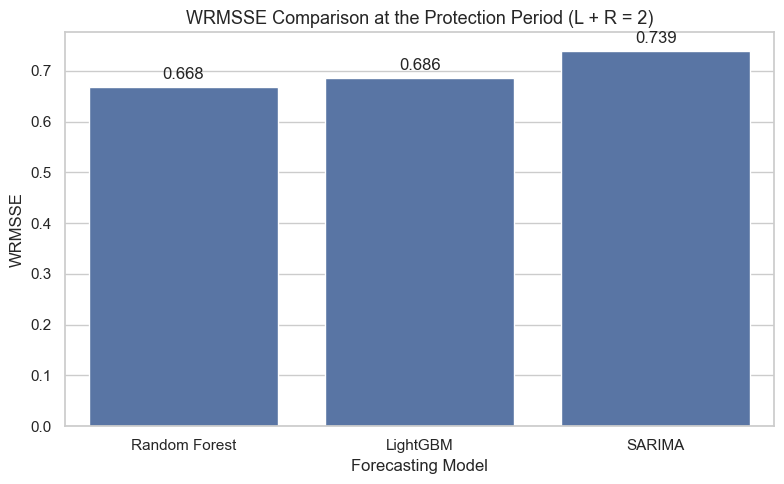

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Verify forecasting block has been run
try:
    plot_df = pd.DataFrame({
        "Model": ["SARIMA", "Random Forest", "LightGBM"],
        "WRMSSE": [wrmsse_sarima, wrmsse_rf, wrmsse_lgb]
    })
except NameError:
    raise RuntimeError(
        "WRMSSE values not found. Run the forecasting block first."
    )

# Sort ascending (best first)
plot_df = plot_df.sort_values("WRMSSE").reset_index(drop=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x="Model", y="WRMSSE")

plt.title(
    "WRMSSE Comparison at the Protection Period (L + R = 2)",
    fontsize=13
)
plt.ylabel("WRMSSE")
plt.xlabel("Forecasting Model")

for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["WRMSSE"] + 0.01,
        f"{row['WRMSSE']:.3f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

STEP 1 — DATA INTEGRATION

In [25]:
def step1_data_integration():
    """
    Load forecasts from all three models and merge into a single dataframe.
    Returns df with columns: item_id, store_id, w_num, actual,
    rf_forecast, lgb_forecast, sarima_forecast.
    """
    print("--- Step 1: Load and merge forecast datasets ---")

    rf = pd.read_csv("rf_forecast.csv")
    lgb = pd.read_csv("lgb_forecast.csv")
    sarima = pd.read_csv("sarima_forecast.csv")

    def prepare(df, name):
        if "actual" not in df.columns and "num_sold" in df.columns:
            df = df.rename(columns={"num_sold": "actual"})
        df = df.rename(columns={"preds": name})
        return df[["item_id", "store_id", "w_num", "actual", name]]

    rf = prepare(rf, "rf_forecast")
    lgb = prepare(lgb, "lgb_forecast")
    sarima = prepare(sarima, "sarima_forecast")

    df = (
        rf
        .merge(
            lgb[["item_id", "store_id", "w_num", "lgb_forecast"]],
            on=["item_id", "store_id", "w_num"],
            how="inner"
        )
        .merge(
            sarima[["item_id", "store_id", "w_num", "sarima_forecast"]],
            on=["item_id", "store_id", "w_num"],
            how="inner"
        )
    )

    df = df.sort_values(["item_id", "store_id", "w_num"])

    for col in ["actual", "rf_forecast", "lgb_forecast", "sarima_forecast"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna()

    print(f"Final columns: {df.columns.tolist()}")
    print(f"Shape: {df.shape}")
    print(f"Unique series: {df.groupby(['item_id', 'store_id']).ngroups}")

    return df


def step1b_load_training_rmse():
    """
    Load training RMSE per (item, store, model) computed from in-sample
    residuals during forecasting. This is used to parameterise safety stock
    WITHOUT leaking test-window information into inventory decisions.

    Expected file format: training_rmse.csv with columns
    item_id, store_id, model, rmse
    where model in {rf_forecast, lgb_forecast, sarima_forecast}
    """
    print("--- Step 1b: Load training-period RMSE ---")

    rmse_df = pd.read_csv("training_rmse.csv")

    # Build lookup dict: (item_id, store_id, model) → rmse
    rmse_lookup = {}
    for _, row in rmse_df.iterrows():
        key = (row["item_id"], row["store_id"], row["model"])
        rmse_lookup[key] = float(row["rmse"])

    print(f"Loaded RMSE for {len(rmse_lookup)} (series, model) pairs")
    return rmse_lookup

STEP 2 — ABC CLASSIFICATION

--- Step 1: Load and merge forecast datasets ---
Final columns: ['item_id', 'store_id', 'w_num', 'actual', 'rf_forecast', 'lgb_forecast', 'sarima_forecast']
Shape: (2874, 7)
Unique series: 1437
--- Step 1b: Load training-period RMSE ---
Loaded RMSE for 4311 (series, model) pairs
--- Step 2: ABC classification ---

ABC distribution (proportion of SKUs):
abc
A    0.376
C    0.328
B    0.296
Name: proportion, dtype: float64

ABC distribution (proportion of demand):
abc
A    0.80
B    0.15
C    0.05
Name: total_demand, dtype: float64

Sanity check:
  df_step2 shape: (2874, 8)
  sku shape: (1437, 6)


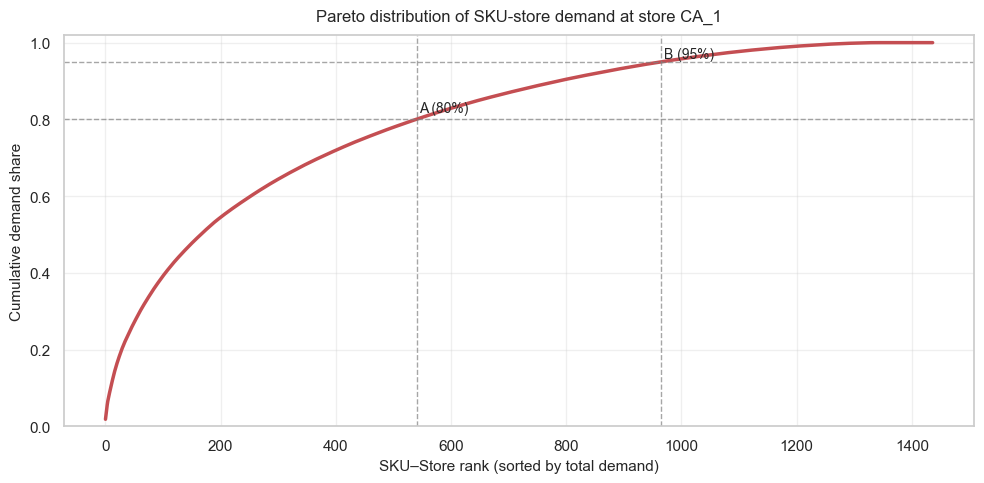

In [26]:
def step2_abc_analysis(df):
    """
    Classify SKUs into A/B/C based on cumulative demand share.
    A: top 80%, B: 80-95%, C: bottom 5%.
    """
    print("--- Step 2: ABC classification ---")

    sku = (
        df.groupby(["item_id", "store_id"])
        .agg(total_demand=("actual", "sum"))
        .reset_index()
        .sort_values("total_demand", ascending=False)
        .reset_index(drop=True)
    )

    total = sku["total_demand"].sum()
    if total == 0:
        raise ValueError("Total demand = 0 → ABC classification impossible")

    sku["share"] = sku["total_demand"] / total
    sku["cum_share"] = sku["share"].cumsum()

    sku["abc"] = np.select(
        [sku["cum_share"] <= 0.80, sku["cum_share"] <= 0.95],
        ["A", "B"],
        default="C"
    )

    df = df.merge(
        sku[["item_id", "store_id", "abc"]],
        on=["item_id", "store_id"],
        how="left"
    )

    print("\nABC distribution (proportion of SKUs):")
    print(sku["abc"].value_counts(normalize=True).round(3))

    print("\nABC distribution (proportion of demand):")
    demand_share = (
            sku.groupby("abc")["total_demand"].sum() / total
    ).round(3)
    print(demand_share)

    return df, sku


def plot_pareto_abc(sku):
    """Plot cumulative demand curve with A/B/C cutoffs."""
    sku = sku.sort_values("total_demand", ascending=False).reset_index(drop=True)
    sku["cum_share"] = sku["total_demand"].cumsum() / sku["total_demand"].sum()

    cut_A = (sku["cum_share"] >= 0.80).idxmax()
    cut_B = (sku["cum_share"] >= 0.95).idxmax()

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        sku.index,
        sku["cum_share"],
        color="#c44e52",
        linewidth=2.5
    )
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("SKU–Store rank (sorted by total demand)", fontsize=11)
    ax.set_ylabel("Cumulative demand share", fontsize=11)

    # ABC cutoff lines
    ax.axhline(0.80, linestyle="--", linewidth=1, color="grey", alpha=0.7)
    ax.axhline(0.95, linestyle="--", linewidth=1, color="grey", alpha=0.7)
    ax.axvline(cut_A, linestyle="--", linewidth=1, color="grey", alpha=0.7)
    ax.axvline(cut_B, linestyle="--", linewidth=1, color="grey", alpha=0.7)

    ax.text(cut_A + 5, 0.82, "A (80%)", fontsize=10)
    ax.text(cut_B + 5, 0.96, "B (95%)", fontsize=10)

    plt.title(
        "Pareto distribution of SKU-store demand at store CA_1",
        fontsize=12,
        pad=10
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run Steps 1, 2
df_step1 = step1_data_integration()
rmse_lookup = step1b_load_training_rmse()
df_step2, sku = step2_abc_analysis(df_step1)

print(f"\nSanity check:")
print(f"  df_step2 shape: {df_step2.shape}")
print(f"  sku shape: {sku.shape}")

plot_pareto_abc(sku)

STEP 3 — PARAMETERS

In [27]:
def step3_config():
    """Inventory parameters consistent with thesis Section 3.6.5."""
    print("--- Step 3: Inventory parameters ---")
    config = {
        "Z": 1.645,  # 95% cycle service level safety factor
        "h": 0.10,  # holding cost rate (10% of unit price per week)
        "L": 1,  # lead time (weeks)
        "R": 1,  # review period (weeks)
        "warm_up": 0,  # no warm-up (test window is short)
    }
    print(f"  Service level α = 95% → z = {config['Z']}")
    print(f"  Holding cost rate h = {config['h']}")
    print(f"  Lead time L = {config['L']} week")
    print(f"  Review period R = {config['R']} week")
    print(f"  Protection period h = R + L = {config['L'] + config['R']} weeks")
    return config


params = step3_config()

--- Step 3: Inventory parameters ---
  Service level α = 95% → z = 1.645
  Holding cost rate h = 0.1
  Lead time L = 1 week
  Review period R = 1 week
  Protection period h = R + L = 2 weeks


STEP 4 — INVENTORY SIMULATION

In [28]:
def step4_inventory_simulation(df, params, rmse_lookup, warm_up=None):
    """
    Discrete-event simulation of (R, S) policy under lost sales.

    Initial conditions (matches Section 3.7.1):
    - Inventory initialised to S_0 (full order-up-to level)
    - Pipeline initialised to empty
    """
    print("--- Step 4: Inventory simulation ---")

    if warm_up is None:
        warm_up = params.get("warm_up", 0)

    df = df.sort_values(["item_id", "store_id", "w_num"]).copy()

    models = ["rf_forecast", "lgb_forecast", "sarima_forecast"]
    horizon = int(np.ceil(params["L"] + params["R"]))
    lead_time = int(np.ceil(params["L"]))
    Z = params["Z"]
    h_cost = params["h"]

    results = []
    n_missing_rmse = 0

    for (item, store), g in df.groupby(["item_id", "store_id"]):
        g = g.reset_index(drop=True)
        actual = g["actual"].values

        for m in models:
            forecast = g[m].fillna(0).clip(lower=0).values

            # ===== SAFETY STOCK FROM TRAINING RMSE =====
            rmse_key = (item, store, m)
            if rmse_key in rmse_lookup:
                rmse = max(rmse_lookup[rmse_key], 1e-3)
            else:
                n_missing_rmse += 1
                rmse = 1e-3

            ss = Z * rmse * np.sqrt(horizon)

            # ===== INITIAL CONDITIONS =====
            # Inventory starts at S_0 = expected demand over (R+L) + Ss
            # Pipeline starts empty
            initial_forecast = forecast[:horizon]
            if len(initial_forecast) < horizon:
                initial_forecast = np.pad(
                    initial_forecast,
                    (0, horizon - len(initial_forecast)),
                    mode='edge'
                )
            initial_S = np.sum(initial_forecast) + ss

            inventory = initial_S  # ✅ FIXED: full S_0, not just ss
            pipeline = [0.0] * lead_time

            holding = 0.0
            shortage = 0.0
            actual_demand_period = 0.0

            for t in range(len(g)):
                # 1. Receive orders
                inventory += pipeline.pop(0)

                # 2. Review & order
                if t % params["R"] == 0:
                    future = forecast[t:t + horizon]
                    if len(future) < horizon:
                        future = np.pad(
                            future,
                            (0, horizon - len(future)),
                            mode='edge'
                        )
                    expected_demand = np.sum(future)
                    S = expected_demand + ss
                    inventory_position = inventory + sum(pipeline)
                    Q = max(S - inventory_position, 0.0)
                    pipeline.append(Q)
                else:
                    pipeline.append(0.0)

                # 3. Demand realisation (lost sales)
                demand = actual[t]

                if t >= warm_up:
                    actual_demand_period += demand
                    if inventory >= demand:
                        inventory -= demand
                        holding += inventory
                    else:
                        shortage += (demand - inventory)
                        inventory = 0.0
                else:
                    inventory = max(inventory - demand, 0.0)

            results.append({
                "item_id": item,
                "store_id": store,
                "model": m,
                "rmse_used": rmse,
                "safety_stock": ss,
                "initial_inventory": initial_S,
                "holding": holding,
                "shortage": shortage,
                "actual_demand_period": actual_demand_period,
                "total_cost": holding * h_cost,
            })

    if n_missing_rmse > 0:
        print(
            f"  ⚠️ {n_missing_rmse} (series, model) pairs missing RMSE"
        )

    df_results = pd.DataFrame(results)
    print(f"  Total simulations: {len(df_results)}")

    return df_results

In [29]:
def step5_abc_financial_report(df_results, df_base):
    """
    Aggregate simulation results by (ABC category, model).
    Reports: total holding cost, fill rate, average cost per SKU.

    Fill rate uses actual_demand_period from Step 4 (respects warm-up).
    """
    print("--- Step 5: ABC financial report ---")

    # Attach ABC category to results
    df_results = df_results.merge(
        df_base[["item_id", "store_id", "abc"]].drop_duplicates(),
        on=["item_id", "store_id"],
        how="left"
    )

    rows = []

    for (cat, model), g in df_results.groupby(["abc", "model"]):
        total_cost = g["total_cost"].sum()
        total_holding = g["holding"].sum()
        total_shortage = g["shortage"].sum()
        total_demand = g["actual_demand_period"].sum()
        n_skus = g[["item_id", "store_id"]].drop_duplicates().shape[0]

        # Demand-weighted fill rate
        fill_rate = (
            1.0 - total_shortage / (total_demand + 1e-9)
            if total_demand > 0 else np.nan
        )

        rows.append({
            "Category": cat,
            "Model": model.replace("_forecast", "").upper(),
            "N_SKUs": n_skus,
            "Total_Holding_Cost": round(total_cost, 2),
            "Total_Shortage_Units": round(total_shortage, 2),
            "Total_Demand": round(total_demand, 2),
            "Fill_Rate_%": round(fill_rate * 100, 2),
            "Avg_Cost_per_SKU": round(total_cost / max(n_skus, 1), 4),
        })

    return pd.DataFrame(rows)


# Run Steps 4, 5
df_results = step4_inventory_simulation(df_step2, params, rmse_lookup)
kpi_report = step5_abc_financial_report(df_results, df_step2)

print("\n=== KPI Report ===")
display(
    kpi_report.sort_values(["Category", "Total_Holding_Cost"])
    .reset_index(drop=True)
)

--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---

=== KPI Report ===


,Category,Model,N_SKUs,Total_Holding_Cost,Total_Shortage_Units,Total_Demand,Fill_Rate_%,Avg_Cost_per_SKU
0,A,RF,540,3700.13,1008.02,33008.0,96.95,6.8521
1,A,LGB,540,4087.68,801.22,33008.0,97.57,7.5698
2,A,SARIMA,540,4982.58,624.33,33008.0,98.11,9.2270
3,B,RF,425,1118.92,78.92,6189.0,98.72,2.6327
4,B,LGB,425,1186.54,63.70,6189.0,98.97,2.7919
5,B,SARIMA,425,1283.35,99.30,6189.0,98.40,3.0196
6,C,RF,472,1111.77,4.68,2069.0,99.77,2.3554
7,C,LGB,472,1189.23,2.95,2069.0,99.86,2.5196
8,C,SARIMA,472,1303.64,7.11,2069.0,99.66,2.7619


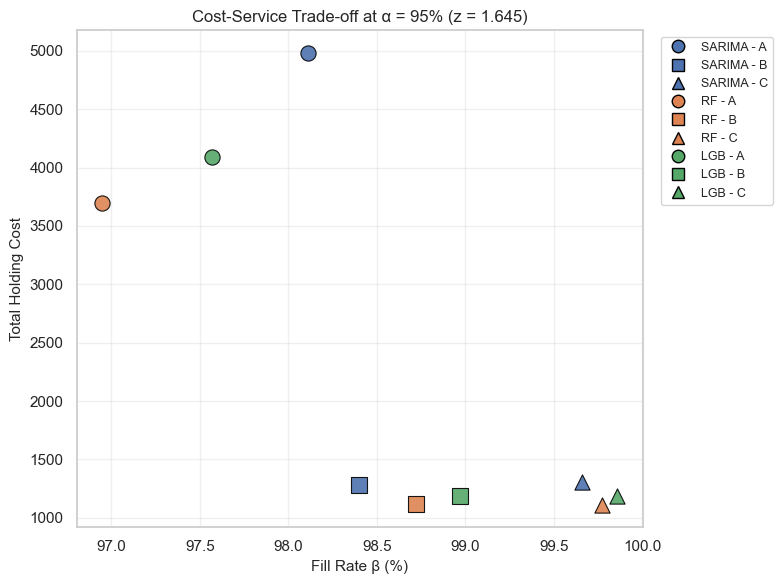

In [30]:
def plot_cost_service_scatter(kpi_report):
    """Scatter plot of (fill rate, holding cost) at default z = 1.645."""
    plt.figure(figsize=(8, 6))

    colors = {
        "SARIMA": "#4c72b0",
        "RF": "#dd8452",
        "LGB": "#55a868",
    }
    markers = {
        "A": "o",
        "B": "s",
        "C": "^",
    }

    for model in ["SARIMA", "RF", "LGB"]:
        for cat in ["A", "B", "C"]:
            data = kpi_report[
                (kpi_report["Model"] == model) &
                (kpi_report["Category"] == cat)
                ]
            if len(data) == 0:
                continue
            plt.scatter(
                data["Fill_Rate_%"],
                data["Total_Holding_Cost"],
                color=colors[model],
                marker=markers[cat],
                s=120,
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9,
            )

    plt.xlabel("Fill Rate β (%)", fontsize=11)
    plt.ylabel("Total Holding Cost", fontsize=11)
    plt.title(
        "Cost-Service Trade-off at α = 95% (z = 1.645)",
        fontsize=12
    )
    plt.grid(alpha=0.3)

    # Build combined legend
    handles = []
    labels = []
    for model in ["SARIMA", "RF", "LGB"]:
        for cat in ["A", "B", "C"]:
            handles.append(
                plt.Line2D(
                    [0], [0],
                    marker=markers[cat],
                    color='w',
                    markerfacecolor=colors[model],
                    markeredgecolor='black',
                    markersize=9,
                    linestyle='None',
                )
            )
            labels.append(f"{model} - {cat}")

    plt.legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


plot_cost_service_scatter(kpi_report)

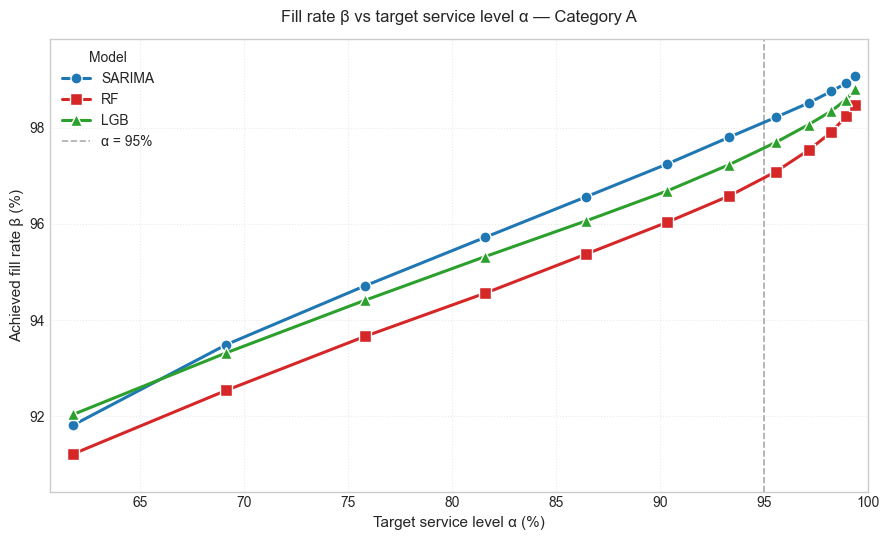

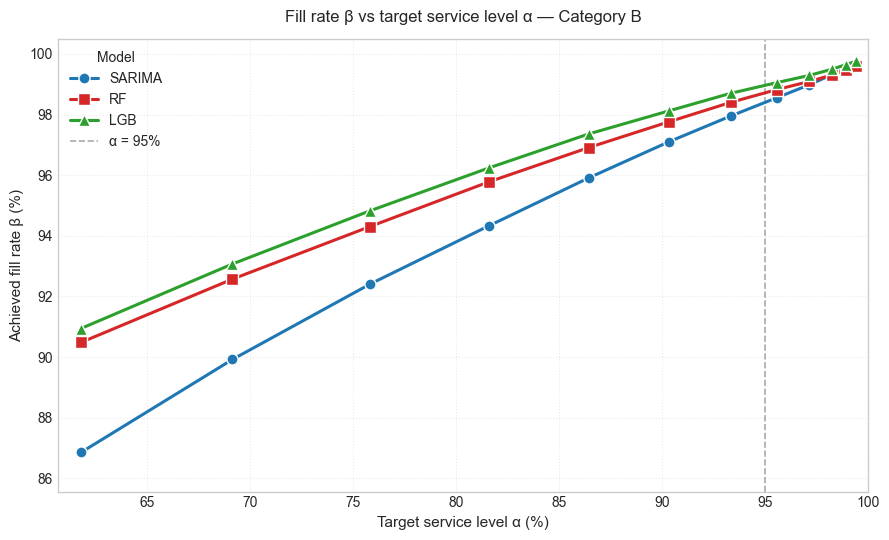

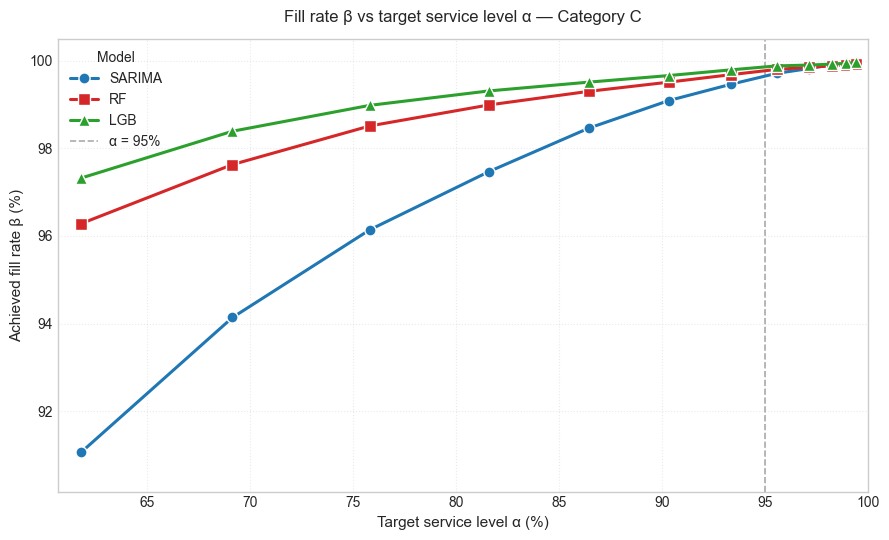

--- Step 7: Running z-sweep over 12 values ---
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [1/12] z = 0.30 → α = 61.8%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [2/12] z = 0.50 → α = 69.1%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [3/12] z = 0.70 → α = 75.8%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [4/12] z = 0.90 → α = 81.6%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [5/12] z = 1.10 → α = 86.4%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [6/12] z = 1.30 → α = 90.3%
--- Step 4: Inventory simulation ---
  Total simulations: 4311
--- Step 5: ABC financial report ---
  [7/12] z = 1.50 → α = 93.3%
--- Step 4: Inventory simulation ---
  Tota

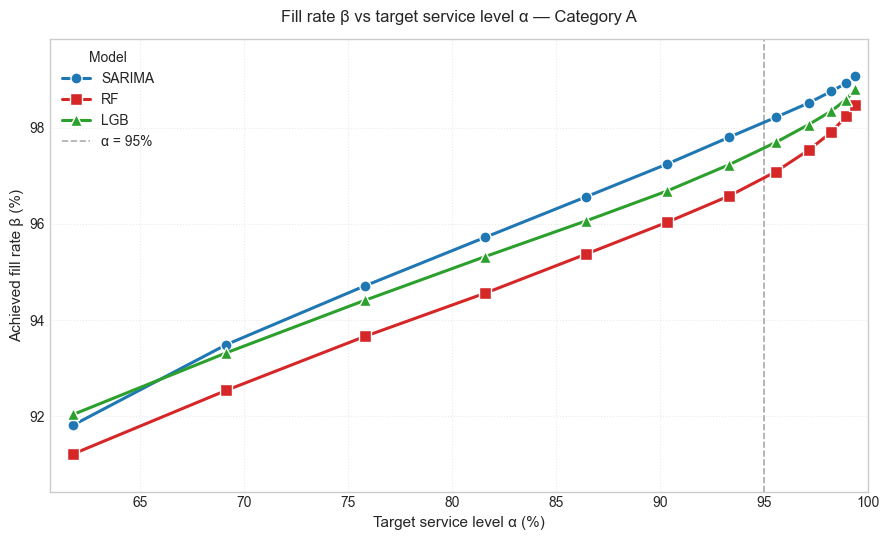

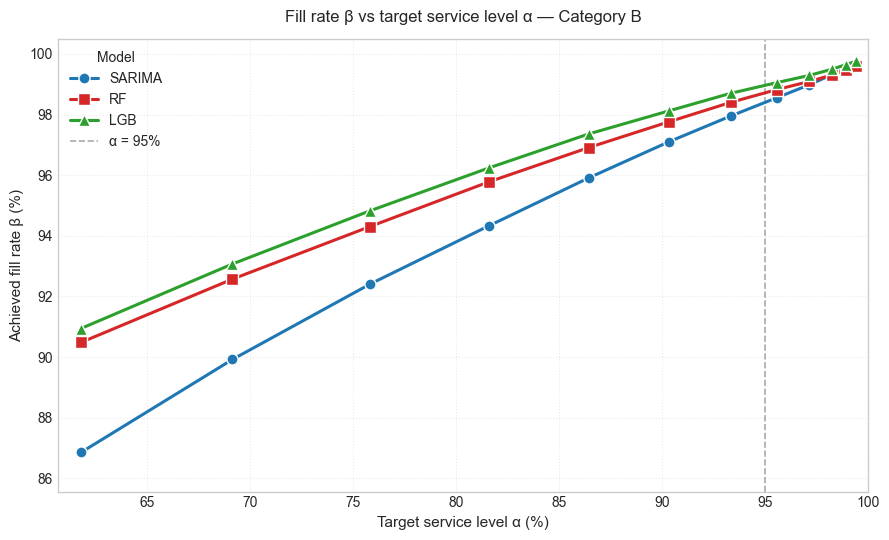

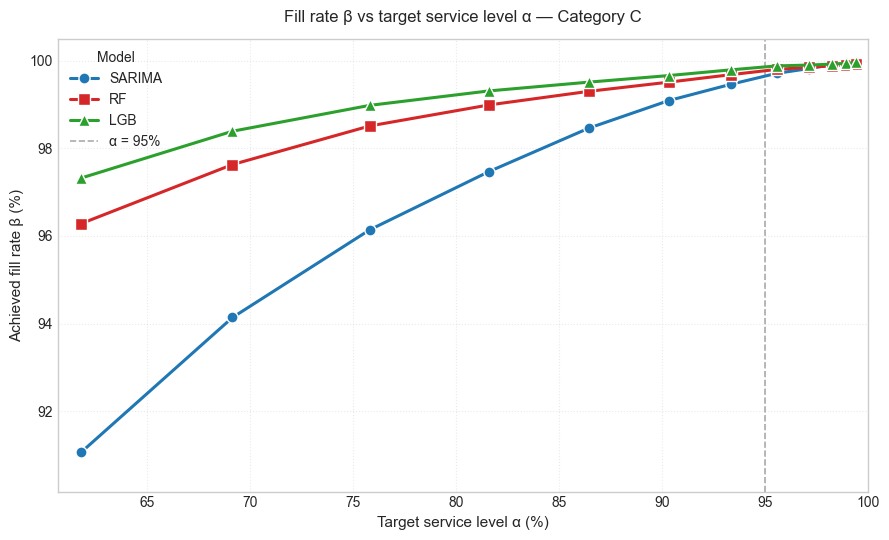

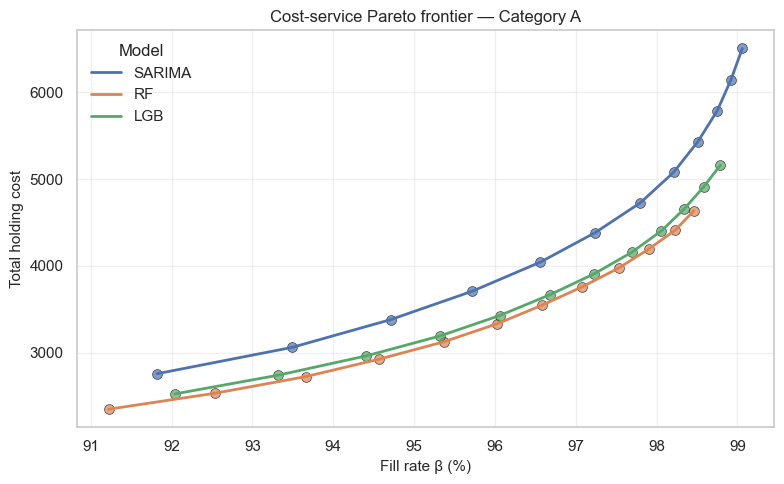

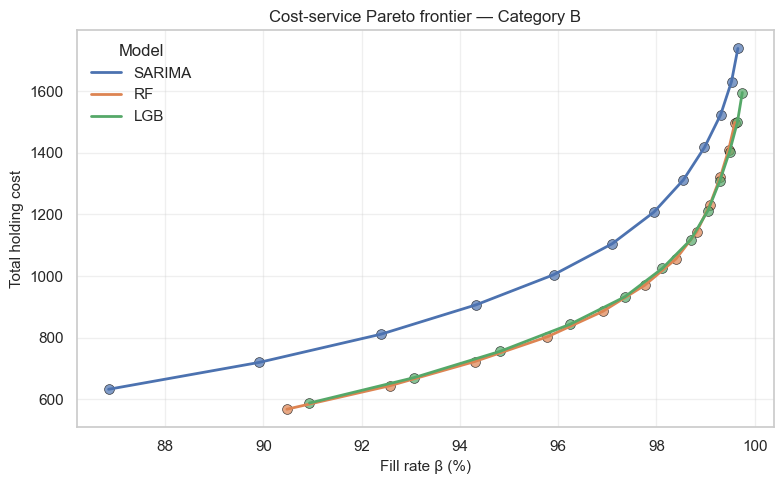

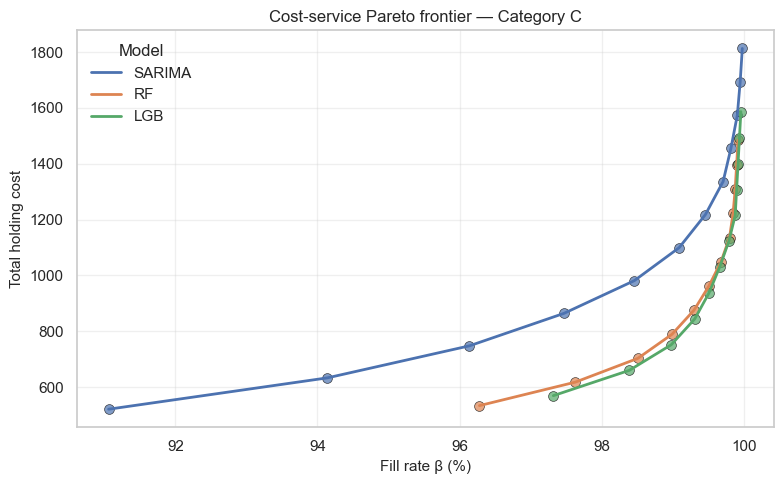

In [47]:
from scipy.stats import norm


def run_z_sweep(df_base, base_params, rmse_lookup, z_values):
    """
    Re-run inventory simulation across a range of safety factors z.
    Used for Pareto frontier and α-vs-β sensitivity analysis.
    """
    print(f"--- Step 7: Running z-sweep over {len(z_values)} values ---")

    all_results = []
    for i, Z in enumerate(z_values):
        params_temp = base_params.copy()
        params_temp["Z"] = Z

        df_res = step4_inventory_simulation(
            df_base, params_temp, rmse_lookup
        )
        df_kpi = step5_abc_financial_report(df_res, df_base)

        df_kpi["Z"] = Z
        df_kpi["Alpha"] = norm.cdf(Z) * 100
        all_results.append(df_kpi)

        print(f"  [{i + 1}/{len(z_values)}] z = {Z:.2f} → α = {norm.cdf(Z) * 100:.1f}%")

    df_curve = pd.concat(all_results, ignore_index=True)
    print(f"\nTotal points generated: {len(df_curve)}")
    return df_curve


def plot_alpha_beta_by_category(df_curve):
    """
    Plot achieved fill rate β vs target service level α per ABC category.
    Clean, high-contrast version with auto-zoom on data range.
    """
    import matplotlib.pyplot as plt

    # CRITICAL: reset to default light theme (override any dark_background)
    plt.rcdefaults()
    plt.style.use("seaborn-v0_8-whitegrid")

    colors = {
        "SARIMA": "#1f77b4",   # blue
        "RF":     "#d62728",   # red
        "LGB":    "#2ca02c",   # green
    }
    markers = {
        "SARIMA": "o",
        "RF":     "s",
        "LGB":    "^",
    }

    for cat in ["A", "B", "C"]:
        fig, ax = plt.subplots(figsize=(9, 5.5))

        cat_data = df_curve[df_curve["Category"] == cat]

        # Auto-zoom: focus on actual data range with padding
        alpha_min = cat_data["Alpha"].min()
        alpha_max = cat_data["Alpha"].max()
        beta_min = cat_data["Fill_Rate_%"].min()
        beta_max = cat_data["Fill_Rate_%"].max()

        x_pad = max((alpha_max - alpha_min) * 0.03, 1)
        y_pad = max((beta_max - beta_min) * 0.10, 0.5)

        x_lo = max(alpha_min - x_pad, 0)
        x_hi = min(alpha_max + x_pad, 100)
        y_lo = max(beta_min - y_pad, 0)
        y_hi = min(beta_max + y_pad, 100.5)

        # Plot model curves — thicker lines, distinct markers
        for model in ["SARIMA", "RF", "LGB"]:
            data = cat_data[cat_data["Model"] == model].sort_values("Alpha")

            if len(data) == 0:
                continue

            ax.plot(
                data["Alpha"],
                data["Fill_Rate_%"],
                marker=markers[model],
                color=colors[model],
                linewidth=2.2,
                markersize=8,
                markeredgecolor="white",
                markeredgewidth=1.0,
                label=model,
                zorder=3,
            )

        # Vertical reference at α = 95%
        if x_lo <= 95 <= x_hi:
            ax.axvline(
                95,
                linestyle="--",
                color="#888888",
                alpha=0.7,
                linewidth=1.2,
                zorder=2,
                label="α = 95%",
            )

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_lo, y_hi)

        ax.set_xlabel("Target service level α (%)", fontsize=11)
        ax.set_ylabel("Achieved fill rate β (%)", fontsize=11)
        ax.set_title(
            f"Fill rate β vs target service level α — Category {cat}",
            fontsize=12,
            pad=12,
        )

        ax.grid(alpha=0.4, linestyle=":")
        ax.set_facecolor("white")

        # Legend at upper-left for clarity (data trends bottom-left to top-right)
        ax.legend(
            title="Model",
            loc="upper left",
            framealpha=0.95,
            fontsize=10,
            title_fontsize=10,
            edgecolor="grey",
        )

        plt.tight_layout()
        plt.show()





def plot_efficient_frontier_by_category(df_curve):
    """
    Plot cost-service Pareto frontier per ABC category.
    For each model, the frontier is constructed by retaining only the
    cost-minimal point at each fill rate value.
    """
    sns.set_theme(style="whitegrid")
    colors = {
        "SARIMA": "#4c72b0",
        "RF": "#dd8452",
        "LGB": "#55a868",
    }

    for cat in ["A", "B", "C"]:
        plt.figure(figsize=(8, 5))
        subset = df_curve[df_curve["Category"] == cat]

        for model in ["SARIMA", "RF", "LGB"]:
            data = subset[subset["Model"] == model].copy()

            # Build efficient frontier:
            # 1. Sort by holding cost ascending
            # 2. For each fill rate level, keep the lowest cost
            data = data.sort_values("Total_Holding_Cost")
            data = data.drop_duplicates(subset=["Fill_Rate_%"], keep="first")
            data = data.sort_values("Fill_Rate_%")

            if len(data) == 0:
                continue

            plt.plot(
                data["Fill_Rate_%"],
                data["Total_Holding_Cost"],
                color=colors[model],
                linewidth=2,
                label=model,
            )
            plt.scatter(
                data["Fill_Rate_%"],
                data["Total_Holding_Cost"],
                color=colors[model],
                s=50,
                alpha=0.7,
                edgecolor="black",
                linewidth=0.5,
            )

        plt.xlabel("Fill rate β (%)", fontsize=11)
        plt.ylabel("Total holding cost", fontsize=11)
        plt.title(
            f"Cost-service Pareto frontier — Category {cat}",
            fontsize=12,
        )
        plt.grid(alpha=0.3)
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()


# Run z-sweep
z_values = np.linspace(0.3, 2.5, 12)
df_curve = run_z_sweep(df_step2, params, rmse_lookup, z_values)

# Save curve data for thesis
df_curve.to_csv("z_sweep_results.csv", index=False)

# Plots
plot_alpha_beta_by_category(df_curve)
plot_efficient_frontier_by_category(df_curve)